# Diamond Creek ETF Arbitrage — Backtest v9


**v8:** Keeps the same v7 engine/data/costs, and adds a new weighting method that combines **backtest PnL/Gross** with **screener net decay signal** (`data/etf_screened_today.csv`), then applies a **shares-available capacity cap** so short ETF targets do not exceed a configurable fraction of available lendable shares.

**Dynamic target gross multiple:** **`V7_TARGET_LEV_START` → `V7_TARGET_LEV_END`** (default **4.5× → 5.0×** NAV) as a function of how many **post-start** candidate pairs have **non-trivial gross** on the book.

**Later cells:** After the equal-weight run, save NAVs + build **v8 combined weights**, then re-backtest with **`v8_pnl_decay_shares_weights.csv`**. Final section adds a historical **shares-available** analysis from `data/runs/*/etf_screened_today.csv`.


## Setup


In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, requests, time, ftplib, io, os
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

TRADING_DAYS = 252
norm_sym = lambda x: str(x).strip().upper().replace(".", "-")
print("Imports OK")


Imports OK


## Configuration


In [2]:
CFG = {
    "capital_usd":          10_000_000,
    "start_date":           "2024-12-14",
    "slippage_bps":         5,
    "ibkr_comm_per_share":  0.005,
    "ibkr_comm_min":        1.00,
    "ibkr_comm_max_pct":    0.005,
    "fallback_borrow_rate": 0.02,
    "margin_debit_spreads": [
        (100_000,      0.015),
        (1_000_000,    0.010),
        (50_000_000,   0.0075),
        (float("inf"), 0.005),
    ],
    "credit_threshold":     10_000,
    "credit_spread":        -0.005,
    "skip_ftp":             False,
    "dead_band_pct":        0.02,
    "gross_dead_band_pct":  0.05,       # full position resize if portfolio gross drifts > 5% from target
    "weight_power":         2,          # exponent applied to PnL/Gross ratios before normalising weights
    "mix_decay_weight":     0.45,       # blend: 0=PnL/Gross only, 1=decay-score only
    "decay_weight_power":   1.25,       # exponent on positive decay signal
    "position_concentration_power": 1.35, # >1 tilts more weight to biggest names
    "short_avail_use_pct":  0.25,       # softer cap: can target up to 25% of reported shares_available
    "max_pair_weight_cap":  0.20,       # hard max portfolio weight per pair after capacity logic
    "missing_shares_cap":   0.03,       # softer fallback cap when shares_available is missing
    "cap_ramp_rebals":      3,          # raise cap-constrained names over next 3 rebalances
}

LEVERAGE_RUNS = [4.5]

V7_TARGET_LEV_START = 4.5   # incumbent day-0 sizing; floor for target multiple
V7_TARGET_LEV_END = 5.0     # target multiple once all post-start pairs are on book

print(f"Capital: ${CFG['capital_usd']:,}  |  Start: {CFG['start_date']}")
print(f"Leverage: {LEVERAGE_RUNS}  |  v8 target gross multiple: {V7_TARGET_LEV_START}x → {V7_TARGET_LEV_END}x")
print("Weekly dead-band hedge  |  0% beta target  |  v8 combined weights (PnL/Gross + decay + shares cap)")


Capital: $10,000,000  |  Start: 2024-12-14
Leverage: [4.5]  |  v8 target gross multiple: 4.5x → 5.0x
Weekly dead-band hedge  |  0% beta target  |  v8 combined weights (PnL/Gross + decay + shares cap)


## PM margin — Diamond Creek sample book

Long/short equity book (~70 US names, mainly large caps and ETFs). **Source:** `data/backtest/PM Report Diamond Creek 20260326 CV.xlsx` → *Top Level Summary*.

PM notes (narrative): regulatory-style requirement lands near **$6.5MM**; **discretionary** add-on tied to crypto proxies (BITU, BITX, ETHA, ETHT, ETHU, IBIT, SOEZ); **concentration** add-on on largest names (e.g. NVDA, TSLA); small **liquidity** add-on (SOEZ). **PM/GMV** in the file is *Effective margin requirement ÷ GMV* (~17%).

The next cell loads the spreadsheet and estimates **margin excess** if gross exposure were raised to **4.5× equity** (same equity, higher GMV), by applying the file’s **MR/GMV** ratio to the new gross (equivalent to scaling today’s effective margin **linearly with GMV** when the report is internally consistent).


In [3]:
PM_XLSX = Path("data/backtest/PM Report Diamond Creek 20260326 CV.xlsx")
TARGET_GROSS_LEV = 4.5  # gross market value / equity


def _pm_top_level_snapshot(path: Path) -> dict[str, float]:
    """Parse key fields from 'Top Level Summary' (label in col 0, current in col 1)."""
    tl = pd.read_excel(path, sheet_name="Top Level Summary", header=None)
    labels = tl[0].astype(str).str.strip()

    def row_val(label: str) -> float:
        m = labels == label
        if not m.any():
            raise KeyError(f"missing row {label!r} in Top Level Summary")
        v = tl.loc[m.idxmax(), 1]
        return float(v)

    equity = row_val("Equity")
    eff_mr = row_val("Effective Margin Requirement")
    margin_xs = row_val("Margin Excess/Deficit")
    lmv = row_val("Long Market Value")
    smv = row_val("Short Market Value")
    gmv = row_val("Gross Market Value")
    try:
        pm_over_gmv = row_val("Effective Requirement / GMV")
    except KeyError:
        pm_over_gmv = eff_mr / gmv if gmv else float("nan")

    gross_lev = gmv / equity if equity else float("nan")
    return {
        "equity": equity,
        "effective_margin_req": eff_mr,
        "margin_excess": margin_xs,
        "lmv": lmv,
        "smv": smv,
        "gmv": gmv,
        "pm_over_gmv": pm_over_gmv,
        "gross_leverage_x": gross_lev,
    }


sn = _pm_top_level_snapshot(PM_XLSX)
eq = sn["equity"]
gmv0 = sn["gmv"]
mr0 = sn["effective_margin_req"]
r = sn["pm_over_gmv"]

gmv_tgt = TARGET_GROSS_LEV * eq
# Constant MR/GMV ratio (same mix in % of gross). Equivalent to scaling today's $ requirement
# linearly with GMV when Effective MR = (MR/GMV) × GMV in the report.
mr_stressed = r * gmv_tgt
xs_stressed = eq - mr_stressed
mr_linear_check = mr0 * (gmv_tgt / gmv0) if gmv0 else float("nan")

print("--- Diamond Creek PM snapshot (from xlsx) ---")
print(f"Equity:                 ${eq:>17,.0f}")
print(f"LMV / SMV:              ${sn['lmv']:>17,.0f}  /  ${sn['smv']:>17,.0f}")
print(f"GMV:                    ${gmv0:>17,.0f}  |  implied gross lev: {sn['gross_leverage_x']:.2f}x")
print(f"Effective margin req:   ${mr0:>17,.0f}  |  MR/GMV: {r * 100:.2f}%")
print(f"Margin excess (report): ${sn['margin_excess']:>17,.0f}")
print()
print(f"--- Stress: {TARGET_GROSS_LEV:.1f}x gross on same equity ---")
print(f"Target GMV ({TARGET_GROSS_LEV:.1f} × equity): ${gmv_tgt:>17,.0f}")
print()
print("Implied requirement (constant MR/GMV × target GMV):")
print(f"  Margin need:            ${mr_stressed:>17,.0f}")
print(f"  Margin excess:          ${xs_stressed:>17,.0f}  ({100 * xs_stressed / eq:.2f}% of equity)")
print(f"  vs reported excess:     ${sn['margin_excess']:>17,.0f}  → buffer vs today ${sn['margin_excess'] - xs_stressed:,.0f}")
if gmv0 and abs(mr_linear_check - mr_stressed) < 1.0:
    print()
    print("(Linear GMV scaling from today's $ margin matches this when MR/GMV is consistent with the file.)")


--- Diamond Creek PM snapshot (from xlsx) ---
Equity:                 $       10,000,000
LMV / SMV:              $       25,760,703  /  $      -12,736,857
GMV:                    $       38,497,560  |  implied gross lev: 3.85x
Effective margin req:   $        6,512,593  |  MR/GMV: 16.92%
Margin excess (report): $        3,487,407

--- Stress: 4.5x gross on same equity ---
Target GMV (4.5 × equity): $       45,000,000

Implied requirement (constant MR/GMV × target GMV):
  Margin need:            $        7,612,604
  Margin excess:          $        2,387,396  (23.87% of equity)
  vs reported excess:     $        3,487,407  → buffer vs today $1,100,011

(Linear GMV scaling from today's $ margin matches this when MR/GMV is consistent with the file.)


## Universe — v7 (same hardcoded list as v6 from `DC_Universe_Map_Filtered.xlsx`)



In [4]:
# Hardcoded from DC_Universe_Map_Filtered.xlsx (sheet "Universe Map") — all ETF slots, |β| rounded to 3dp.
CANDIDATES = [
    ("SMU", "SMR", 1.986),   ("SMUP", "SMR", 2.058),  ("QBTX", "QBTS", 1.993),
    ("BMNU", "BMNR", 1.944), ("BMNG", "BMNR", 1.993), ("ASTX", "ASTS", 1.990),
    ("CRWG", "CRWV", 1.997), ("CWVX", "CRWV", 1.990), ("WULX", "WULF", 1.997),
    ("NEBX", "NBIS", 1.999), ("NBIL", "NBIS", 1.998), ("NBIG", "NBIS", 2.009),
    ("SMCL", "SMCI", 1.990), ("CRCA", "CRCL", 1.978), ("CRCG", "CRCL", 1.990),
    ("LABX", "ALAB", 1.994), ("BEX", "BE", 1.977),    ("CLSX", "CLSK", 1.999),
    ("GLXU", "GLXY", 2.012), ("XXRP", "XRPZ", 2.020), ("XRPT", "XRPZ", 2.018),
    ("ETHU", "ETHA", 2.001), ("ETHT", "ETHA", 1.991), ("ETU", "ETHA", 1.990),
    ("CRDU", "CRDO", 1.988), ("FIGG", "FIG", 1.996),  ("SOLT", "SOEZ", 2.014),
    ("CONL", "COIN", 1.987), ("APPX", "APP", 1.984),  ("UUUG", "UUUU", 1.995),
    ("SOXL", "SOXX", 2.960), ("ROBN", "HOOD", 2.012), ("HOOG", "HOOD", 2.007),
    ("LITX", "LITE", 1.980), ("INTW", "INTC", 1.988), ("UPSX", "UPST", 1.989),
    ("CSEX", "CLS", 1.998),  ("MUU", "MU", 1.994),    ("MULL", "MU", 1.997),
    ("ARCX", "ACHR", 1.989), ("SATG", "SATS", 2.010), ("VRTL", "VRT", 1.982),
    ("GDXU", "GDX", 3.043),  ("NUGT", "GDX", 1.981),  ("TEMT", "TEM", 1.985),
    ("RDTL", "RDDT", 1.982), ("RBLU", "RBLX", 2.019), ("AMDL", "AMD", 1.997),
    ("AMUU", "AMD", 2.008),  ("AMDG", "AMD", 2.003),  ("TSLL", "TSLA", 1.993),
    ("TSLT", "TSLA", 1.993), ("TSLR", "TSLA", 1.999), ("TSLG", "TSLA", 1.991),
    ("BITX", "IBIT", 2.005), ("BITU", "IBIT", 1.992), ("BTCL", "IBIT", 2.007),
    ("YINN", "FXI", 2.974),  ("MVLL", "MRVL", 1.992), ("URAA", "URA", 1.933),
    ("SNOU", "SNOW", 2.024), ("BULG", "BULL", 1.985), ("PLTU", "PLTR", 1.992),
    ("PTIR", "PLTR", 1.997), ("PLTG", "PLTR", 1.996), ("BABX", "BABA", 2.006),
    ("NVDL", "NVDA", 1.988), ("NVDU", "NVDA", 1.986), ("NVDX", "NVDA", 1.997),
    ("NVDG", "NVDA", 1.969), ("LRCU", "LRCX", 2.045), ("ARMG", "ARM", 1.997),
    ("TSMU", "TSM", 1.990),  ("TSMG", "TSM", 1.979),  ("GEVX", "GEV", 1.993),
    ("KTUP", "KTOS", 2.026), ("AVL", "AVGO", 1.987),  ("AVGG", "AVGO", 1.999),
    ("AVGU", "AVGO", 1.992), ("UBRL", "UBER", 1.995), ("CRMG", "CRM", 1.984),
    ("UNHG", "UNH", 1.996),  ("MEXX", "EWW", 2.958),  ("JNUG", "GDXJ", 1.974),
    ("NFLU", "NFLX", 1.990), ("CWEB", "KWEB", 1.987), ("CEGX", "CEG", 1.979),
    ("GGLL", "GOOGL", 1.992),("GOOX", "GOOGL", 1.984),("KORU", "EWY", 2.931),
    ("TERG", "TER", 1.996),  ("DLLL", "DELL", 1.986), ("METU", "META", 1.999),
    ("FBL", "META", 1.997),  ("AMZU", "AMZN", 1.987), ("AMZZ", "AMZN", 1.992),
    ("PALU", "PANW", 2.006), ("ASMG", "ASML", 1.984), ("WDCX", "WDC", 2.055),
    ("CRWL", "CRWD", 1.997), ("ELIL", "LLY", 1.991),  ("PYPG", "PYPL", 1.995),
    ("BOEU", "BA", 1.987),   ("MSFU", "MSFT", 1.991), ("MSFL", "MSFT", 1.992),
    ("MSFX", "MSFT", 2.007), ("CHAU", "ASHR", 1.967), ("NOWL", "NOW", 1.996),
    ("ERX", "XLE", 1.988),   ("GUSH", "XOP", 2.011),  ("SHPU", "SHOP", 2.012),
    ("XOMX", "XOM", 1.969),  ("ORCU", "ORCL", 2.006), ("ADBG", "ADBE", 1.992),
    ("AAPU", "AAPL", 1.984), ("AAPB", "AAPL", 1.991), ("AAPX", "AAPL", 1.995),
    ("TARK", "ARKK", 1.978), ("LABU", "XBI", 2.988),  ("CSCL", "CSCO", 2.027),
    ("LMTL", "LMT", 1.984),  ("COTG", "COST", 1.987),
]

BASE_CANDIDATE_KEYS = {(e, u) for e, u, _ in CANDIDATES}

# Add all remaining screened pairs not already in the base map.
screen_paths = [Path("../data/etf_screened_today.csv"), Path("data/etf_screened_today.csv")]
_screen_path = next((p for p in screen_paths if p.exists()), None)
_added = 0
if _screen_path is not None:
    _sc = pd.read_csv(_screen_path)
    _sc.columns = [str(c).strip() for c in _sc.columns]
    req = {"ETF", "Underlying", "Beta"}
    if req.issubset(_sc.columns):
        _sc["ETF"] = _sc["ETF"].astype(str).str.upper().str.strip()
        _sc["Underlying"] = _sc["Underlying"].astype(str).str.upper().str.strip()
        _sc["Beta"] = pd.to_numeric(_sc["Beta"], errors="coerce")

        for r in _sc.itertuples(index=False):
            e = r.ETF
            u = r.Underlying
            b = float(r.Beta) if pd.notna(r.Beta) else np.nan
            if not e or not u or not np.isfinite(b):
                continue
            key = (e, u)
            if key in BASE_CANDIDATE_KEYS:
                continue
            CANDIDATES.append((e, u, round(abs(b), 3)))
            BASE_CANDIDATE_KEYS.add(key)
            _added += 1

EXTRA_ETFS = {e for e, u, _ in CANDIDATES if (e, u) not in {(x, y) for x, y, _ in [
    ("SMU", "SMR", 1),   ("SMUP", "SMR", 1),  ("QBTX", "QBTS", 1),
    ("BMNU", "BMNR", 1), ("BMNG", "BMNR", 1), ("ASTX", "ASTS", 1),
    ("CRWG", "CRWV", 1), ("CWVX", "CRWV", 1), ("WULX", "WULF", 1),
    ("NEBX", "NBIS", 1), ("NBIL", "NBIS", 1), ("NBIG", "NBIS", 1),
    ("SMCL", "SMCI", 1), ("CRCA", "CRCL", 1), ("CRCG", "CRCL", 1),
    ("LABX", "ALAB", 1), ("BEX", "BE", 1),    ("CLSX", "CLSK", 1),
    ("GLXU", "GLXY", 1), ("XXRP", "XRPZ", 1), ("XRPT", "XRPZ", 1),
    ("ETHU", "ETHA", 1), ("ETHT", "ETHA", 1), ("ETU", "ETHA", 1),
    ("CRDU", "CRDO", 1), ("FIGG", "FIG", 1),  ("SOLT", "SOEZ", 1),
    ("CONL", "COIN", 1), ("APPX", "APP", 1),  ("UUUG", "UUUU", 1),
    ("SOXL", "SOXX", 1), ("ROBN", "HOOD", 1), ("HOOG", "HOOD", 1),
    ("LITX", "LITE", 1), ("INTW", "INTC", 1), ("UPSX", "UPST", 1),
    ("CSEX", "CLS", 1),  ("MUU", "MU", 1),    ("MULL", "MU", 1),
    ("ARCX", "ACHR", 1), ("SATG", "SATS", 1), ("VRTL", "VRT", 1),
    ("GDXU", "GDX", 1),  ("NUGT", "GDX", 1),  ("TEMT", "TEM", 1),
    ("RDTL", "RDDT", 1), ("RBLU", "RBLX", 1), ("AMDL", "AMD", 1),
    ("AMUU", "AMD", 1),  ("AMDG", "AMD", 1),  ("TSLL", "TSLA", 1),
    ("TSLT", "TSLA", 1), ("TSLR", "TSLA", 1), ("TSLG", "TSLA", 1),
    ("BITX", "IBIT", 1), ("BITU", "IBIT", 1), ("BTCL", "IBIT", 1),
    ("YINN", "FXI", 1),  ("MVLL", "MRVL", 1), ("URAA", "URA", 1),
    ("SNOU", "SNOW", 1), ("BULG", "BULL", 1), ("PLTU", "PLTR", 1),
    ("PTIR", "PLTR", 1), ("PLTG", "PLTR", 1), ("BABX", "BABA", 1),
    ("NVDL", "NVDA", 1), ("NVDU", "NVDA", 1), ("NVDX", "NVDA", 1),
    ("NVDG", "NVDA", 1), ("LRCU", "LRCX", 1), ("ARMG", "ARM", 1),
    ("TSMU", "TSM", 1),  ("TSMG", "TSM", 1),  ("GEVX", "GEV", 1),
    ("KTUP", "KTOS", 1), ("AVL", "AVGO", 1),  ("AVGG", "AVGO", 1),
    ("AVGU", "AVGO", 1), ("UBRL", "UBER", 1), ("CRMG", "CRM", 1),
    ("UNHG", "UNH", 1),  ("MEXX", "EWW", 1),  ("JNUG", "GDXJ", 1),
    ("NFLU", "NFLX", 1), ("CWEB", "KWEB", 1), ("CEGX", "CEG", 1),
    ("GGLL", "GOOGL", 1),("GOOX", "GOOGL", 1),("KORU", "EWY", 1),
    ("TERG", "TER", 1),  ("DLLL", "DELL", 1), ("METU", "META", 1),
    ("FBL", "META", 1),  ("AMZU", "AMZN", 1), ("AMZZ", "AMZN", 1),
    ("PALU", "PANW", 1), ("ASMG", "ASML", 1), ("WDCX", "WDC", 1),
    ("CRWL", "CRWD", 1), ("ELIL", "LLY", 1),  ("PYPG", "PYPL", 1),
    ("BOEU", "BA", 1),   ("MSFU", "MSFT", 1), ("MSFL", "MSFT", 1),
    ("MSFX", "MSFT", 1), ("CHAU", "ASHR", 1), ("NOWL", "NOW", 1),
    ("ERX", "XLE", 1),   ("GUSH", "XOP", 1),  ("SHPU", "SHOP", 1),
    ("XOMX", "XOM", 1),  ("ORCU", "ORCL", 1), ("ADBG", "ADBE", 1),
    ("AAPU", "AAPL", 1), ("AAPB", "AAPL", 1), ("AAPX", "AAPL", 1),
    ("TARK", "ARKK", 1), ("LABU", "XBI", 1),  ("CSCL", "CSCO", 1),
    ("LMTL", "LMT", 1),  ("COTG", "COST", 1),
]}}

# Rebuild additions with explicit Beta filter: include only screened ETFs with Beta > 1.5.
_base_keys = {(e, u) for e, u, _ in CANDIDATES if e not in EXTRA_ETFS}
base_candidates = [t for t in CANDIDATES if (t[0], t[1]) in _base_keys]

extra_candidates = []
EXTRA_ETFS = set()
if _screen_path is not None and req.issubset(_sc.columns):
    for r in _sc.itertuples(index=False):
        e = str(r.ETF).upper().strip()
        u = str(r.Underlying).upper().strip()
        b = float(r.Beta) if pd.notna(r.Beta) else np.nan
        if not e or not u or not np.isfinite(b):
            continue
        if b <= 1.5:
            continue
        key = (e, u)
        if key in _base_keys:
            continue
        extra_candidates.append((e, u, round(b, 3)))
        EXTRA_ETFS.add(e)

# Deduplicate while preserving order.
_seen = set()
CANDIDATES = []
for e, u, b in base_candidates + extra_candidates:
    k = (e, u)
    if k in _seen:
        continue
    _seen.add(k)
    CANDIDATES.append((e, u, b))

# Global beta filter for the entire v9 backtest universe.
MIN_BETA_ABS = 1.5
pair_beta_from_screen = {}
etf_beta_from_screen = {}
if _screen_path is not None and req.issubset(_sc.columns):
    for r in _sc.itertuples(index=False):
        e = str(r.ETF).upper().strip()
        u = str(r.Underlying).upper().strip()
        b = float(r.Beta) if pd.notna(r.Beta) else np.nan
        if not e or not u or not np.isfinite(b):
            continue
        pair_beta_from_screen[(e, u)] = abs(b)
        etf_beta_from_screen[e] = abs(b)

_before = len(CANDIDATES)
_filtered = []
for e, u, b in CANDIDATES:
    b_abs = pair_beta_from_screen.get((e, u), etf_beta_from_screen.get(e, abs(float(b))))
    if not np.isfinite(b_abs) or b_abs <= MIN_BETA_ABS:
        continue
    _filtered.append((e, u, round(float(b_abs), 3)))
CANDIDATES = _filtered

print(
    f"Total candidate pairs: {len(CANDIDATES)} | Added from screener (positive Beta>{MIN_BETA_ABS}): {len(extra_candidates)} "
    f"| Dropped by global beta filter: {_before - len(CANDIDATES)}"
)
print(f"Additional ETF names (capacity-sized only): {len(EXTRA_ETFS)}")


Total candidate pairs: 250 | Added from screener (positive Beta>1.5): 128 | Dropped by global beta filter: 0
Additional ETF names (capacity-sized only): 128


## Data — Borrow Rates, Prices, Pair Selection


In [5]:
# ---- Borrow rates (historical average first, FTP/cache fallback) ----
all_etf_syms = [e for e, _, _ in CANDIDATES]
BORROW_CACHE = Path("data/borrow_cache.csv")

# Resolve runs path robustly across notebook cwd variants.
runs_candidates = [
    Path("data/runs"),
    Path("../data/runs"),
    Path.cwd() / "data/runs",
    Path.cwd() / "../data/runs",
    Path.cwd().parent / "data/runs",
]
RUNS_ROOT = next((p.resolve() for p in runs_candidates if p.exists()), None)
if RUNS_ROOT is None:
    RUNS_ROOT = Path("data/runs")

# Build consolidated historical panel (borrow + shares) from run snapshots.
def _trimmed_mean_drop2(s: pd.Series) -> float:
    x = pd.to_numeric(s, errors="coerce").dropna().sort_values()
    if len(x) <= 4:
        return float(x.mean()) if len(x) else np.nan
    return float(x.iloc[2:-2].mean())


def _norm_col(c: str) -> str:
    return "".join(ch for ch in str(c).lower().strip() if ch.isalnum())


def _pick_col(cols: list[str], exact_norm: list[str], fuzzy_contains: list[str] | None = None) -> str | None:
    norm_to_orig = {_norm_col(c): c for c in cols}
    for k in exact_norm:
        if k in norm_to_orig:
            return norm_to_orig[k]
    if fuzzy_contains:
        for c in cols:
            nc = _norm_col(c)
            if all(tok in nc for tok in fuzzy_contains):
                return c
    return None


# Prefer etf_screened_today for a date, but still use proposed_trades to fill missing fields.
def _historical_snapshot_files(root: Path) -> list[tuple[pd.Timestamp, Path, int]]:
    out = []
    for d in sorted(root.glob("*")):
        if not d.is_dir():
            continue
        ds = pd.to_datetime(d.name, errors="coerce")
        if pd.isna(ds):
            continue
        f_screen = d / "etf_screened_today.csv"
        f_trades = d / "proposed_trades.csv"
        if f_screen.exists():
            out.append((ds, f_screen, 0))
        if f_trades.exists():
            out.append((ds, f_trades, 1))

    # Include current latest screener/proposed files if present.
    extra = [
        (Path("data/etf_screened_today.csv"), 2),
        (Path("../data/etf_screened_today.csv"), 2),
        (Path("data/proposed_trades.csv"), 3),
        (Path("../data/proposed_trades.csv"), 3),
    ]
    for p, rank in extra:
        if p.exists():
            dt = pd.to_datetime(p.stat().st_mtime, unit="s", errors="coerce")
            out.append((dt, p, rank))
    return out


def _extract_snapshot_rows(ds: pd.Timestamp, fp: Path, src_rank: int) -> pd.DataFrame:
    try:
        d = pd.read_csv(fp)
    except Exception:
        return pd.DataFrame(columns=["date", "etf", "borrow_rate", "shares_available", "src_rank", "src_file"])
    if d.empty:
        return pd.DataFrame(columns=["date", "etf", "borrow_rate", "shares_available", "src_rank", "src_file"])

    cols = list(d.columns)
    etf_col = _pick_col(cols, ["etf", "ticker", "symbol", "sym"], None)
    if etf_col is None:
        return pd.DataFrame(columns=["date", "etf", "borrow_rate", "shares_available", "src_rank", "src_file"])

    borrow_col = _pick_col(
        cols,
        [
            "borrownetannual",
            "borrowcurrent",
            "borrowfeeannual",
            "borrowrate",
            "feeborrow",
            "borrowfee",
            "shortborrowrate",
            "shortfee",
        ],
        ["borrow"],
    )

    shares_col = _pick_col(
        cols,
        [
            "sharesavailable",
            "sharesavail",
            "availableshares",
            "sharesavailableforshort",
            "shortsharesavailable",
        ],
        ["share", "avail"],
    )

    out = pd.DataFrame()
    out["date"] = [ds] * len(d)
    out["etf"] = d[etf_col].astype(str).str.upper().str.strip()
    out["borrow_rate"] = pd.to_numeric(d[borrow_col], errors="coerce") if borrow_col is not None else np.nan
    out["shares_available"] = pd.to_numeric(d[shares_col], errors="coerce") if shares_col is not None else np.nan
    out["src_rank"] = src_rank
    out["src_file"] = str(fp)
    out = out[out["etf"].ne("")].copy()
    return out[["date", "etf", "borrow_rate", "shares_available", "src_rank", "src_file"]]


hist_raw = []
for ds, fp, src_rank in _historical_snapshot_files(RUNS_ROOT):
    rows = _extract_snapshot_rows(ds, fp, src_rank)
    if not rows.empty:
        hist_raw.append(rows)

if hist_raw:
    hist_raw_df = pd.concat(hist_raw, ignore_index=True)

    def _first_valid(s: pd.Series) -> float:
        x = pd.to_numeric(s, errors="coerce").dropna()
        return float(x.iloc[0]) if len(x) else np.nan

    # Per date/ticker, keep first valid field with file priority: screen -> proposed_trades -> local latest files.
    hist_raw_df = hist_raw_df.sort_values(["date", "etf", "src_rank"]).reset_index(drop=True)
    HIST_SNAPSHOT_PANEL = (
        hist_raw_df.groupby(["date", "etf"], as_index=False)
        .agg(
            borrow_rate=("borrow_rate", _first_valid),
            shares_available=("shares_available", _first_valid),
        )
        .sort_values(["date", "etf"])
        .reset_index(drop=True)
    )

    # Maps consumed by older downstream cells.
    hist_avg_map = HIST_SNAPSHOT_PANEL.groupby("etf")["borrow_rate"].apply(_trimmed_mean_drop2).to_dict()
    HIST_BORROW_AVG_MAP = hist_avg_map
    HIST_SHARES_AVG_MAP = HIST_SNAPSHOT_PANEL.groupby("etf")["shares_available"].mean().to_dict()

    hist_covered = sum(1 for e in all_etf_syms if e in hist_avg_map and pd.notna(hist_avg_map[e]))
    shares_covered = sum(1 for e in all_etf_syms if e in HIST_SHARES_AVG_MAP and pd.notna(HIST_SHARES_AVG_MAP[e]))
    print(
        f"[HIST] files={hist_raw_df['date'].nunique()} dates | borrow tickers={hist_covered}/{len(all_etf_syms)} | "
        f"shares tickers={shares_covered}/{len(all_etf_syms)}"
    )
else:
    HIST_SNAPSHOT_PANEL = pd.DataFrame(columns=["date", "etf", "borrow_rate", "shares_available"])
    HIST_BORROW_AVG_MAP = {}
    HIST_SHARES_AVG_MAP = {}
    hist_avg_map = {}
    print("[HIST] no usable run files found")

# Build FTP/cache current map as secondary source.
ftp_map = {}
if CFG.get("skip_ftp"):
    print(f"[FTP] Skipped — flat {CFG['fallback_borrow_rate']:.2%}")
else:
    raw_df = None
    for attempt in range(1, 4):
        try:
            print(f"[FTP] Connecting (attempt {attempt}/3)...")
            ftp = ftplib.FTP(timeout=30); ftp.connect("ftp2.interactivebrokers.com", 21)
            ftp.login(user="shortstock", passwd=""); ftp.set_pasv(True)
            buf = io.BytesIO(); ftp.retrbinary("RETR usa.txt", buf.write)
            try:
                ftp.quit()
            except Exception:
                pass
            text = buf.getvalue().decode("utf-8", errors="ignore")
            lines = [ln for ln in text.splitlines() if ln.strip()]
            hdr_idx = next(i for i, ln in enumerate(lines) if ln.startswith("#SYM|"))
            hdr = [c.strip().lstrip("#").lower() for c in lines[hdr_idx].split("|")]
            data_lines = lines[hdr_idx + 1:]
            raw_df = pd.read_csv(io.StringIO("\n".join(data_lines)), sep="|", header=None, engine="python")
            raw_df = raw_df.iloc[:, :min(len(hdr), raw_df.shape[1])]
            raw_df.columns = hdr[:raw_df.shape[1]]
            print(f"[FTP] Parsed {len(raw_df)} rows")
            BORROW_CACHE.parent.mkdir(parents=True, exist_ok=True)
            raw_df.to_csv(BORROW_CACHE, index=False)
            break
        except Exception as e:
            if attempt < 3:
                time.sleep(2**attempt)
            else:
                print(f"[FTP] Failed: {e}")
                if BORROW_CACHE.exists():
                    raw_df = pd.read_csv(BORROW_CACHE)
                    print(f"[FTP] Loaded cache ({len(raw_df)} rows)")

    if raw_df is not None:
        def _pr(x):
            try:
                return float(str(x).replace("%", "").strip()) / 100
            except Exception:
                return np.nan

        raw_df["sym"] = raw_df["sym"].astype(str).str.upper().str.strip()
        raw_df["fee"] = raw_df["feerate"].map(_pr).clip(lower=0)
        agg = raw_df.groupby("sym")["fee"].max()
        ftp_map = {k: float(v) for k, v in agg.items() if pd.notna(v)}
        ftp_covered = sum(1 for e in all_etf_syms if e in ftp_map)
        print(f"[FTP] current borrow available for {ftp_covered}/{len(all_etf_syms)} tickers")

# Final borrow map used by backtest: historical avg -> FTP/cache -> flat fallback.
BORROW_MAP = {}
src_hist = src_ftp = src_flat = 0
for e in all_etf_syms:
    if e in hist_avg_map and pd.notna(hist_avg_map[e]):
        BORROW_MAP[e] = float(hist_avg_map[e])
        src_hist += 1
    elif e in ftp_map and pd.notna(ftp_map[e]):
        BORROW_MAP[e] = float(ftp_map[e])
        src_ftp += 1
    else:
        BORROW_MAP[e] = CFG["fallback_borrow_rate"]
        src_flat += 1

print(f"[BORROW] source mix -> hist_avg: {src_hist}, ftp/cache: {src_ftp}, flat: {src_flat}")


[HIST] files=22 dates | borrow tickers=250/250 | shares tickers=250/250
[FTP] Connecting (attempt 1/3)...
[FTP] Parsed 18951 rows
[FTP] current borrow available for 240/250 tickers
[BORROW] source mix -> hist_avg: 250, ftp/cache: 0, flat: 0


In [ ]:
# ---- Optional: pull borrow rates from Clear Street API ----
# Set env vars before running:
#   CLEAR_STREET_API_TOKEN=<token>
#   CLEAR_STREET_API_BASE_URL=https://api.clearstreet.io
#   CLEAR_STREET_BORROW_ENDPOINT=/v1/securities-lending/borrow-rates
# Optional:
#   CLEAR_STREET_ACCOUNT_ID=<account>
#   CLEAR_STREET_TIMEOUT_SEC=30

import os
import json
import pandas as pd
import numpy as np

try:
    import requests
except Exception as e:
    raise RuntimeError("The 'requests' package is required for Clear Street API calls.") from e


def _norm_sym(x: str) -> str:
    return str(x).upper().replace(".", "-").strip()


def _first_present(d: dict, keys: list[str], default=np.nan):
    for k in keys:
        if k in d and pd.notna(d[k]):
            return d[k]
    return default


base_url = os.getenv("CLEAR_STREET_API_BASE_URL", "https://api.clearstreet.io").rstrip("/")
endpoint = os.getenv("CLEAR_STREET_BORROW_ENDPOINT", "/v1/securities-lending/borrow-rates")
if not endpoint.startswith("/"):
    endpoint = "/" + endpoint

api_token = os.getenv("CLEAR_STREET_API_TOKEN")
account_id = os.getenv("CLEAR_STREET_ACCOUNT_ID")
timeout_sec = int(os.getenv("CLEAR_STREET_TIMEOUT_SEC", "30"))

if not api_token:
    raise RuntimeError("Missing CLEAR_STREET_API_TOKEN env var.")

# Universe of symbols to request (if available).
if "all_etf_syms" in globals() and isinstance(all_etf_syms, list) and len(all_etf_syms):
    tickers = sorted({_norm_sym(t) for t in all_etf_syms if str(t).strip()})
elif "CANDIDATES" in globals() and len(CANDIDATES):
    tickers = sorted({_norm_sym(e) for e, _, _ in CANDIDATES})
else:
    tickers = []

headers = {
    "Authorization": f"Bearer {api_token}",
    "Accept": "application/json",
}
if account_id:
    headers["X-Account-Id"] = account_id

records = []
next_cursor = None
page = 0

while True:
    page += 1
    params = {}
    if tickers:
        # Some APIs accept comma-delimited symbols; adjust if your endpoint expects repeated params.
        params["symbols"] = ",".join(tickers)
    if next_cursor:
        params["cursor"] = next_cursor

    url = f"{base_url}{endpoint}"
    resp = requests.get(url, headers=headers, params=params, timeout=timeout_sec)
    if resp.status_code >= 400:
        raise RuntimeError(f"Clear Street API error {resp.status_code}: {resp.text[:500]}")

    payload = resp.json()

    # Support common payload layouts.
    rows = None
    if isinstance(payload, list):
        rows = payload
        next_cursor = None
    elif isinstance(payload, dict):
        rows = payload.get("data", payload.get("results", payload.get("items", [])))
        paging = payload.get("paging", payload.get("meta", {}))
        next_cursor = payload.get("next_cursor", payload.get("cursor_next", paging.get("next_cursor")))
    else:
        rows = []
        next_cursor = None

    if rows is None:
        rows = []

    for r in rows:
        if not isinstance(r, dict):
            continue

        sym = _first_present(r, ["symbol", "ticker", "security", "etf", "ETF"], default="")
        sym = _norm_sym(sym)
        if not sym:
            continue

        # Try common borrow fields; annual decimal preferred.
        ann = _first_present(
            r,
            [
                "borrow_net_annual",
                "borrow_rate_annual",
                "borrow_annual",
                "fee_rate_annual",
                "borrow_rate",
                "fee_rate",
            ],
            default=np.nan,
        )

        ann = pd.to_numeric(pd.Series([ann]), errors="coerce").iloc[0]
        if pd.notna(ann) and ann > 1.0:
            # If API returns percent points (e.g. 12.5), convert to decimal.
            ann = float(ann) / 100.0

        sh_av = _first_present(r, ["shares_available", "available_shares", "locate_available_shares"], default=np.nan)
        sh_av = pd.to_numeric(pd.Series([sh_av]), errors="coerce").iloc[0]

        records.append({
            "ETF": sym,
            "borrow_net_annual": float(ann) if pd.notna(ann) else np.nan,
            "shares_available": float(sh_av) if pd.notna(sh_av) else np.nan,
            "source": "clear_street_api",
        })

    if not next_cursor:
        break

    # Safety guard against accidental infinite pagination loops.
    if page >= 100:
        print("Stopped at 100 pages; check endpoint pagination behavior.")
        break


clear_street_df = pd.DataFrame(records).drop_duplicates(subset=["ETF"], keep="last")
if clear_street_df.empty:
    print("Clear Street API returned no borrow rows.")
else:
    clear_street_df["ETF"] = clear_street_df["ETF"].astype(str).str.upper().str.strip()
    clear_street_df["borrow_net_annual"] = pd.to_numeric(clear_street_df["borrow_net_annual"], errors="coerce")

    CLEAR_STREET_BORROW_DF = clear_street_df.copy()
    CLEAR_STREET_BORROW_MAP = (
        clear_street_df.dropna(subset=["borrow_net_annual"])
        .set_index("ETF")["borrow_net_annual"]
        .to_dict()
    )

    print(f"Clear Street borrow rows: {len(clear_street_df):,}")
    print(f"Clear Street non-null borrow rates: {len(CLEAR_STREET_BORROW_MAP):,}")

    # Optional overlay into BORROW_MAP used by later cells.
    if "BORROW_MAP" in globals() and isinstance(BORROW_MAP, dict):
        BORROW_MAP.update(CLEAR_STREET_BORROW_MAP)
        print(f"BORROW_MAP updated from Clear Street: {len(CLEAR_STREET_BORROW_MAP):,} tickers overlaid")

    display(clear_street_df.sort_values("borrow_net_annual", ascending=False).head(30))


RuntimeError: Missing CLEAR_STREET_API_TOKEN env var.

In [6]:
# ---- Total-return prices ----
import yfinance as yf

# Manual split overrides for outlier tickers/dates (applied in raw-close path).
# Example: reverse split 1-for-10 => factor 0.1 on split date.
MANUAL_SPLIT_OVERRIDES = {
    "SMUP": {
        # For this feed representation, 10.0 neutralizes the reverse-split discontinuity.
        "2026-01-26": 10.0,
    },
}

def download_total_return(ticker, period="max"):
    try:
        tk = yf.Ticker(ticker)
        df = tk.history(period=period, auto_adjust=False, actions=True)
        if df.empty or "Close" not in df.columns:
            return None
        df = df.sort_index()

        tkr = str(ticker).upper()
        manual_splits = globals().get("MANUAL_SPLIT_OVERRIDES", {})
        force_raw_path = tkr in manual_splits

        # Prefer Yahoo adjusted close unless we explicitly need manual split overrides.
        if (not force_raw_path) and ("Adj Close" in df.columns) and (df["Adj Close"].notna().sum() > 20):
            tr = df["Adj Close"].astype(float)
            tr.index = tr.index.tz_localize(None)
            return tr.replace([np.inf, -np.inf], np.nan).dropna()

        close = df["Close"].astype(float)
        divs = (
            df["Dividends"].fillna(0).astype(float)
            if "Dividends" in df.columns
            else pd.Series(0.0, index=close.index)
        )
        splits = (
            df["Stock Splits"].replace(0, 1).fillna(1).astype(float)
            if "Stock Splits" in df.columns
            else pd.Series(1.0, index=close.index)
        )

        # Manual split overrides for outlier names/dates.
        # Apply on exact date, or nearest next trading day within 3 calendar days.
        if tkr in manual_splits:
            applied = []
            for ds, factor in manual_splits[tkr].items():
                ts = pd.Timestamp(ds)
                apply_ts = None
                if ts in splits.index:
                    apply_ts = ts
                else:
                    nxt = splits.index[splits.index >= ts]
                    if len(nxt) > 0 and (nxt[0] - ts).days <= 3:
                        apply_ts = nxt[0]

                if apply_ts is None:
                    print(f"[split-override] {tkr} {ts.date()} not applied (date not found)")
                    continue

                f = float(factor)
                old_factor = float(splits.loc[apply_ts])

                # Back-adjust all history before split day to post-split basis.
                # Here, `factor` is interpreted as the pre-split back-adjust multiplier.
                close.loc[close.index < apply_ts] = close.loc[close.index < apply_ts] * f
                divs.loc[divs.index < apply_ts] = divs.loc[divs.index < apply_ts] * f

                # Neutralize split jump on event day because history is already back-adjusted.
                splits.loc[apply_ts] = 1.0

                applied.append((ts, apply_ts, old_factor, f))

            if applied:
                for ts, apply_ts, old_factor, f in applied:
                    print(
                        f"[split-override] {tkr} requested {ts.date()} applied {apply_ts.date()} "
                        f"back-adjust x{f:g}, split-factor {old_factor:g} -> 1 (event-day neutralized)"
                    )
            else:
                print(f"[split-override] {tkr} had no applied overrides")

        # Daily total-return factor with split and dividend handling.
        gross = ((close * splits) + divs) / close.shift(1)
        gross = gross.replace([np.inf, -np.inf], np.nan).fillna(1.0)
        tr = close.iloc[0] * gross.cumprod()
        tr.index = tr.index.tz_localize(None)
        return tr.replace([np.inf, -np.inf], np.nan).dropna()
    except:
        return None

ALL_TICKERS = sorted(set(e for e, _, _ in CANDIDATES) | set(u for _, u, _ in CANDIDATES) | {"SPY"})
t0 = time.time()
print(f"Downloading {len(ALL_TICKERS)} tickers...")
PRICES = {}
with ThreadPoolExecutor(max_workers=8) as ex:
    futs = {ex.submit(download_total_return, t): t for t in ALL_TICKERS}
    done = 0
    for f in as_completed(futs):
        done += 1
        t = futs[f]
        s = f.result()
        if s is not None and len(s) > 20:
            PRICES[t] = s
        if done % 20 == 0:
            print(f"  {done}/{len(ALL_TICKERS)} [{time.time()-t0:.0f}s]")
print(f"Got {len(PRICES)}/{len(ALL_TICKERS)} [{time.time()-t0:.1f}s]")
if globals().get("MANUAL_SPLIT_OVERRIDES"):
    print("Manual split overrides active:")
    for _t, _m in MANUAL_SPLIT_OVERRIDES.items():
        for _d, _f in _m.items():
            print(f"  {_t} {_d} factor={_f}")

# ---- Manual bad-print repairs (targeted) ----
# Modes:
# - "interpolate": one-day midpoint interpolation from neighbors
# - {"mode": "interpolate_window", "dates": [...]}: replace listed dates by
#   linear interpolation anchored by nearest clean observations outside the window.
# - {"mode": "beta_from_underlying", "underlying": "SMR", "beta": 2.058}:
#   reprice ETF on that date from underlying return and beta.
# Keep empty by default; leave hook in place for non-split bad ticks if ever needed.
MANUAL_TR_PRICE_FIXES = {}


def _apply_manual_price_fixes(prices_map, fixes):
    applied = []

    for ticker, dmap in fixes.items():
        s = prices_map.get(ticker)
        if s is None or s.empty:
            continue
        s = s.sort_index().copy()

        # First handle explicit windows.
        for _, spec in dmap.items():
            if not isinstance(spec, dict) or spec.get("mode") != "interpolate_window":
                continue

            dates = [pd.Timestamp(x) for x in spec.get("dates", [])]
            dates = sorted([d for d in dates if d in s.index])
            if not dates:
                continue

            left_idx = s.index[s.index < dates[0]]
            right_idx = s.index[s.index > dates[-1]]
            if left_idx.empty or right_idx.empty:
                continue

            left_t = left_idx[-1]
            right_t = right_idx[0]
            y0 = float(s.loc[left_t])
            y1 = float(s.loc[right_t])
            x0 = float(left_t.value)
            x1 = float(right_t.value)
            if x1 <= x0:
                continue

            for ts in dates:
                old = float(s.loc[ts])
                x = float(ts.value)
                w = (x - x0) / (x1 - x0)
                new = y0 + w * (y1 - y0)
                s.loc[ts] = new
                applied.append((ticker, ts, old, float(new), "interpolate_window"))

        # Then handle single-date fixes.
        for ds, mode in dmap.items():
            ts = pd.Timestamp(ds)
            if ts not in s.index:
                continue

            # Dict mode for date-specific advanced fixes.
            if isinstance(mode, dict):
                m = mode.get("mode")
                if m == "beta_from_underlying":
                    und = str(mode.get("underlying", "")).upper()
                    beta = float(mode.get("beta", 1.0))
                    su = prices_map.get(und)
                    prev_idx = s.index[s.index < ts]
                    if su is None or su.empty or prev_idx.empty:
                        continue

                    prev_t = prev_idx[-1]
                    p_u_t = float(su.asof(ts))
                    p_u_prev = float(su.asof(prev_t))
                    p_e_prev = float(s.loc[prev_t])
                    if p_u_prev <= 0 or p_e_prev <= 0:
                        continue

                    r_u = p_u_t / p_u_prev - 1.0
                    new = max(1e-6, p_e_prev * (1.0 + beta * r_u))
                    old = float(s.loc[ts])
                    s.loc[ts] = new
                    applied.append((ticker, ts, old, float(new), f"beta_from_{und}"))
                continue

            old = float(s.loc[ts])
            prev = s[s.index < ts]
            nxt = s[s.index > ts]

            if mode == "interpolate" and not prev.empty and not nxt.empty:
                new = float((prev.iloc[-1] + nxt.iloc[0]) / 2.0)
            elif not prev.empty:
                new = float(prev.iloc[-1])
            elif not nxt.empty:
                new = float(nxt.iloc[0])
            else:
                continue

            s.loc[ts] = new
            applied.append((ticker, ts, old, new, mode))

        prices_map[ticker] = s

    if applied:
        print("Applied manual price fixes:")
        for ticker, ts, old, new, mode in applied:
            print(f"  {ticker} {ts.date()} [{mode}] {old:,.4f} -> {new:,.4f}")
    else:
        print("No manual price fixes applied.")


_apply_manual_price_fixes(PRICES, MANUAL_TR_PRICE_FIXES)

# Quick sanity check: max absolute Jan-2026 daily return.
for _sym in ["SMR", "SMUP"]:
    _s = PRICES.get(_sym)
    if _s is None or _s.empty:
        continue
    _jan = _s[(_s.index >= pd.Timestamp("2026-01-01")) & (_s.index < pd.Timestamp("2026-02-01"))]
    _r = _jan.pct_change().dropna()
    if not _r.empty:
        _d = _r.abs().idxmax()
        print(f"{_sym} largest Jan return: {_d.date()} | {_r.loc[_d]:.2%}")

# ---- Fed Funds ----
try:
    fred_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DFF"
    ff_df = pd.read_csv(fred_url)
    ff_df.columns = [str(c).strip() for c in ff_df.columns]

    # FRED schema can be either DATE or observation_date.
    date_col = "DATE" if "DATE" in ff_df.columns else ("observation_date" if "observation_date" in ff_df.columns else None)
    if date_col is None or "DFF" not in ff_df.columns:
        raise KeyError(f"Unexpected FRED columns: {list(ff_df.columns)}")

    ff_df["date"] = pd.to_datetime(ff_df[date_col], errors="coerce")
    ff_df["rate"] = pd.to_numeric(ff_df["DFF"], errors="coerce")
    ff_df = ff_df.dropna(subset=["date", "rate"]).set_index("date").sort_index()
    FED_FUNDS_DAILY = (ff_df["rate"] / 100).astype(float)
    print(f"Fed Funds: {len(FED_FUNDS_DAILY)} daily obs ({date_col})")
except Exception as e:
    print(f"FRED failed ({e}), using fallback")
    fomc = [(pd.Timestamp("2022-12-14"), 0.0433), (pd.Timestamp("2023-02-01"), 0.0458),
            (pd.Timestamp("2023-03-22"), 0.0483), (pd.Timestamp("2023-05-03"), 0.0508),
            (pd.Timestamp("2023-07-26"), 0.0533), (pd.Timestamp("2024-09-18"), 0.0483),
            (pd.Timestamp("2024-11-07"), 0.0458), (pd.Timestamp("2024-12-18"), 0.0433),
            (pd.Timestamp("2025-01-29"), 0.0433)]
    FED_FUNDS_DAILY = pd.Series({d: r for d, r in fomc}).sort_index()


  20/435 [5s]
  40/435 [6s]
  60/435 [6s]
  80/435 [7s]
  100/435 [7s]
  120/435 [7s]
  140/435 [8s]
  160/435 [8s]
  180/435 [9s]
  200/435 [9s]
  220/435 [10s]
  240/435 [10s]
  260/435 [11s]
  280/435 [11s]
  300/435 [12s]
  320/435 [12s]
  340/435 [13s]
  360/435 [13s]
  380/435 [14s]
  400/435 [14s]
  420/435 [15s]
Got 431/435 [19.3s]
Manual split overrides active:
  SMUP 2026-01-26 factor=10.0
No manual price fixes applied.
SMR largest Jan return: 2026-01-05 | 15.14%
Fed Funds: 26202 daily obs (observation_date)


In [7]:
# ---- Inception dates + full universe (post–start_date listings join when data exists) ----
start_ts = pd.Timestamp(CFG["start_date"])

INCEPTION = {}
for etf, und, bv in CANDIDATES:
    s_e = PRICES.get(etf)
    s_u = PRICES.get(und)
    if s_e is not None and s_u is not None:
        first = max(s_e.index[0], s_u.index[0])
        INCEPTION[(etf, und)] = first

UNIVERSE = [(e, u, b) for e, u, b in CANDIDATES if (e, u) in INCEPTION]
UNIVERSE.sort(key=lambda x: INCEPTION[(x[0], x[1])])

RAMP_WEEKS = 4  # weekly rebalances to scale new listings from 1/RAMP_WEEKS → full weight

n_at_start = sum(1 for e, u, b in UNIVERSE if INCEPTION[(e, u)] <= start_ts)
print(f"Pairs with overlapping price data: {len(INCEPTION)} / {len(CANDIDATES)}")
print(f"Full UNIVERSE: {len(UNIVERSE)} pairs (v7: incremental engine)")
print(f"Tradeable at {CFG['start_date']}: {n_at_start} pairs | RAMP_WEEKS={RAMP_WEEKS}")
print()
for i, (e, u, b) in enumerate(UNIVERSE, 1):
    inc = INCEPTION[(e, u)].strftime("%Y-%m-%d")
    tag = "  [post-start]" if INCEPTION[(e, u)] > start_ts else ""
    print(f"  {i:3d}  {e:5s}  {u:5s}  {b:.3f}  {inc}{tag}")


Pairs with overlapping price data: 246 / 250
Full UNIVERSE: 246 pairs (v7: incremental engine)
Tradeable at 2024-12-14: 58 pairs | RAMP_WEEKS=4

    1  ERX    XLE    1.987  2008-11-19
    2  YINN   FXI    2.973  2009-12-03
    3  SOXL   SOXX   2.961  2010-03-11
    4  NUGT   GDX    1.980  2010-12-08
    5  KORU   EWY    2.929  2013-04-10
    6  JNUG   GDXJ   1.974  2013-10-03
    7  CHAU   ASHR   1.967  2015-04-16
    8  LABU   XBI    2.988  2015-05-28
    9  GUSH   XOP    2.011  2015-05-29
   10  CWEB   KWEB   1.987  2016-11-10
   11  MEXX   EWW    2.957  2017-05-03
   12  HIBL   SPY    4.483  2019-11-07
   13  GDXU   GDX    3.042  2020-12-03
   14  TARK   ARKK   1.978  2022-05-02
   15  TSLL   TSLA   1.993  2022-08-09
   16  AAPU   AAPL   1.984  2022-08-09
   17  CONL   COIN   1.987  2022-08-10
   18  AAPB   AAPL   1.991  2022-08-10
   19  GGLL   GOOGL  1.992  2022-09-07
   20  AMZU   AMZN   1.987  2022-09-07
   21  MSFU   MSFT   1.991  2022-09-07
   22  BABX   BABA   2.006  2022-12-

## Cost Functions


In [8]:
def trade_cost(tusd, px, cfg):
    if abs(tusd) < 1 or px <= 0:
        return 0.0
    sh = abs(tusd) / px
    comm = max(cfg["ibkr_comm_min"],
               min(sh * cfg["ibkr_comm_per_share"], abs(tusd) * cfg["ibkr_comm_max_pct"]))
    return comm + abs(tusd) * cfg["slippage_bps"] / 10000

def margin_debit_interest(debit, benchmark_rate, spreads):
    if debit <= 0:
        return 0.0
    remaining, interest, prev = debit, 0.0, 0.0
    for threshold, spread in spreads:
        rate = max(0.0, benchmark_rate + spread)
        amt = min(remaining, threshold - prev)
        if amt > 0:
            interest += amt * rate / TRADING_DAYS
            remaining -= amt
        prev = threshold
        if remaining <= 0:
            break
    return interest

def short_credit_interest(short_notional, benchmark_rate, credit_spread):
    if short_notional <= 0:
        return 0.0
    rate = max(0.0, benchmark_rate + credit_spread)
    return short_notional * rate / TRADING_DAYS

def _get_fed_funds(dt):
    val = FED_FUNDS_DAILY.asof(dt)
    return 0.04 if pd.isna(val) else float(val)

print("Cost functions OK")


Cost functions OK


## Backtest Engine — v8 base engine (incremental adds, dynamic target gross)

- **Day 0:** Incumbents only, gross target **`NAV × V7_TARGET_LEV_START`** (same as a 4.5× launch book).
- **Later rebalances:** Apply **v5-style gross control**: if gross drift exceeds `gross_dead_band_pct`, run full `_apply_allocs` for all eligible pairs; otherwise beta-hedge shorts inside the dead band.
- **Post-start adds:** `_apply_one_pair` toward `tgt_gross_nav × (wcomb/Σw)` for active post-start names, with `RAMP_WEEKS` ramp-in.
- **Target gross:** `tgt_gross_nav = NAV × target_lev` with `target_lev` linear in **fraction of post-start pairs** with gross > \$1.


In [9]:
spy = PRICES.get("SPY")
tdays = spy.index[spy.index >= start_ts].sort_values()

s = pd.Series(range(len(tdays)), index=tdays)
rebal_idx = s.resample("W-FRI").last().dropna()
rebal_days = set(tdays[int(i)] for i in rebal_idx.values)

n_pairs = len(UNIVERSE)
INC_ETFS = frozenset(
    etf for etf, und, bv in UNIVERSE if INCEPTION[(etf, und)] <= start_ts
)
POST_ETFS = frozenset(
    etf for etf, und, bv in UNIVERSE if INCEPTION[(etf, und)] > start_ts
)

print(f"Trading days: {len(tdays)} | Rebalance days: {len(rebal_days)} (weekly)")
print(f"Pairs: {n_pairs} | Incumbents (≤ start): {len(INC_ETFS)} | Post-start: {len(POST_ETFS)}")
print(f"Start: {tdays[0].strftime('%Y-%m-%d')} | End: {tdays[-1].strftime('%Y-%m-%d')}")
print(
    f"v8 target gross multiple: {V7_TARGET_LEV_START}x → {V7_TARGET_LEV_END}x "
    f"as post-start pairs join (v5-style incumbent hedging + dead-band gross control)"
)

if "PAIR_WEIGHTS" not in dir():
    PAIR_WEIGHTS = {e: 1.0 / n_pairs for e, _, _ in UNIVERSE}
    print(f"Using equal weights: {1.0/n_pairs:.4%} per pair")
else:
    print(f"Using custom PAIR_WEIGHTS ({len(PAIR_WEIGHTS)} pairs, top weight: {max(PAIR_WEIGHTS.values()):.2%})")

ALL_BT = {}
ALL_PAIR_PNL = {}
ALL_PAIR_BORROW = {}
ALL_PAIR_NET = {}
ALL_PAIR_GROSS = {}

for gross_lev in LEVERAGE_RUNS:
    print(f"\n{'='*60}")
    print(
        f"  v7 RUN (store key {gross_lev}x) | dynamic tgt gross {V7_TARGET_LEV_START}x–{V7_TARGET_LEV_END}x"
    )
    print(f"{'='*60}")

    cash = float(CFG["capital_usd"])
    holdings = {}
    pair_pos = {}
    pair_pnl = {}
    pair_borrow = {}
    daily_rows = []
    tot_costs = tot_borrow = tot_margin_debit = tot_margin_credit = 0.0
    rebal_count = 0
    pair_entry_rebal: dict[tuple[str, str], int] = {}
    prev_px = {}
    cum_long_pnl = cum_short_pnl = 0.0
    pair_net_rows = []
    pair_gross_rows = []

    def _execute_trade(sym, tgt_sh, px_map):
        global cash
        cur_sh = holdings.get(sym, 0)
        delta = tgt_sh - cur_sh
        p = px_map.get(sym, 0)
        trade_usd = abs(delta * p)
        if p <= 0 or trade_usd < 1:
            return 0.0, 0.0
        cash -= delta * p
        c = trade_cost(trade_usd, p, CFG)
        cash -= c
        if abs(tgt_sh) < 1:
            holdings.pop(sym, None)
        else:
            holdings[sym] = tgt_sh
        return trade_usd, c

    def _frac_rows_for_day(today, R: int):
        rows = []
        for etf, und, bv in UNIVERSE:
            key = (etf, und)
            if INCEPTION[key] > today:
                continue
            if INCEPTION[key] <= start_ts:
                rp = 1.0
            else:
                if key not in pair_entry_rebal:
                    pair_entry_rebal[key] = R
                rp = min(1.0, (R - pair_entry_rebal[key] + 1) / float(RAMP_WEEKS))
            wb = PAIR_WEIGHTS.get(etf, 1.0 / n_pairs)
            rows.append((etf, und, bv, wb * rp))
        return rows

    def _pair_gross_usd(ek, px_map):
        pos = pair_pos.get(ek)
        if not pos:
            return 0.0
        uk = pos["und"]
        return max(pos["long_sh"], 0) * px_map.get(
            uk, 0
        ) + max(-pos["short_sh"], 0) * px_map.get(ek, 0)

    def _target_lev_for_book(px_map):
        if not POST_ETFS:
            return float(V7_TARGET_LEV_START)
        on = sum(1 for ek in POST_ETFS if _pair_gross_usd(ek, px_map) > 1.0)
        prog = on / float(len(POST_ETFS))
        return V7_TARGET_LEV_START + (V7_TARGET_LEV_END - V7_TARGET_LEV_START) * prog

    def _apply_allocs(tgt_gross: float, frac_rows, px_map: dict) -> dict:
        tw = sum(r[3] for r in frac_rows)
        tgt_shares: dict = {}
        if tw <= 0:
            return tgt_shares
        for etf, und, bv, wcomb in frac_rows:
            frac = wcomb / tw
            alloc = tgt_gross * frac
            p_u, p_e = px_map.get(und, 0), px_map.get(etf, 0)
            if p_u <= 0 or p_e <= 0:
                continue
            babs = abs(bv)
            hr = 1.0 / babs
            long_usd = alloc / (1.0 + hr)
            short_usd = alloc - long_usd
            lsh = int(round(long_usd / p_u))
            ssh = -int(round(short_usd / p_e))
            pair_pos[etf] = {"und": und, "long_sh": lsh, "short_sh": ssh}
            if etf not in pair_pnl:
                pair_pnl[etf] = {"und": und, "long": 0.0, "short": 0.0}
            if etf not in pair_borrow:
                pair_borrow[etf] = 0.0
            tgt_shares[und] = tgt_shares.get(und, 0) + lsh
            tgt_shares[etf] = tgt_shares.get(etf, 0) + ssh
        return tgt_shares

    def _apply_one_pair(
        tgt_shares: dict, etf, und, bv, alloc_usd: float, px_map: dict
    ) -> None:
        p_u, p_e = px_map.get(und, 0), px_map.get(etf, 0)
        if p_u <= 0 or p_e <= 0 or alloc_usd <= 0:
            return
        babs = abs(bv)
        hr = 1.0 / babs
        long_usd = alloc_usd / (1.0 + hr)
        short_usd = alloc_usd - long_usd
        lsh = int(round(long_usd / p_u))
        ssh = -int(round(short_usd / p_e))
        pair_pos[etf] = {"und": und, "long_sh": lsh, "short_sh": ssh}
        if etf not in pair_pnl:
            pair_pnl[etf] = {"und": und, "long": 0.0, "short": 0.0}
        if etf not in pair_borrow:
            pair_borrow[etf] = 0.0
        tgt_shares[und] = tgt_shares.get(und, 0) + lsh
        tgt_shares[etf] = tgt_shares.get(etf, 0) + ssh

    for di, today in enumerate(tdays):
        px = {}
        for sym, ser in PRICES.items():
            if today in ser.index:
                px[sym] = float(ser.loc[today])
            else:
                prior = ser[ser.index <= today]
                if not prior.empty:
                    px[sym] = float(prior.iloc[-1])

        daily_long_pnl = daily_short_pnl = 0.0
        if di > 0 and prev_px:
            for ek, pos in pair_pos.items():
                uk = pos["und"]
                dp_u = px.get(uk, 0) - prev_px.get(uk, 0)
                dp_e = px.get(ek, 0) - prev_px.get(ek, 0)
                l_pnl = pos["long_sh"] * dp_u if pos["long_sh"] > 0 else 0.0
                s_pnl = pos["short_sh"] * dp_e if pos["short_sh"] < 0 else 0.0
                daily_long_pnl += l_pnl
                daily_short_pnl += s_pnl
                pair_pnl[ek]["long"] += l_pnl
                pair_pnl[ek]["short"] += s_pnl
        cum_long_pnl += daily_long_pnl
        cum_short_pnl += daily_short_pnl

        mtm = sum(sh * px.get(sym, 0) for sym, sh in holdings.items())
        nav = cash + mtm

        borrow_d = 0.0
        for ek, pos in pair_pos.items():
            sh_short = pos.get("short_sh", 0)
            if sh_short < 0:
                b = (
                    abs(sh_short)
                    * px.get(ek, 0)
                    * BORROW_MAP.get(ek, CFG["fallback_borrow_rate"])
                    / TRADING_DAYS
                )
                borrow_d += b
                pair_borrow[ek] = pair_borrow.get(ek, 0.0) + b
        cash -= borrow_d
        tot_borrow += borrow_d

        ff = _get_fed_funds(today)
        l_notional = sum(
            sh * px.get(sym, 0) for sym, sh in holdings.items() if sh > 0
        )
        s_notional = sum(
            abs(sh) * px.get(sym, 0) for sym, sh in holdings.items() if sh < 0
        )

        long_financing = max(0.0, l_notional - CFG["capital_usd"])
        margin_debit_d = margin_debit_interest(
            long_financing, ff, CFG["margin_debit_spreads"]
        )
        cash -= margin_debit_d
        tot_margin_debit += margin_debit_d

        margin_credit_d = short_credit_interest(
            s_notional, ff, CFG["credit_spread"]
        )
        cash += margin_credit_d
        tot_margin_credit += margin_credit_d

        mtm = sum(sh * px.get(sym, 0) for sym, sh in holdings.items())
        nav = cash + mtm

        trade_turnover = 0.0
        dc = 0.0
        is_rebal = (today in rebal_days) or (di == 0)

        if is_rebal:
            rebal_count += 1
            frac_rows = _frac_rows_for_day(today, rebal_count)
            db = CFG["dead_band_pct"]
            tw = sum(r[3] for r in frac_rows)
            gdb = CFG.get("gross_dead_band_pct", 0.05)

            target_lev_t = _target_lev_for_book(px)
            tgt_gross_nav = nav * target_lev_t

            actual_gross = sum(
                max(p.get("long_sh", 0), 0) * px.get(p["und"], 0)
                + max(-p.get("short_sh", 0), 0) * px.get(ek, 0)
                for ek, p in pair_pos.items()
            )
            gross_drift = (
                abs(actual_gross - tgt_gross_nav) / tgt_gross_nav
                if tgt_gross_nav > 0
                else 0
            )

            tgt_shares: dict = {}

            if di == 0:
                rows0 = [r for r in frac_rows if r[0] in INC_ETFS]
                tw0 = sum(r[3] for r in rows0)
                if tw0 <= 0:
                    raise RuntimeError("v7 day 0: no incumbent frac_rows")
                tgt0 = nav * float(V7_TARGET_LEV_START)
                tgt_shares = _apply_allocs(tgt0, rows0, px)
            else:
                if gross_drift > gdb:
                    tgt_shares = _apply_allocs(tgt_gross_nav, frac_rows, px)
                else:
                    for etf, und, bv in UNIVERSE:
                        if etf not in INC_ETFS:
                            continue
                        pos = pair_pos.get(etf)
                        if pos is None:
                            continue
                        p_u, p_e = px.get(und, 0), px.get(etf, 0)
                        if p_u <= 0 or p_e <= 0:
                            continue
                        babs = abs(bv)
                        l_val = max(pos["long_sh"], 0) * p_u
                        s_val = max(-pos["short_sh"], 0) * p_e
                        pair_gross = l_val + s_val
                        beta_net = l_val - babs * s_val

                        if pair_gross > 0 and abs(beta_net) / pair_gross > db:
                            target_short_usd = l_val / babs
                            new_ssh = -int(round(target_short_usd / p_e))
                            pair_pos[etf]["short_sh"] = new_ssh

                        tgt_shares[und] = tgt_shares.get(und, 0) + pos["long_sh"]
                        tgt_shares[etf] = tgt_shares.get(etf, 0) + pair_pos[etf][
                            "short_sh"
                        ]

                    if tw > 0 and tgt_gross_nav > 0:
                        for etf, und, bv, wcomb in frac_rows:
                            if etf in INC_ETFS:
                                continue
                            alloc = tgt_gross_nav * (wcomb / tw)
                            _apply_one_pair(tgt_shares, etf, und, bv, alloc, px)

            for sym in set(tgt_shares) | set(holdings):
                tusd, tc = _execute_trade(sym, tgt_shares.get(sym, 0), px)
                trade_turnover += tusd
                dc += tc

        tot_costs += dc

        net_row = {"date": today}
        gross_row = {"date": today}
        for ek, pos in pair_pos.items():
            uk = pos["und"]
            l_val = max(pos["long_sh"], 0) * px.get(uk, 0)
            s_val = max(-pos["short_sh"], 0) * px.get(ek, 0)
            net_row[f"{uk}/{ek}"] = l_val - s_val
            gross_row[f"{uk}/{ek}"] = l_val + s_val
        pair_net_rows.append(net_row)
        pair_gross_rows.append(gross_row)

        mtm = sum(sh * px.get(sym, 0) for sym, sh in holdings.items())
        nv = cash + mtm
        l = sum(sh * px.get(sym, 0) for sym, sh in holdings.items() if sh > 0)
        s = sum(abs(sh) * px.get(sym, 0) for sym, sh in holdings.items() if sh < 0)
        actual_gross = l + s

        target_lev_t = _target_lev_for_book(px)
        tgt_gross_nav = nv * target_lev_t

        daily_rows.append(
            {
                "date": today,
                "nav": nv,
                "cash": cash,
                "long_notional": l,
                "short_notional": s,
                "gross_notional": actual_gross,
                "net_notional": l - s,
                "actual_leverage": actual_gross / nv if nv > 0 else np.nan,
                "target_lev": target_lev_t,
                "tgt_gross_nav": tgt_gross_nav,
                "trade_turnover": trade_turnover,
                "is_rebal": int(is_rebal),
                "fed_funds_rate": ff,
                "cum_costs": tot_costs,
                "cum_borrow": tot_borrow,
                "cum_margin_debit": tot_margin_debit,
                "cum_margin_credit": tot_margin_credit,
                "daily_borrow": borrow_d,
                "daily_long_pnl": daily_long_pnl,
                "daily_short_pnl": daily_short_pnl,
                "cum_long_pnl": cum_long_pnl,
                "cum_short_pnl": cum_short_pnl,
            }
        )

        prev_px = dict(px)

        if di % 63 == 0:
            ds = today.strftime("%Y-%m-%d")
            tag = " REBAL" if is_rebal else ""
            print(
                f"  {ds}  NAV=${nv:>12,.0f}  Gross=${actual_gross:>12,.0f}  "
                f"L=${l:>10,.0f}  S=${s:>10,.0f}  Cash=${cash:>10,.0f}  "
                f"FF={ff:.2%}{tag}  tgtL={target_lev_t:.2f}x"
            )

    bt = pd.DataFrame(daily_rows).set_index("date")
    bt.index = pd.to_datetime(bt.index)
    ALL_BT[gross_lev] = bt
    ALL_PAIR_PNL[gross_lev] = dict(pair_pnl)
    ALL_PAIR_BORROW[gross_lev] = dict(pair_borrow)
    pnet_df = pd.DataFrame(pair_net_rows)
    if not pnet_df.empty:
        pnet_df = pnet_df.set_index("date")
    ALL_PAIR_NET[gross_lev] = pnet_df
    pgross_df = pd.DataFrame(pair_gross_rows)
    if not pgross_df.empty:
        pgross_df = pgross_df.set_index("date")
    ALL_PAIR_GROSS[gross_lev] = pgross_df

    n_days = len(bt)
    years = n_days / TRADING_DAYS
    nav_ser = bt["nav"]
    cagr = (nav_ser.iloc[-1] / nav_ser.iloc[0]) ** (1 / years) - 1
    vol = nav_ser.pct_change().dropna().std() * (TRADING_DAYS**0.5)
    dd = (nav_ser - nav_ser.cummax()) / nav_ser.cummax()

    print(f"\n  {gross_lev}x | Rebals: {rebal_count} | NAV: ${nav_ser.iloc[0]:,.0f} -> ${nav_ser.iloc[-1]:,.0f}")
    print(f"  CAGR: {cagr:.2%} | Vol: {vol:.2%} | Sharpe: {cagr/vol:.2f} | MaxDD: {dd.min():.1%}")
    print(f"  Costs: ${tot_costs:,.0f} | Borrow: ${tot_borrow:,.0f}")
    print(f"  Margin debit (long financing): ${tot_margin_debit:,.0f}")
    print(f"  Short credit (on proceeds):    ${tot_margin_credit:,.0f}")
    print(f"  Net financing: ${tot_margin_debit - tot_margin_credit + tot_borrow:,.0f}")
    print(f"  Long P&L: ${cum_long_pnl:,.0f} | Short P&L: ${cum_short_pnl:,.0f}")
    print(f"  Avg lev: {bt['actual_leverage'].mean():.2f}x | Avg cash: ${bt['cash'].mean():,.0f}")
    print(
        f"  Target lev (rebal days): min={bt['target_lev'].min():.2f}x max={bt['target_lev'].max():.2f}x"
    )

print(f"\n{'='*60}")
print("  v7 ALL RUNS COMPLETE")
print(f"{'='*60}")


Trading days: 321 | Rebalance days: 68 (weekly)
Pairs: 246 | Incumbents (≤ start): 58 | Post-start: 188
Start: 2024-12-16 | End: 2026-03-30
v8 target gross multiple: 4.5x → 5.0x as post-start pairs join (v5-style incumbent hedging + dead-band gross control)
Using equal weights: 0.4065% per pair

  v7 RUN (store key 4.5x) | dynamic tgt gross 4.5x–5.0x
  2024-12-16  NAV=$   9,973,048  Gross=$  45,000,969  L=$30,450,597  S=$14,550,372  Cash=$-5,927,176  FF=4.58% REBAL  tgtL=4.50x
  2025-03-20  NAV=$  10,208,281  Gross=$  46,566,518  L=$31,419,975  S=$15,146,543  Cash=$-6,065,151  FF=4.33%  tgtL=4.53x
  2025-06-20  NAV=$  10,130,593  Gross=$  46,732,564  L=$31,412,630  S=$15,319,934  Cash=$-5,962,103  FF=4.33% REBAL  tgtL=4.61x
  2025-09-19  NAV=$   9,722,363  Gross=$  45,995,266  L=$30,829,382  S=$15,165,883  Cash=$-5,941,136  FF=4.08% REBAL  tgtL=4.75x
  2025-12-18  NAV=$   9,357,453  Gross=$  43,922,731  L=$29,857,711  S=$14,065,019  Cash=$-6,435,240  FF=3.64%  tgtL=4.88x
  2026-03-23  

## Performance Summary (equal weight)


In [10]:
def perf(nav):
    r = nav.pct_change().dropna()
    ny = len(nav) / TRADING_DAYS
    cagr = (nav.iloc[-1] / nav.iloc[0]) ** (1/ny) - 1
    vol = r.std() * (TRADING_DAYS**0.5)
    sr = cagr / vol if vol > 0 else 0
    neg = r[r < 0]
    dv = neg.std() * (TRADING_DAYS**0.5)
    sortino = cagr / dv if dv > 0 else 0
    dd = (nav - nav.cummax()) / nav.cummax()
    calmar = cagr / abs(dd.min()) if dd.min() < 0 else 0
    mo = nav.resample("ME").last().pct_change().dropna()
    return {"CAGR": cagr, "Vol": vol, "Sharpe": sr, "Sortino": sortino,
            "Max DD": dd.min(), "Calmar": calmar, "Monthly Win%": (mo > 0).mean(),
            "Final NAV": nav.iloc[-1], "P&L": nav.iloc[-1] - nav.iloc[0]}

for lev in LEVERAGE_RUNS:
    bt = ALL_BT[lev]; nav = bt["nav"]
    p = perf(nav)
    print(f"\n{'='*60}")
    print(f"  {lev}x GROSS (compounding: NAV \u00d7 {lev})")
    print(f"{'='*60}")
    for k, v in p.items():
        if "NAV" in k or "P&L" in k:
            print(f"  {k:<20s}: ${v:>14,.0f}")
        elif "%" in k:
            print(f"  {k:<20s}: {v:>14.1%}")
        else:
            print(f"  {k:<20s}: {v:>14.2%}")
    print(f"  {'Txn Costs':<20s}: ${bt['cum_costs'].iloc[-1]:>14,.0f}")
    print(f"  {'Borrow Costs':<20s}: ${bt['cum_borrow'].iloc[-1]:>14,.0f}")
    print(f"  {'Margin Debit':<20s}: ${bt['cum_margin_debit'].iloc[-1]:>14,.0f}")
    print(f"  {'Long P&L':<20s}: ${bt['cum_long_pnl'].iloc[-1]:>14,.0f}")
    print(f"  {'Short P&L':<20s}: ${bt['cum_short_pnl'].iloc[-1]:>14,.0f}")

# Comparison table
rows = []
for lev in LEVERAGE_RUNS:
    bt = ALL_BT[lev]; p = perf(bt["nav"])
    rows.append({"Lev": f"{lev}x", **{k: v for k, v in p.items()},
                 "Txn": bt["cum_costs"].iloc[-1], "Borrow": bt["cum_borrow"].iloc[-1],
                 "Long P&L": bt["cum_long_pnl"].iloc[-1], "Short P&L": bt["cum_short_pnl"].iloc[-1]})
comp = pd.DataFrame(rows).set_index("Lev")
print(f"\n{'='*60}")
print(f"  LEVERAGE COMPARISON")
print(f"{'='*60}")
print(comp.to_string(float_format=lambda x: f"{x:,.2f}" if abs(x) > 100 else f"{x:.2%}"))



  4.5x GROSS (compounding: NAV × 4.5)
  CAGR                :         -3.94%
  Vol                 :          5.45%
  Sharpe              :        -72.16%
  Sortino             :       -122.39%
  Max DD              :        -13.18%
  Calmar              :        -29.86%
  Monthly Win%        :          33.3%
  Final NAV           : $     9,475,747
  P&L                 : $      -497,301
  Txn Costs           : $       213,715
  Borrow Costs        : $     3,275,897
  Margin Debit        : $     1,334,996
  Long P&L            : $     4,563,781
  Short P&L           : $      -971,607

  LEVERAGE COMPARISON
       CAGR   Vol  Sharpe  Sortino  Max DD  Calmar  Monthly Win%    Final NAV         P&L        Txn       Borrow     Long P&L   Short P&L
Lev                                                                                                                                       
4.5x -3.94% 5.45% -72.16% -122.39% -13.18% -29.86%        33.33% 9,475,747.19 -497,301.24 213,714.56 3,275,

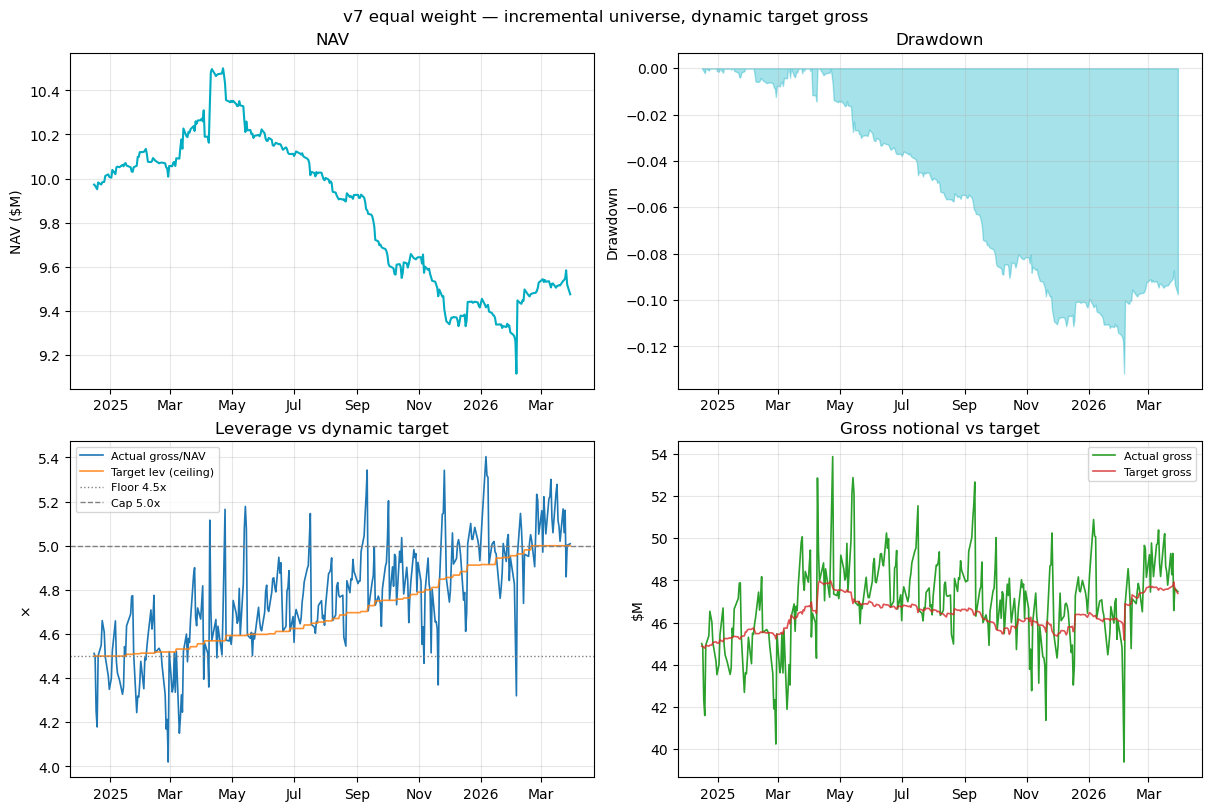

In [11]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ref = max(LEVERAGE_RUNS)
bt = ALL_BT[ref]
fig, axes = plt.subplots(2, 2, figsize=(12, 8), layout="constrained")
fig.suptitle("v7 equal weight — incremental universe, dynamic target gross")

ax = axes[0, 0]
ax.plot(bt.index, bt["nav"] / 1e6, color="#00ACC1", lw=1.5)
ax.set_ylabel("NAV ($M)"); ax.set_title("NAV"); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
nav = bt["nav"]
dd = (nav - nav.cummax()) / nav.cummax()
ax.fill_between(dd.index, dd, 0, alpha=0.35, color="#00ACC1")
ax.set_ylabel("Drawdown"); ax.set_title("Drawdown"); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.plot(bt.index, bt["actual_leverage"], label="Actual gross/NAV", color="tab:blue", lw=1.2)
ax.plot(bt.index, bt["target_lev"], label="Target lev (ceiling)", color="tab:orange", lw=1.2, alpha=0.85)
ax.axhline(V7_TARGET_LEV_START, color="gray", ls=":", lw=1, label=f"Floor {V7_TARGET_LEV_START}x")
ax.axhline(V7_TARGET_LEV_END, color="gray", ls="--", lw=1, label=f"Cap {V7_TARGET_LEV_END}x")
ax.set_ylabel("×"); ax.set_title("Leverage vs dynamic target"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(bt.index, bt["gross_notional"] / 1e6, label="Actual gross", color="tab:green", lw=1.2)
ax.plot(bt.index, bt["tgt_gross_nav"] / 1e6, label="Target gross", color="tab:red", lw=1.2, alpha=0.8)
ax.set_ylabel("$M"); ax.set_title("Gross notional vs target"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

for ax in axes.flat:
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
plt.show()


,pair,pnl,borrow_paid,net_pnl_after_borrow,avg_gross,ratio,ratio_net
39,ETHA/ETHU,47460.263055,2808.541206,44651.721849,432334.594298,0.109777,0.103280
14,TSLA/TSLL,58687.443517,15980.885509,42706.558007,432597.625045,0.135663,0.098721
24,TSLA/TSLR,55313.529769,13028.435579,42285.094190,432576.779100,0.127870,0.097752
26,TSLA/TSLT,64882.819964,23542.736029,41340.083935,432534.515736,0.150006,0.095576
152,BMNR/BMNU,34386.975864,13429.823663,20957.152201,219653.579043,0.156551,0.095410
37,URA/URAA,47030.000251,4500.487797,42529.512453,451762.639464,0.104103,0.094141
40,ETHA/ETHT,53944.183449,19512.348072,34431.835377,432398.302683,0.124756,0.079630
28,IBIT/BITX,46701.888515,11982.236835,34719.651679,440141.113625,0.106107,0.078883
38,IBIT/BTCL,43060.031824,8601.231708,34458.800116,440226.653098,0.097813,0.078275
2,SOXX/SOXL,34382.653679,659.372430,33723.281249,446422.558184,0.077018,0.075541


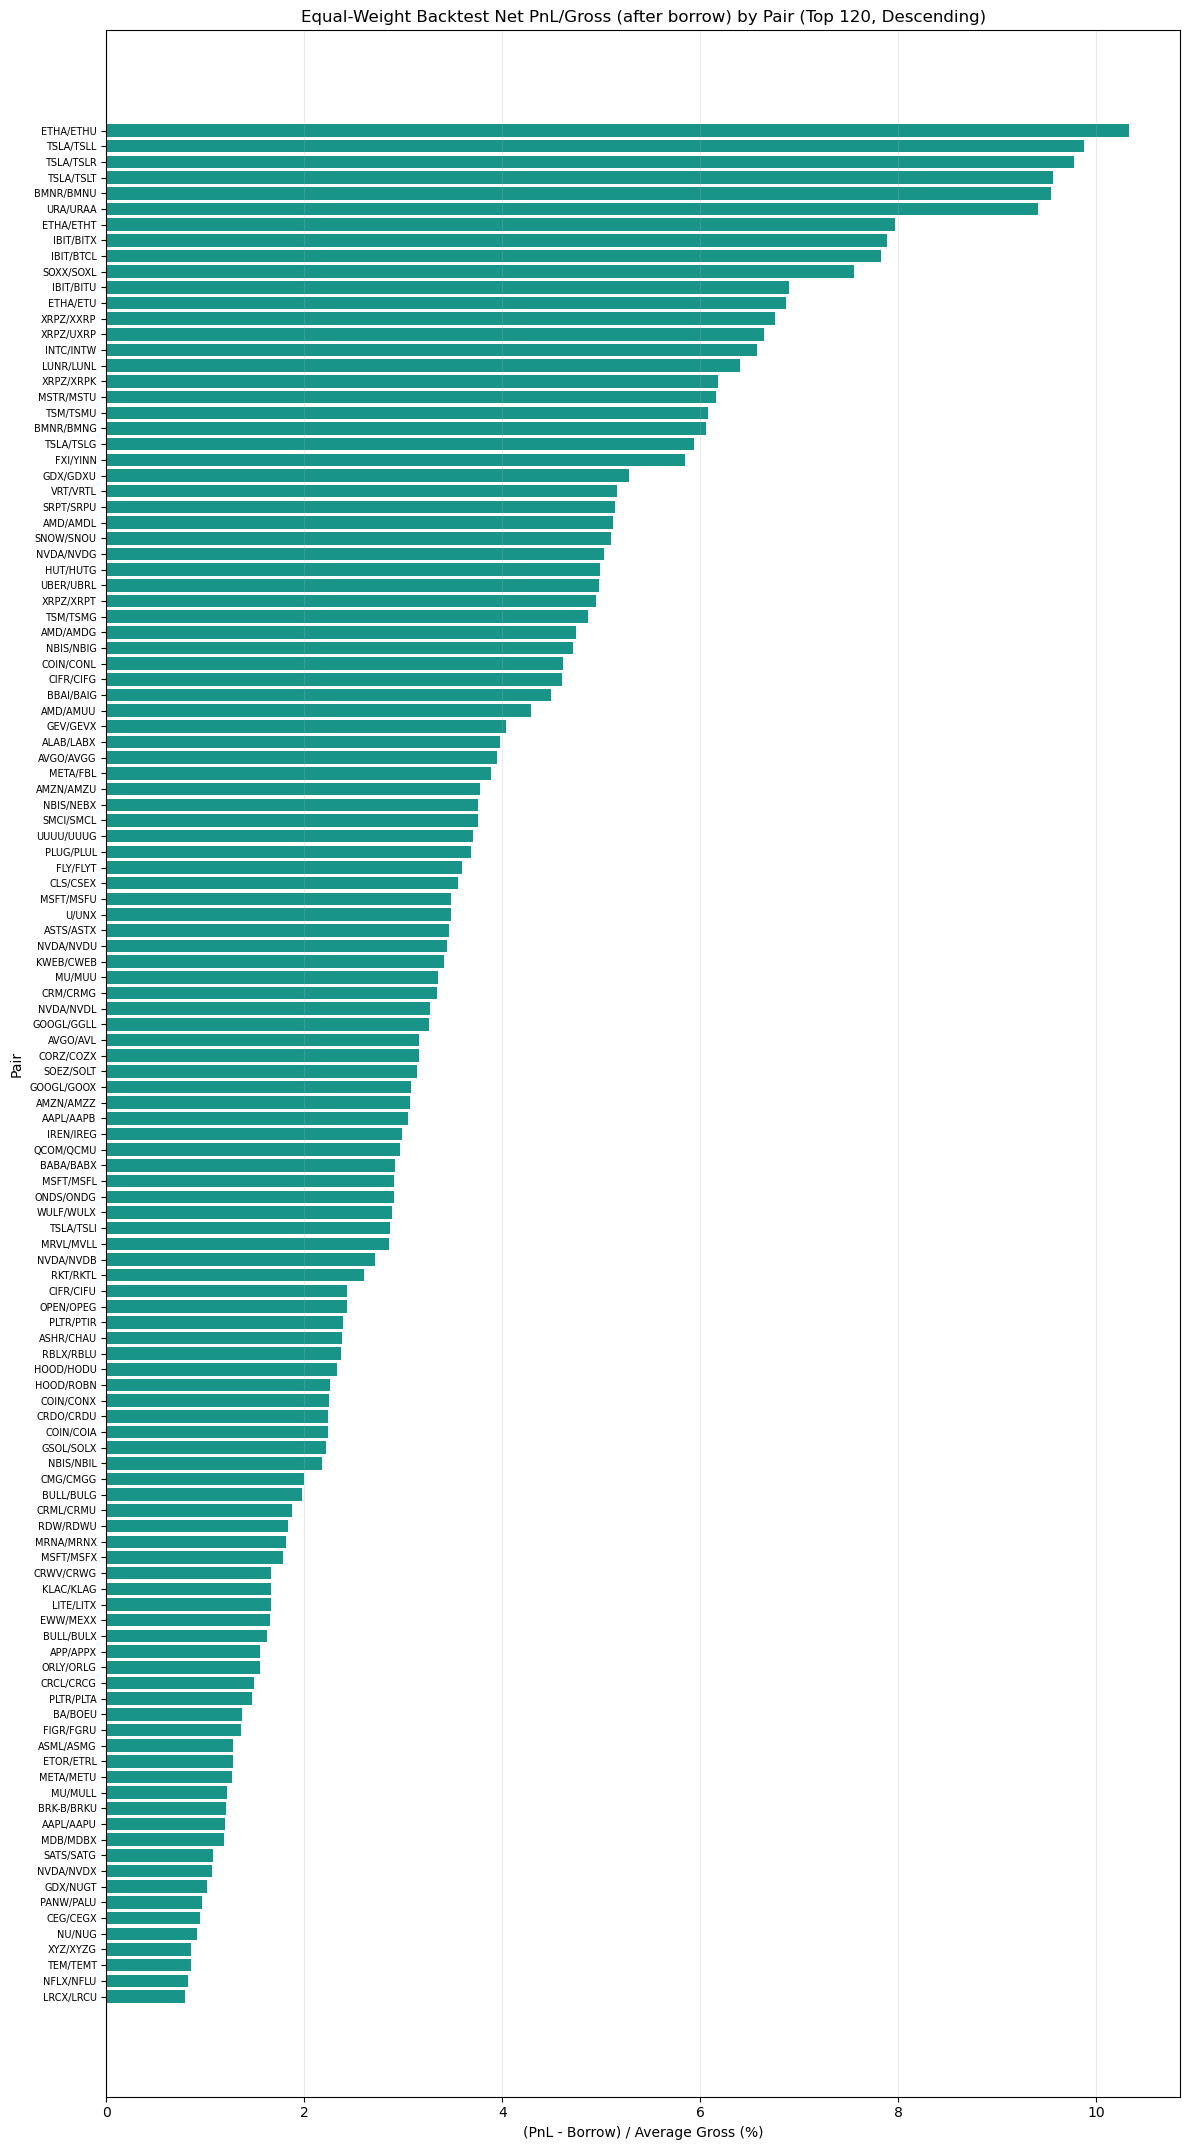

In [12]:
# ---- EW diagnostic: PnL/Gross by pair (descending) ----
import matplotlib.pyplot as plt

# Use saved EW objects when available; otherwise derive from ALL_*.
if "EW_PAIR_PNL" in globals() and "EW_PAIR_GROSS" in globals() and "ref_lev" in globals():
    _ppnl = EW_PAIR_PNL[ref_lev]
    _pgross = EW_PAIR_GROSS[ref_lev]
    _pborrow = EW_PAIR_BORROW[ref_lev] if "EW_PAIR_BORROW" in globals() and ref_lev in EW_PAIR_BORROW else {}
elif "ALL_PAIR_PNL" in globals() and "ALL_PAIR_GROSS" in globals() and "LEVERAGE_RUNS" in globals():
    _ref = max(LEVERAGE_RUNS)
    _ppnl = ALL_PAIR_PNL[_ref]
    _pgross = ALL_PAIR_GROSS[_ref]
    _pborrow = ALL_PAIR_BORROW[_ref] if "ALL_PAIR_BORROW" in globals() and _ref in ALL_PAIR_BORROW else {}
else:
    raise RuntimeError("Run the equal-weight backtest cells first (missing pair PnL/Gross objects).")

rows = []
for etf, d in _ppnl.items():
    pair = f"{d['und']}/{etf}"
    total_pnl = float(d.get("long", 0.0)) + float(d.get("short", 0.0))
    borrow_paid = float(_pborrow.get(etf, 0.0))
    net_pnl = total_pnl - borrow_paid
    avg_gross = float(_pgross[pair].mean()) if pair in _pgross.columns else np.nan
    ratio = total_pnl / avg_gross if (pd.notna(avg_gross) and avg_gross > 0) else np.nan
    ratio_net = net_pnl / avg_gross if (pd.notna(avg_gross) and avg_gross > 0) else np.nan
    rows.append({
        "pair": pair,
        "pnl": total_pnl,
        "borrow_paid": borrow_paid,
        "net_pnl_after_borrow": net_pnl,
        "avg_gross": avg_gross,
        "ratio": ratio,
        "ratio_net": ratio_net,
    })

pnl_gross_df = pd.DataFrame(rows)
pnl_gross_df = pnl_gross_df[pnl_gross_df["ratio_net"].notna()].copy()
if pnl_gross_df.empty:
    raise RuntimeError("No valid net PnL/Gross ratios found.")

pnl_gross_df.sort_values("ratio_net", ascending=False, inplace=True)
display(pnl_gross_df.head(30))

plot_n = min(120, len(pnl_gross_df))
plot_df = pnl_gross_df.head(plot_n).sort_values("ratio_net", ascending=True)

fig_h = min(40, max(10, 0.18 * plot_n))
fig, ax = plt.subplots(figsize=(12, fig_h))
ax.barh(plot_df["pair"], 100 * plot_df["ratio_net"], color="#00897B", alpha=0.9)
ax.set_title(f"Equal-Weight Backtest Net PnL/Gross (after borrow) by Pair (Top {plot_n}, Descending)")
ax.set_xlabel("(PnL - Borrow) / Average Gross (%)")
ax.set_ylabel("Pair")
ax.grid(axis="x", alpha=0.25)
ax.tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.show()


## v8 Diamond Creek Fund Weights (PnL/Gross + NET Decay + Shares Cap)

Saves the **equal-weight** run to `EW_*`, writes **`data/backtest/v8_pnl_decay_shares_weights.csv`**, and then re-runs the same engine with those `PAIR_WEIGHTS` loaded as the **Diamond Creek Fund** sizing profile.

Construction summary:
- `PnL/Gross` component from the equal-weight v8 run
- `decay` component from `data/etf_screened_today.csv` using `decay_score`
- convex blend using `CFG['mix_decay_weight']`
- shares-availability capacity cap from `shares_available` and `CFG['short_avail_use_pct']`
- cap-ramp schedule: constrained names step up over `CFG['cap_ramp_rebals']` rebalances toward max allowed weight


In [13]:
# Legacy optimizer removed.
raise RuntimeError("Legacy cell removed. Use the explainable predictive optimizer cell.")

EW_BT = dict(ALL_BT)
EW_PAIR_PNL = dict(ALL_PAIR_PNL)
EW_PAIR_BORROW = dict(ALL_PAIR_BORROW) if "ALL_PAIR_BORROW" in globals() else {}
EW_PAIR_NET = dict(ALL_PAIR_NET)
EW_PAIR_GROSS = dict(ALL_PAIR_GROSS)

out = Path("data/backtest")
out.mkdir(parents=True, exist_ok=True)
for lev in LEVERAGE_RUNS:
    EW_BT[lev].to_csv(out / f"v8_ew_nav_{lev}x.csv")
print("Equal-weight v8 NAV series saved.")

ref_lev = max(LEVERAGE_RUNS)
ppnl = EW_PAIR_PNL[ref_lev]
ppair_borrow = EW_PAIR_BORROW.get(ref_lev, {}) if "EW_PAIR_BORROW" in globals() else {}
pgross = EW_PAIR_GROSS[ref_lev]

pnl_gross = {}
for etf, d in ppnl.items():
    total_pnl = float(d.get("long", 0.0)) + float(d.get("short", 0.0))
    pair_borrow_paid = float(ppair_borrow.get(etf, 0.0))
    net_pnl_after_borrow = total_pnl - pair_borrow_paid
    col = f"{d['und']}/{etf}"
    avg_gross = float(pgross[col].mean()) if col in pgross.columns else np.nan
    ratio = total_pnl / avg_gross if (pd.notna(avg_gross) and avg_gross > 0) else 0.0
    ratio_net = net_pnl_after_borrow / avg_gross if (pd.notna(avg_gross) and avg_gross > 0) else 0.0
    pnl_gross[etf] = {
        "und": d["und"],
        "pnl": total_pnl,
        "pair_borrow_paid": pair_borrow_paid,
        "net_pnl_after_borrow": net_pnl_after_borrow,
        "avg_gross": avg_gross,
        "ratio": ratio,
        "ratio_net": ratio_net,
    }

# ---- Load screener decay + shares available ----
screened_path = Path("../data/etf_screened_today.csv")
if not screened_path.exists():
    run_files = sorted(Path("data/runs").glob("*/etf_screened_today.csv"))
    if not run_files:
        raise FileNotFoundError("Could not find data/etf_screened_today.csv or data/runs/*/etf_screened_today.csv")
    screened_path = run_files[-1]

screen = pd.read_csv(screened_path)
screen.columns = [str(c).strip() for c in screen.columns]
if "ETF" not in screen.columns:
    raise KeyError("Screener file must include an ETF column")

screen["ETF"] = screen["ETF"].astype(str).str.upper()

decay_col = "decay_score"
if decay_col not in screen.columns:
    raise KeyError("Screener file missing required decay_score column")

screen[decay_col] = pd.to_numeric(screen[decay_col], errors="coerce").fillna(0.0)
if "net_decay_annual" in screen.columns:
    screen["net_decay_annual"] = pd.to_numeric(screen["net_decay_annual"], errors="coerce").fillna(0.0)
else:
    screen["net_decay_annual"] = np.nan

if "shares_available" in screen.columns:
    screen["shares_available"] = pd.to_numeric(screen["shares_available"], errors="coerce")
else:
    screen["shares_available"] = np.nan

# Optional AUM inputs (USD). Prefer explicit AUM, then AUM_M, then vendor asset fields.
if "AUM" in screen.columns:
    screen["aum_usd"] = pd.to_numeric(screen["AUM"], errors="coerce")
elif "AUM_M" in screen.columns:
    screen["aum_usd"] = pd.to_numeric(screen["AUM_M"], errors="coerce") * 1e6
elif "totalAssets" in screen.columns:
    screen["aum_usd"] = pd.to_numeric(screen["totalAssets"], errors="coerce")
elif "netAssets" in screen.columns:
    screen["aum_usd"] = pd.to_numeric(screen["netAssets"], errors="coerce")
else:
    screen["aum_usd"] = np.nan

screen["aum_usd"] = pd.to_numeric(screen["aum_usd"], errors="coerce")
screen.loc[screen["aum_usd"] <= 0, "aum_usd"] = np.nan
screen["aum_source"] = np.where(screen["aum_usd"].notna(), "screen", "missing")

# Backfill missing AUM from yfinance with a local cache.
missing_aum = screen["aum_usd"].isna()
if missing_aum.any():
    try:
        import yfinance as yf

        aum_cache_path = Path("data/backtest/etf_aum_cache.csv")
        aum_cache_path.parent.mkdir(parents=True, exist_ok=True)
        if aum_cache_path.exists():
            aum_cache = pd.read_csv(aum_cache_path)
            if not {"ETF", "aum_usd"}.issubset(aum_cache.columns):
                aum_cache = pd.DataFrame(columns=["ETF", "aum_usd"])
        else:
            aum_cache = pd.DataFrame(columns=["ETF", "aum_usd"])

        if not aum_cache.empty:
            aum_cache["ETF"] = aum_cache["ETF"].astype(str).str.upper().str.strip()
            aum_cache["aum_usd"] = pd.to_numeric(aum_cache["aum_usd"], errors="coerce")
            cache_map = dict(zip(aum_cache["ETF"], aum_cache["aum_usd"]))
            from_cache = screen["ETF"].map(cache_map)
            use_cache = missing_aum & from_cache.notna() & (from_cache > 0)
            screen.loc[use_cache, "aum_usd"] = from_cache[use_cache]
            screen.loc[use_cache, "aum_source"] = "cache"

        still_missing = screen["aum_usd"].isna()
        if still_missing.any():
            fetch_syms = sorted(screen.loc[still_missing, "ETF"].dropna().astype(str).str.upper().unique())
            fetched = []
            for t in fetch_syms:
                q = t.replace(".", "-")
                val = np.nan
                try:
                    tk = yf.Ticker(q)
                    fi = getattr(tk, "fast_info", {}) or {}
                    if isinstance(fi, dict):
                        for k in ("total_assets", "totalAssets", "net_assets", "netAssets", "market_cap", "marketCap"):
                            v = fi.get(k)
                            if v is not None and pd.notna(v) and float(v) > 0:
                                val = float(v)
                                break
                    if pd.isna(val):
                        info = tk.info or {}
                        for k in ("totalAssets", "netAssets", "fundAssets", "marketCap"):
                            v = info.get(k)
                            if v is not None and pd.notna(v) and float(v) > 0:
                                val = float(v)
                                break
                except Exception:
                    pass

                if pd.notna(val) and val > 0:
                    fetched.append((t, float(val)))

            if fetched:
                fetched_df = pd.DataFrame(fetched, columns=["ETF", "aum_usd"])
                fetch_map = dict(zip(fetched_df["ETF"], fetched_df["aum_usd"]))
                from_fetch = screen["ETF"].map(fetch_map)
                use_fetch = screen["aum_usd"].isna() & from_fetch.notna() & (from_fetch > 0)
                screen.loc[use_fetch, "aum_usd"] = from_fetch[use_fetch]
                screen.loc[use_fetch, "aum_source"] = "yfinance"

                aum_cache = pd.concat([aum_cache, fetched_df], ignore_index=True)
                aum_cache = aum_cache.dropna(subset=["ETF"]).copy()
                aum_cache["ETF"] = aum_cache["ETF"].astype(str).str.upper().str.strip()
                aum_cache["aum_usd"] = pd.to_numeric(aum_cache["aum_usd"], errors="coerce")
                aum_cache = aum_cache[aum_cache["aum_usd"].notna() & (aum_cache["aum_usd"] > 0)]
                aum_cache = aum_cache.drop_duplicates(subset=["ETF"], keep="last").sort_values("ETF")
                aum_cache.to_csv(aum_cache_path, index=False)
    except Exception:
        pass

# Historical average shares_available by ticker (mean over each ticker's observed days).
runs_candidates = [
    Path("../data/runs"),
    Path("data/runs"),
    Path.cwd() / "../data/runs",
    Path.cwd() / "data/runs",
    Path.cwd().parent / "data/runs",
]
runs_root = None
for cand in runs_candidates:
    c = cand.resolve()
    if c.exists():
        runs_root = c
        break

shares_hist = []
if runs_root is not None:
    run_files = sorted(runs_root.glob("*/etf_screened_today.csv"))
    for rf in run_files:
        try:
            d = pd.read_csv(rf)
        except Exception:
            continue
        if "ETF" not in d.columns:
            continue
        d["ETF"] = d["ETF"].astype(str).str.upper()
        if "shares_available" in d.columns:
            d["shares_available"] = pd.to_numeric(d["shares_available"], errors="coerce")
        else:
            d["shares_available"] = np.nan
        d = d[["ETF", "shares_available"]].rename(columns={"ETF": "etf"})
        d["run_date"] = rf.parent.name
        shares_hist.append(d)

if shares_hist:
    sh = pd.concat(shares_hist, ignore_index=True)
    sh_agg = (
        sh.groupby("etf", dropna=False)["shares_available"]
        .agg(shares_available_avg="mean", shares_obs="count")
        .reset_index()
    )
    sh_agg["shares_obs"] = sh_agg["shares_obs"].astype(int)
    screen = screen.merge(sh_agg, left_on="ETF", right_on="etf", how="left")
    screen.drop(columns=["etf"], inplace=True)
else:
    screen["shares_available_avg"] = np.nan
    screen["shares_obs"] = 0

screen["shares_obs"] = pd.to_numeric(screen.get("shares_obs"), errors="coerce").fillna(0).astype(int)
screen["shares_available_for_cap"] = np.where(
    screen["shares_obs"] > 0,
    screen["shares_available_avg"],
    screen["shares_available"],
)

# Historical average borrow by ticker across data/runs snapshots.
borrow_hist = []
borrow_col_priority = ["borrow_net_annual", "borrow_current", "borrow_fee_annual"]
if runs_root is not None:
    snapshot_files = []
    for d in sorted(runs_root.glob("*")):
        if not d.is_dir():
            continue
        f_screen = d / "etf_screened_today.csv"
        f_trades = d / "proposed_trades.csv"
        if f_screen.exists():
            snapshot_files.append(f_screen)
        elif f_trades.exists():
            snapshot_files.append(f_trades)

    for p in [Path("data/etf_screened_today.csv"), Path("../data/etf_screened_today.csv")]:
        if p.exists():
            snapshot_files.append(p)
            break

    for rf in snapshot_files:
        try:
            d = pd.read_csv(rf)
        except Exception:
            continue
        if "ETF" not in d.columns:
            continue
        col = next((c for c in borrow_col_priority if c in d.columns), None)
        if col is None:
            continue
        b = d[["ETF", col]].copy()
        b["ETF"] = b["ETF"].astype(str).str.upper().str.strip()
        b["borrow_rate"] = pd.to_numeric(b[col], errors="coerce")
        b = b[b["ETF"].ne("") & b["borrow_rate"].notna()]
        b = b[np.isfinite(b["borrow_rate"])].copy()
        borrow_hist.append(b[["ETF", "borrow_rate"]])

if borrow_hist:
    bh = pd.concat(borrow_hist, ignore_index=True)

    def _trimmed_mean_drop2(s: pd.Series) -> float:
        x = pd.to_numeric(s, errors="coerce").dropna().sort_values()
        if len(x) <= 4:
            return float(x.mean()) if len(x) else np.nan
        return float(x.iloc[2:-2].mean())

    bh_mean = bh.groupby("ETF")["borrow_rate"].apply(_trimmed_mean_drop2).rename("borrow_avg_annual")
    bh_obs = bh.groupby("ETF")["borrow_rate"].size().rename("borrow_obs")
    bh_agg = pd.concat([bh_mean, bh_obs], axis=1).reset_index()
    screen = screen.merge(bh_agg, on="ETF", how="left")
else:
    screen["borrow_avg_annual"] = np.nan
    screen["borrow_obs"] = 0

for c in ["borrow_current", "borrow_net_annual", "blended_gross_decay", "expected_gross_decay_annual", "gross_decay_annual"]:
    if c in screen.columns:
        screen[c] = pd.to_numeric(screen[c], errors="coerce")
    else:
        screen[c] = np.nan

screen["borrow_avg_annual"] = pd.to_numeric(screen.get("borrow_avg_annual"), errors="coerce")
screen["borrow_obs"] = pd.to_numeric(screen.get("borrow_obs"), errors="coerce").fillna(0).astype(int)

# Use historical average borrow when available; otherwise fall back to current/net borrow.
screen["borrow_for_weight"] = (
    screen["borrow_avg_annual"]
    .combine_first(screen["borrow_current"])
    .combine_first(screen["borrow_net_annual"])
    .fillna(float(CFG.get("fallback_borrow_rate", 0.02)))
)

# Adapted from daily_screener: decay_score = blended_gross_decay - borrow.
# Here borrow is historical average over run snapshots.
screen["gross_decay_for_weight"] = (
    screen["blended_gross_decay"]
    .combine_first(screen["expected_gross_decay_annual"])
    .combine_first(screen["gross_decay_annual"])
)
screen["decay_score_hist_borrow"] = np.where(
    screen["gross_decay_for_weight"].notna(),
    screen["gross_decay_for_weight"] - screen["borrow_for_weight"],
    np.nan,
)

# Final non-NA AUM fill: underlying median, then global median.
known_aum = screen.loc[screen["aum_usd"].notna() & (screen["aum_usd"] > 0), "aum_usd"]
global_med_aum = float(known_aum.median()) if len(known_aum) else np.nan

if "Underlying" in screen.columns:
    und_med = (
        screen.loc[screen["aum_usd"].notna() & (screen["aum_usd"] > 0)]
        .groupby("Underlying", dropna=False)["aum_usd"]
        .median()
    )
    und_fill = screen["Underlying"].map(und_med)
    use_und = screen["aum_usd"].isna() & und_fill.notna() & (und_fill > 0)
    screen.loc[use_und, "aum_usd"] = und_fill[use_und]
    screen.loc[use_und, "aum_source"] = "underlying_median"

if pd.notna(global_med_aum) and global_med_aum > 0:
    use_global = screen["aum_usd"].isna()
    screen.loc[use_global, "aum_usd"] = global_med_aum
    screen.loc[use_global, "aum_source"] = "global_median"

# Hard fallback to avoid NA in reporting tables.
use_zero = screen["aum_usd"].isna()
if use_zero.any():
    screen.loc[use_zero, "aum_usd"] = 0.0
    screen.loc[use_zero, "aum_source"] = "fallback_zero"

screen["aum_usd"] = pd.to_numeric(screen["aum_usd"], errors="coerce").fillna(0.0)

decay_col = "decay_score_hist_borrow"

screener_map = screen.set_index("ETF")[[
    decay_col,
    "gross_decay_for_weight",
    "borrow_for_weight",
    "borrow_avg_annual",
    "borrow_obs",
    "net_decay_annual",
    "shares_available",
    "shares_available_avg",
    "shares_available_for_cap",
    "shares_obs",
    "aum_usd",
    "aum_source",
]].to_dict("index")

pw = CFG.get("weight_power", 2)
decay_pw = CFG.get("decay_weight_power", 1.25)
mix_decay = float(CFG.get("mix_decay_weight", 0.45))
mix_decay = min(1.0, max(0.0, mix_decay))

etfs = sorted(pnl_gross.keys())
pnl_component = pd.Series({etf: max(0.0, pnl_gross[etf]["ratio_net"]) ** pw for etf in etfs}, dtype=float)
decay_component = pd.Series(
    {etf: max(0.0, float(screener_map.get(etf, {}).get(decay_col, 0.0))) ** decay_pw for etf in etfs},
    dtype=float,
)

if pnl_component.sum() <= 0:
    pnl_component[:] = 1.0
if decay_component.sum() <= 0:
    decay_component[:] = 1.0

pnl_norm = pnl_component / pnl_component.sum()
decay_norm = decay_component / decay_component.sum()
combined_signal = (1.0 - mix_decay) * pnl_norm + mix_decay * decay_norm
raw_weight = combined_signal / combined_signal.sum()

ranked = sorted(etfs, key=lambda e: float(combined_signal.get(e, 0.0)), reverse=True)

# Optional concentration tilt: increase allocation to largest signals.
conc_pw = float(CFG.get("position_concentration_power", 1.0))
if conc_pw > 1.0:
    raw_weight = raw_weight.pow(conc_pw)
    if raw_weight.sum() > 0:
        raw_weight = raw_weight / raw_weight.sum()

# ---- Capacity caps from shares_available ----
beta_map = {etf: abs(bv) for etf, _, bv in UNIVERSE}
ref_date = EW_BT[ref_lev].index[-1]
ref_tgt_gross = float(EW_BT[ref_lev]["tgt_gross_nav"].iloc[-1])
short_avail_use_pct = float(CFG.get("short_avail_use_pct", 0.10))
max_pair_weight_cap = float(CFG.get("max_pair_weight_cap", 0.20))
missing_shares_cap = float(CFG.get("missing_shares_cap", 0.01))

# For table translation from weights -> dollars.
assumed_nav_usd = float(CFG.get("capital_usd", 10_000_000))
assumed_target_lev = float(EW_BT[ref_lev]["target_lev"].iloc[-1]) if "target_lev" in EW_BT[ref_lev].columns else float(V7_TARGET_LEV_END)
assumed_target_gross_usd = assumed_nav_usd * assumed_target_lev

cap_frac = {}
for etf in etfs:
    babs = max(1e-9, beta_map.get(etf, 2.0))
    hr = 1.0 / babs
    short_frac = hr / (1.0 + hr)

    px_ser = PRICES.get(etf)
    px_e = float(px_ser.asof(ref_date)) if px_ser is not None else np.nan
    sh_av = screener_map.get(etf, {}).get("shares_available_for_cap", np.nan)

    if pd.isna(sh_av) or sh_av <= 0 or pd.isna(px_e) or px_e <= 0:
        cap = missing_shares_cap
    else:
        cap_shares = float(sh_av) * short_avail_use_pct
        cap = (cap_shares * px_e) / max(1.0, ref_tgt_gross * short_frac)

    cap_frac[etf] = min(max_pair_weight_cap, max(0.0, cap))

cap_s = pd.Series(cap_frac, dtype=float)

# If strict caps are infeasible, minimally relax toward desired weights.
if cap_s.sum() < 1.0:
    cap_s = np.maximum(cap_s, raw_weight)


def project_to_capped_simplex(desired: pd.Series, caps: pd.Series, tol: float = 1e-12) -> pd.Series:
    """Project desired weights onto {w>=0, w<=caps, sum(w)=1}.

    This keeps final weights <= caps whenever feasible.
    """
    desired = desired.astype(float).copy()
    caps = caps.astype(float).copy().clip(lower=0.0)

    if desired.sum() <= 0:
        desired[:] = 1.0
    desired = desired / desired.sum()

    # Ensure feasibility (sum caps must be >= 1).
    if caps.sum() < 1.0:
        caps = np.maximum(caps, desired)

    w = pd.Series(0.0, index=desired.index)
    free = list(desired.index)
    remaining = 1.0

    while free and remaining > tol:
        base = desired.loc[free]
        if base.sum() <= 0:
            trial = pd.Series(remaining / len(free), index=free)
        else:
            trial = remaining * base / base.sum()

        hit = trial > (caps.loc[free] + tol)
        if not hit.any():
            w.loc[free] = trial
            remaining = 0.0
            break

        hit_idx = list(trial.index[hit])
        w.loc[hit_idx] = caps.loc[hit_idx]
        remaining = 1.0 - float(w.sum())
        free = [k for k in free if k not in hit_idx]

    # Safety: fill any tiny remainder by available headroom.
    if remaining > tol and free:
        room = (caps.loc[free] - w.loc[free]).clip(lower=0.0)
        if room.sum() > tol:
            w.loc[free] += remaining * room / room.sum()

    w = w.clip(lower=0.0)
    if w.sum() <= 0:
        w = desired.copy()

    w = w / w.sum()
    w = np.minimum(w, caps)

    # Final small renorm without violating caps.
    rem = 1.0 - float(w.sum())
    if rem > tol:
        room = (caps - w).clip(lower=0.0)
        if room.sum() > tol:
            w += rem * room / room.sum()
    if w.sum() > 0:
        w = w / w.sum()
    return w


final_weight = project_to_capped_simplex(raw_weight, cap_s)
weights_dict = final_weight.to_dict()

print(f"Using screener: {screened_path}")
if runs_root is not None:
    print(f"Shares-average history root: {runs_root}")
print(
    f"Signal: net pnl/gross (after pair borrow) + (gross_decay - avg_borrow) | decay column: {decay_col} | mix_decay_weight={mix_decay:.2f} | "
    f"weight_power={pw} | decay_weight_power={decay_pw} | concentration_power={conc_pw:.2f}"
)
print(
    f"Borrow source for weighting: historical average where available "
    f"(tickers with history: {(screen['borrow_obs'] > 0).sum()}/{len(screen)})"
)
print(
    f"Shares cap: use={short_avail_use_pct:.1%}, hard pair cap={max_pair_weight_cap:.1%}, "
    f"missing_shares_cap={missing_shares_cap:.1%}"
)
print(
    f"Shares source for cap: per-ticker historical mean where available "
    f"(tickers with history: {(screen['shares_obs'] > 0).sum()}/{len(screen)})"
)
print(
    f"Dollar translation assumptions: NAV=${assumed_nav_usd:,.0f}, "
    f"target gross={assumed_target_lev:.2f}x -> ${assumed_target_gross_usd:,.0f}"
)
print(
    f"AUM availability after fill: {screen['aum_usd'].notna().sum()}/{len(screen)} tickers | "
    f"sources: screen={(screen['aum_source']=='screen').sum()}, cache={(screen['aum_source']=='cache').sum()}, "
    f"yfinance={(screen['aum_source']=='yfinance').sum()}, underlying_med={(screen['aum_source']=='underlying_median').sum()}, "
    f"global_med={(screen['aum_source']=='global_median').sum()}, zero_fallback={(screen['aum_source']=='fallback_zero').sum()}"
)
print(f"Top 5 concentration: {sum(sorted(weights_dict.values(), reverse=True)[:5]):.1%}")
print(f"Top 10 concentration: {sum(sorted(weights_dict.values(), reverse=True)[:10]):.1%}")

w_rows = []
for etf in ranked:
    d = pnl_gross.get(etf, {"und": None, "pnl": 0.0, "pair_borrow_paid": 0.0, "net_pnl_after_borrow": 0.0, "avg_gross": np.nan, "ratio": 0.0, "ratio_net": 0.0})

    sh_cur = screener_map.get(etf, {}).get("shares_available", np.nan)
    sh_avg = screener_map.get(etf, {}).get("shares_available_avg", np.nan)
    sh_cap = screener_map.get(etf, {}).get("shares_available_for_cap", np.nan)
    sh_obs_raw = screener_map.get(etf, {}).get("shares_obs", 0)
    sh_obs = int(sh_obs_raw) if pd.notna(sh_obs_raw) else 0

    dcol_val = float(screener_map.get(etf, {}).get(decay_col, 0.0))
    nd_val = float(screener_map.get(etf, {}).get("net_decay_annual", np.nan))
    gross_decay_val = float(screener_map.get(etf, {}).get("gross_decay_for_weight", np.nan))
    borrow_w_val = float(screener_map.get(etf, {}).get("borrow_for_weight", np.nan))
    borrow_avg_val = float(screener_map.get(etf, {}).get("borrow_avg_annual", np.nan))
    borrow_obs_raw = screener_map.get(etf, {}).get("borrow_obs", 0)
    borrow_obs_val = int(borrow_obs_raw) if pd.notna(borrow_obs_raw) else 0

    aum_usd = float(screener_map.get(etf, {}).get("aum_usd", np.nan))
    aum_source = str(screener_map.get(etf, {}).get("aum_source", "missing"))

    babs = max(1e-9, beta_map.get(etf, 2.0))
    hr = 1.0 / babs
    short_frac = hr / (1.0 + hr)
    px_ser = PRICES.get(etf)
    px_e = float(px_ser.asof(ref_date)) if px_ser is not None else np.nan

    pair_target_gross_usd = float(weights_dict.get(etf, 0.0)) * assumed_target_gross_usd
    short_target_usd = pair_target_gross_usd * short_frac
    max_short_capacity_usd_full = (float(sh_cap) * float(px_e)) if (pd.notna(sh_cap) and pd.notna(px_e) and sh_cap > 0 and px_e > 0) else np.nan
    max_short_capacity_usd_used = (
        float(sh_cap) * short_avail_use_pct * float(px_e)
        if (pd.notna(sh_cap) and pd.notna(px_e) and sh_cap > 0 and px_e > 0)
        else np.nan
    )

    w_rows.append(
        {
            "etf": etf,
            "und": d["und"],
            "pnl": d["pnl"],
            "pair_borrow_paid": d["pair_borrow_paid"],
            "net_pnl_after_borrow": d["net_pnl_after_borrow"],
            "avg_gross": d["avg_gross"],
            "ratio": d["ratio"],
            "ratio_net": d["ratio_net"],
            "decay_col": decay_col,
            "decay_value": dcol_val,
            "gross_decay_for_weight": gross_decay_val,
            "borrow_for_weight": borrow_w_val,
            "borrow_avg_annual": borrow_avg_val,
            "borrow_obs": borrow_obs_val,
            "net_decay_annual": nd_val,
            "shares_available": sh_cur,
            "shares_available_avg": sh_avg,
            "shares_available_for_cap": sh_cap,
            "shares_obs": sh_obs,
            "aum_usd": aum_usd,
            "aum_m": aum_usd / 1e6 if pd.notna(aum_usd) else np.nan,
            "aum_source": aum_source,
            "etf_price": px_e,
            "short_frac": short_frac,
            "pair_target_gross_usd": pair_target_gross_usd,
            "short_target_usd": short_target_usd,
            "max_short_capacity_usd_full": max_short_capacity_usd_full,
            "max_short_capacity_usd_used": max_short_capacity_usd_used,
            "short_capacity_utilization": (short_target_usd / max_short_capacity_usd_used) if (pd.notna(max_short_capacity_usd_used) and max_short_capacity_usd_used > 0) else np.nan,
            "pnl_component": float(pnl_component.get(etf, 0.0)),
            "decay_component": float(decay_component.get(etf, 0.0)),
            "combined_signal": float(combined_signal.get(etf, 0.0)),
            "weight_raw": float(raw_weight.get(etf, 0.0)),
            "weight_cap": float(cap_s.get(etf, 0.0)),
            "weight": float(weights_dict.get(etf, 0.0)),
            "cap_binding": int(final_weight.get(etf, 0.0) >= cap_s.get(etf, 0.0) - 1e-9),
        }
    )

w_df = pd.DataFrame(w_rows)
weights_file_v9 = out / "v9_optimal_pnl_decay_borrow_weights.csv"
weights_file_legacy = out / "v8_pnl_decay_shares_weights.csv"
w_df.to_csv(weights_file_v9, index=False)
# Keep legacy filename for backward compatibility with older cells/scripts.
w_df.to_csv(weights_file_legacy, index=False)
print(f"Saved {len(w_df)} pair weights to {weights_file_v9.name} (and legacy {weights_file_legacy.name})")

print("\nv8 Diamond Creek Fund weighting (PnL/Gross + decay, capped by shares availability)")
print(
    f"{'Rank':>4s}  {'Pair':>18s}  {'Final W':>8s}  {'AUM($M)':>9s}  {'AUM Src':>9s}  {'ETF Px':>8s}  {'Shares(avg)':>12s}  {'Obs':>4s}  "
    f"{'Short$@10m':>11s}  {'ShAvg*Px$':>11s}  {'Use%Cap$':>11s}  {'Util':>7s}"
)
print(f"  {'-'*161}")
for i, row in enumerate(w_df.sort_values("weight", ascending=False).itertuples(index=False), 1):
    pair = f"{row.und}/{row.etf}"
    aum_txt = "NA" if pd.isna(row.aum_m) else f"{row.aum_m:,.0f}"
    aum_src_txt = str(row.aum_source)[:9]
    px_txt = "NA" if pd.isna(row.etf_price) else f"{row.etf_price:,.2f}"
    sh_txt = "NA" if pd.isna(row.shares_available_for_cap) else f"{row.shares_available_for_cap:,.0f}"
    short_txt = "NA" if pd.isna(row.short_target_usd) else f"{row.short_target_usd:,.0f}"
    full_cap_txt = "NA" if pd.isna(row.max_short_capacity_usd_full) else f"{row.max_short_capacity_usd_full:,.0f}"
    use_cap_txt = "NA" if pd.isna(row.max_short_capacity_usd_used) else f"{row.max_short_capacity_usd_used:,.0f}"
    util_txt = "NA" if pd.isna(row.short_capacity_utilization) else f"{row.short_capacity_utilization:,.0%}"
    print(
        f"  {i:3d}  {pair:>18s}  {row.weight:>7.2%}  {aum_txt:>9s}  {aum_src_txt:>9s}  {px_txt:>8s}  {sh_txt:>12s}  {int(row.shares_obs):>4d}  "
        f"{short_txt:>11s}  {full_cap_txt:>11s}  {use_cap_txt:>11s}  {util_txt:>7s}"
    )


RuntimeError: Legacy cell removed. Use the explainable predictive optimizer cell.

Borrow check (positive-weight pairs): weighted avg=12.03% vs equal-weight avg=18.76% (delta=-6.73%)
Spearman corr(weight, borrow_for_weight): -0.323  (should usually be <= 0)
Spearman corr(weight, gross pnl/gross):   +0.473
Spearman corr(weight, net pnl/gross):     +0.553  (should usually be >= 0)
Spearman corr(weight, combined_signal):   +0.759  (should be strongly > 0)


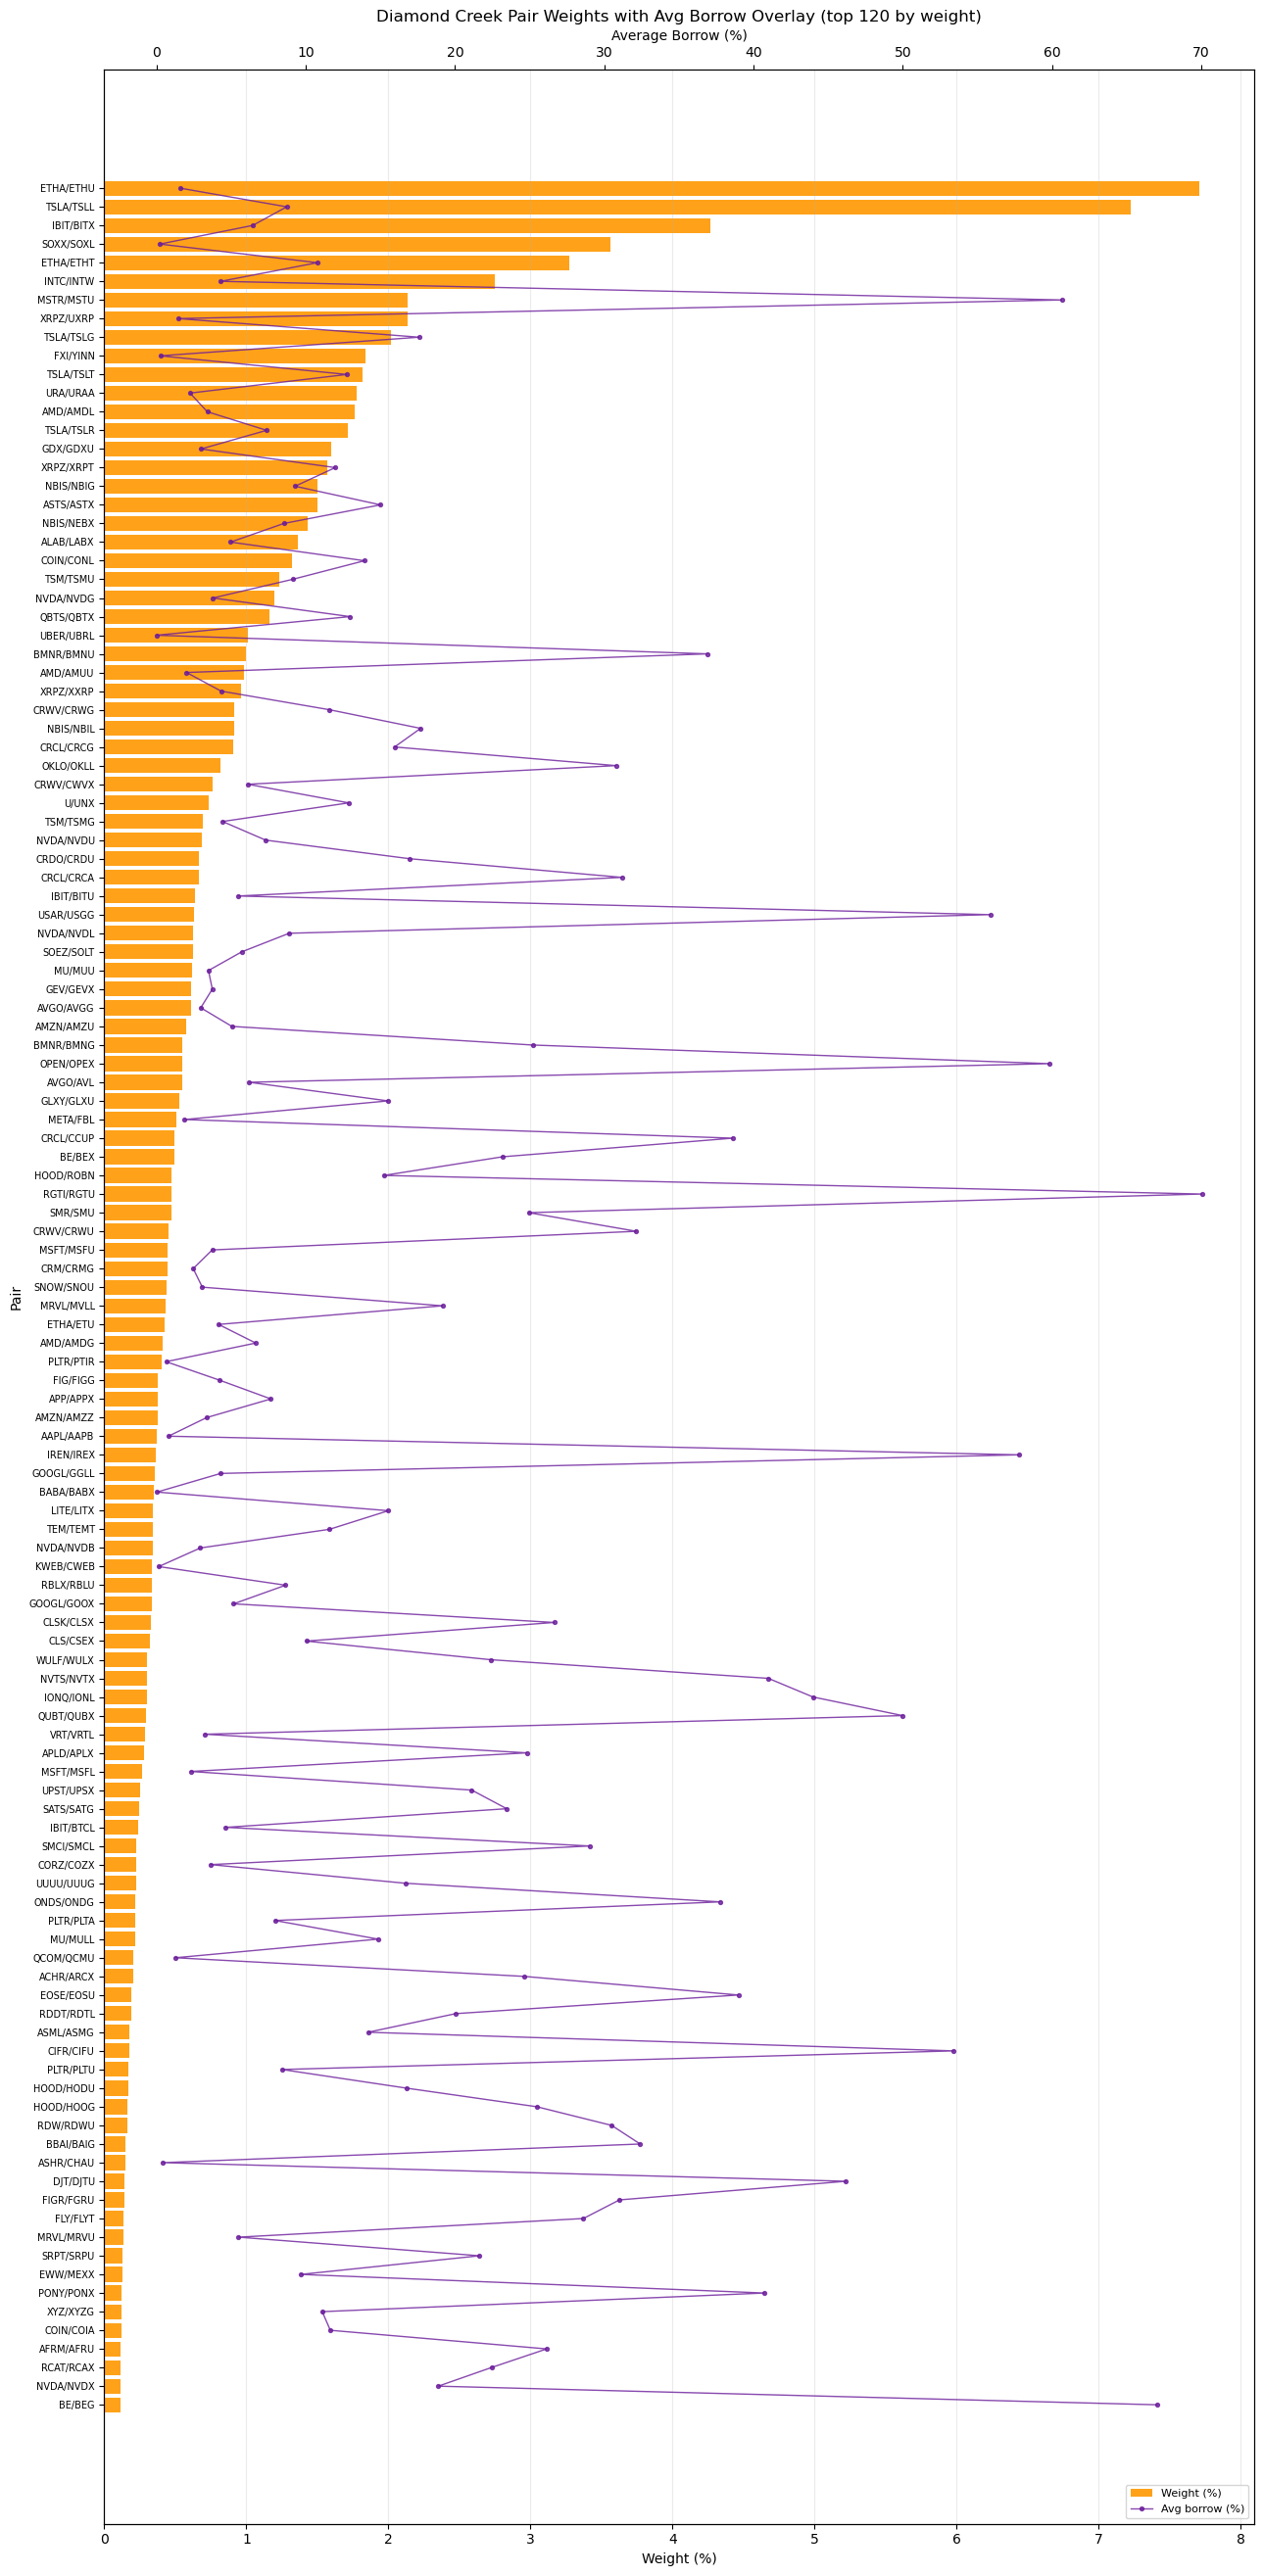

,pair,weight,borrow_for_weight,ratio,ratio_net,gross_decay_for_weight,decay_value,combined_signal
119,ETHA/ETHU,0.077090,0.015932,0.110737,0.104046,0.789495,0.773563,0.028321
118,TSLA/TSLL,0.072220,0.087235,0.142335,0.105484,0.495302,0.408067,0.026985
117,IBIT/BITX,0.042686,0.064422,0.112970,0.085804,0.445620,0.381198,0.018279
116,SOXX/SOXL,0.035647,0.002211,0.078211,0.077495,0.538098,0.535887,0.015995
115,ETHA/ETHT,0.032750,0.107677,0.124067,0.078691,0.770938,0.663261,0.017130
114,INTC/INTW,0.027494,0.043014,0.085996,0.069847,0.535305,0.492291,0.013196
113,MSTR/MSTU,0.021365,0.606505,0.319609,0.062611,1.086198,0.479693,0.010947
112,XRPZ/UXRP,0.021340,0.014566,0.068008,0.066456,0.808005,0.793439,0.013847
111,TSLA/TSLG,0.020204,0.175924,0.139792,0.065413,0.475807,0.299883,0.010866
110,FXI/YINN,0.018416,0.002482,0.061410,0.060609,0.368760,0.366278,0.009806


In [ ]:
# Legacy optimizer diagnostics removed.
raise RuntimeError("Legacy diagnostics cell removed. Use explainable optimizer outputs only.")

import matplotlib.pyplot as plt

if "w_df" not in globals() or w_df.empty:
    raise RuntimeError("Run the Diamond Creek weighting cell first (w_df not found).")

required_cols = {"und", "etf", "weight"}
if not required_cols.issubset(w_df.columns):
    raise RuntimeError(f"w_df missing required columns: {required_cols - set(w_df.columns)}")

pair_w = w_df.loc[w_df["weight"] > 0].copy()
if pair_w.empty:
    raise RuntimeError("No strictly positive weights found.")

pair_w["pair"] = pair_w["und"].astype(str) + "/" + pair_w["etf"].astype(str)
pair_w["borrow_for_weight"] = pd.to_numeric(pair_w.get("borrow_for_weight"), errors="coerce")
pair_w["ratio"] = pd.to_numeric(pair_w.get("ratio"), errors="coerce")
pair_w["ratio_net"] = pd.to_numeric(pair_w.get("ratio_net"), errors="coerce")
pair_w["combined_signal"] = pd.to_numeric(pair_w.get("combined_signal"), errors="coerce")

# Summary diagnostics to verify optimization behavior.
borrow_ok = pair_w["borrow_for_weight"].notna()
if borrow_ok.any():
    w_norm = pair_w.loc[borrow_ok, "weight"] / pair_w.loc[borrow_ok, "weight"].sum()
    weighted_borrow = float((w_norm * pair_w.loc[borrow_ok, "borrow_for_weight"]).sum())
    equal_borrow = float(pair_w.loc[borrow_ok, "borrow_for_weight"].mean())
    print(
        f"Borrow check (positive-weight pairs): weighted avg={weighted_borrow:.2%} vs equal-weight avg={equal_borrow:.2%} "
        f"(delta={weighted_borrow - equal_borrow:+.2%})"
    )

corr_w_borrow = pair_w[["weight", "borrow_for_weight"]].corr(method="spearman").iloc[0, 1] if borrow_ok.sum() > 2 else np.nan
corr_w_ratio = pair_w[["weight", "ratio"]].corr(method="spearman").iloc[0, 1] if pair_w["ratio"].notna().sum() > 2 else np.nan
corr_w_ratio_net = pair_w[["weight", "ratio_net"]].corr(method="spearman").iloc[0, 1] if pair_w["ratio_net"].notna().sum() > 2 else np.nan
corr_w_signal = pair_w[["weight", "combined_signal"]].corr(method="spearman").iloc[0, 1] if pair_w["combined_signal"].notna().sum() > 2 else np.nan
print(f"Spearman corr(weight, borrow_for_weight): {corr_w_borrow:+.3f}  (should usually be <= 0)")
print(f"Spearman corr(weight, gross pnl/gross):   {corr_w_ratio:+.3f}")
print(f"Spearman corr(weight, net pnl/gross):     {corr_w_ratio_net:+.3f}  (should usually be >= 0)")
print(f"Spearman corr(weight, combined_signal):   {corr_w_signal:+.3f}  (should be strongly > 0)")

# Plot more names and overlay average borrow on a second x-axis.
plot_n = min(120, len(pair_w))
plot_df = pair_w.sort_values("weight", ascending=False).head(plot_n).sort_values("weight", ascending=True).reset_index(drop=True)

fig_h = min(42, max(10, 0.22 * plot_n))
fig, ax = plt.subplots(figsize=(13, fig_h))
ax.barh(plot_df["pair"], 100 * plot_df["weight"], color="#FF9800", alpha=0.9, label="Weight (%)")
ax.set_title(f"Diamond Creek Pair Weights with Avg Borrow Overlay (top {plot_n} by weight)")
ax.set_xlabel("Weight (%)")
ax.set_ylabel("Pair")
ax.grid(True, axis="x", alpha=0.25)
ax.tick_params(axis="y", labelsize=7)

ax2 = ax.twiny()
ax2.plot(100 * plot_df["borrow_for_weight"], plot_df["pair"], color="#6A1B9A", marker="o", ms=2.8, lw=1.0, alpha=0.8, label="Avg borrow (%)")
ax2.set_xlabel("Average Borrow (%)")

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

# Display top allocations with borrow + pnl diagnostics.
cols = [
    "pair", "weight", "borrow_for_weight", "ratio", "ratio_net", "gross_decay_for_weight", "decay_value", "combined_signal"
]
cols = [c for c in cols if c in plot_df.columns]
display(plot_df.sort_values("weight", ascending=False)[cols].head(40))


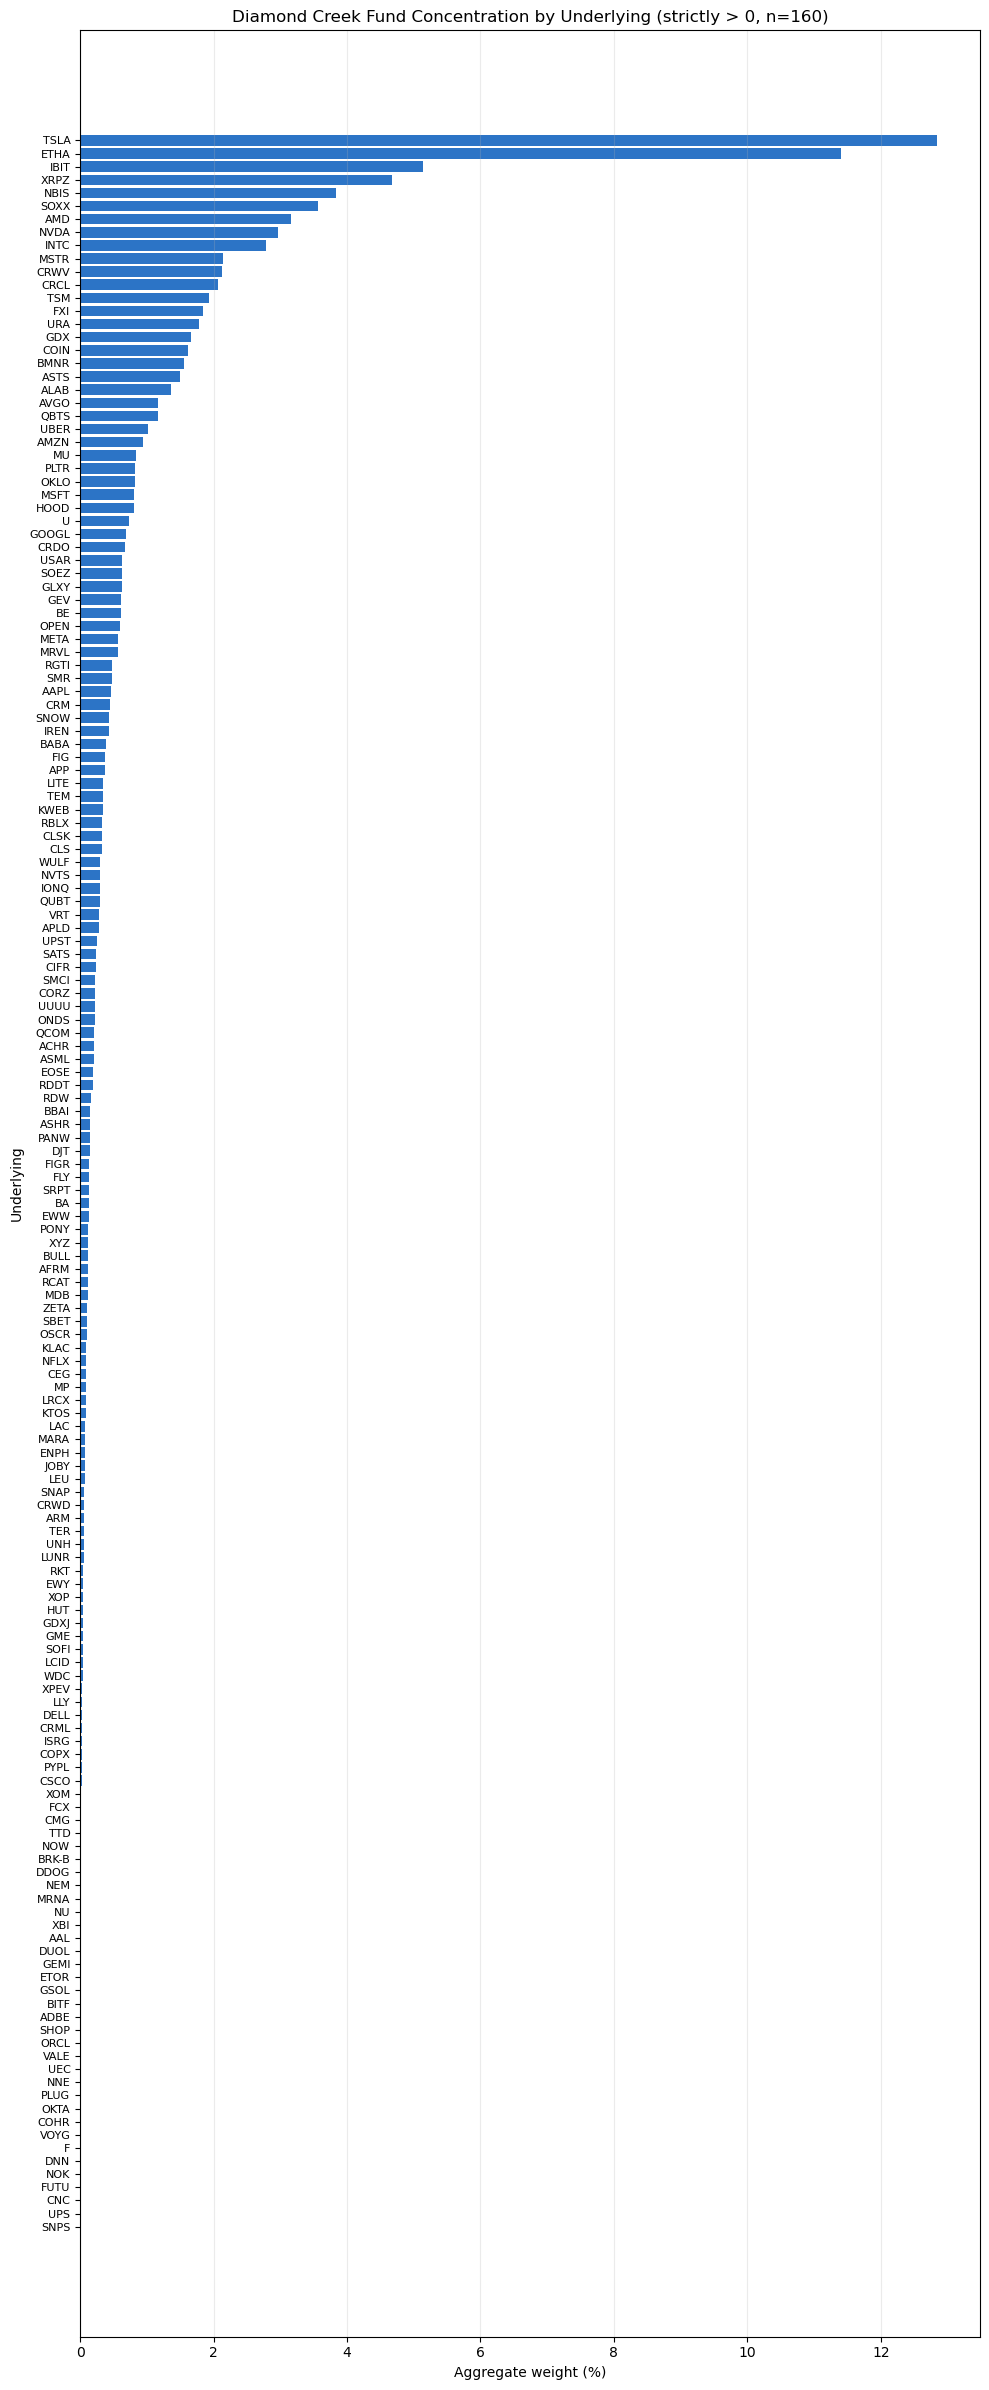

In [ ]:
# Legacy concentration diagnostics removed.
raise RuntimeError("Legacy concentration cell removed. Use explainable optimizer outputs only.")

import matplotlib.pyplot as plt

if "w_df" not in globals() or w_df.empty:
    raise RuntimeError("Run the Diamond Creek weighting cell first (w_df not found).")

und_w = (
    w_df.loc[w_df["weight"] > 0, ["und", "weight"]]
    .groupby("und", as_index=False)["weight"]
    .sum()
    .sort_values("weight", ascending=True)
)

if und_w.empty:
    raise RuntimeError("No strictly positive weights found for underlying concentration.")

n = len(und_w)
fig_h = min(24, max(6, 0.24 * n))
fig, ax = plt.subplots(figsize=(10, fig_h))

ax.barh(und_w["und"], und_w["weight"] * 100.0, color="#1565C0", alpha=0.9)
ax.set_title(f"Diamond Creek Fund Concentration by Underlying (strictly > 0, n={n})")
ax.set_xlabel("Aggregate weight (%)")
ax.set_ylabel("Underlying")
ax.grid(True, axis="x", alpha=0.25)
ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()


In [ ]:
# Legacy hyperparameter optimizer removed.
raise RuntimeError("Legacy hyperparameter optimizer removed. Use explainable predictive optimizer.")

from pathlib import Path
import itertools

# Use freshly computed w_df when available; otherwise load latest weights file.
if "w_df" in globals() and isinstance(w_df, pd.DataFrame) and not w_df.empty:
    opt_df = w_df.copy()
else:
    w_candidates = [
        Path("data/backtest/v9_optimal_pnl_decay_borrow_weights.csv"),
        Path("data/backtest/v8_pnl_decay_shares_weights.csv"),
        Path("notebooks/data/backtest/v9_optimal_pnl_decay_borrow_weights.csv"),
        Path("notebooks/data/backtest/v8_pnl_decay_shares_weights.csv"),
    ]
    w_path = next((p for p in w_candidates if p.exists()), None)
    if w_path is None:
        raise FileNotFoundError("No baseline weights file found for optimization sweep.")
    opt_df = pd.read_csv(w_path)

need_cols = {"etf", "ratio_net", "decay_value", "borrow_for_weight"}
missing = need_cols - set(opt_df.columns)
if missing:
    raise RuntimeError(f"Optimization input missing required columns: {missing}")

opt_df["etf"] = opt_df["etf"].astype(str).str.upper().str.strip()
opt_df = opt_df.drop_duplicates(subset=["etf"], keep="first").copy()
opt_df["ratio_net"] = pd.to_numeric(opt_df["ratio_net"], errors="coerce").fillna(0.0)
opt_df["decay_value"] = pd.to_numeric(opt_df["decay_value"], errors="coerce").fillna(0.0)
opt_df["borrow_for_weight"] = pd.to_numeric(opt_df["borrow_for_weight"], errors="coerce").fillna(0.0)

# Capacity caps inferred from prior run where available.
if "weight_cap" in opt_df.columns:
    cap_s = pd.to_numeric(opt_df["weight_cap"], errors="coerce").fillna(0.0).clip(lower=0.0)
else:
    cap_s = pd.Series(float(CFG.get("max_pair_weight_cap", 0.20)), index=opt_df.index)

# Make sure feasible simplex exists.
if cap_s.sum() < 1.0:
    # Minimal relaxation to feasibility.
    cap_s = cap_s + (1.0 - cap_s.sum()) / len(cap_s)


def _norm_pos(s: pd.Series, power: float) -> pd.Series:
    v = np.maximum(0.0, s.astype(float).values) ** float(power)
    out = pd.Series(v, index=s.index, dtype=float)
    if out.sum() <= 0:
        out[:] = 1.0
    return out / out.sum()


def _project_to_capped_simplex(desired: pd.Series, caps: pd.Series, tol: float = 1e-12) -> pd.Series:
    desired = desired.astype(float).copy()
    caps = caps.astype(float).copy().clip(lower=0.0)

    if desired.sum() <= 0:
        desired[:] = 1.0
    desired = desired / desired.sum()

    if caps.sum() < 1.0:
        caps = np.maximum(caps, desired)

    w = pd.Series(0.0, index=desired.index)
    free = list(desired.index)
    remaining = 1.0

    while free and remaining > tol:
        base = desired.loc[free]
        trial = pd.Series(remaining / len(free), index=free) if base.sum() <= 0 else remaining * base / base.sum()
        hit = trial > (caps.loc[free] + tol)
        if not hit.any():
            w.loc[free] = trial
            remaining = 0.0
            break
        hit_idx = list(trial.index[hit])
        w.loc[hit_idx] = caps.loc[hit_idx]
        remaining = 1.0 - float(w.sum())
        free = [k for k in free if k not in hit_idx]

    if remaining > tol and free:
        room = (caps.loc[free] - w.loc[free]).clip(lower=0.0)
        if room.sum() > tol:
            w.loc[free] += remaining * room / room.sum()

    w = w.clip(lower=0.0)
    if w.sum() <= 0:
        w = desired.copy()
    w = w / w.sum()
    return w


borrow_rank = opt_df["borrow_for_weight"].rank(pct=True)

param_grid = itertools.product(
    [1.25, 1.75, 2.25],       # weight_power for net pnl/gross
    [1.0, 1.25, 1.5],         # decay_weight_power
    [0.35, 0.50, 0.65],       # mix_decay_weight
    [1.0, 1.2, 1.35, 1.6],    # concentration_power
    [0.0, 0.5, 1.0, 1.5],     # explicit borrow penalty strength
)

results = []
best_weights = None
best_obj = -1e99

for pw, dpw, mix, conc, lam_b in param_grid:
    pnl_norm = _norm_pos(opt_df["ratio_net"], pw)
    decay_norm = _norm_pos(opt_df["decay_value"], dpw)

    base_signal = (1.0 - mix) * pnl_norm + mix * decay_norm
    penalized = base_signal * np.exp(-lam_b * borrow_rank.values)
    penalized = pd.Series(penalized, index=opt_df.index, dtype=float)

    if conc > 1.0:
        penalized = penalized.pow(conc)
    if penalized.sum() <= 0:
        penalized[:] = 1.0
    desired = penalized / penalized.sum()

    w = _project_to_capped_simplex(desired, cap_s)

    net_edge = float((w * opt_df["ratio_net"]).sum())
    borrow_w = float((w * opt_df["borrow_for_weight"]).sum())
    top5 = float(w.sort_values(ascending=False).head(5).sum())
    top10 = float(w.sort_values(ascending=False).head(10).sum())
    cap_bind_frac = float((w >= (cap_s - 1e-10)).mean())

    # Utility proxy balancing return vs borrow vs concentration.
    obj = net_edge - 0.40 * borrow_w - 0.06 * top10

    row = {
        "pw": pw,
        "decay_pw": dpw,
        "mix_decay": mix,
        "conc_pw": conc,
        "lambda_borrow": lam_b,
        "net_edge_proxy": net_edge,
        "weighted_borrow": borrow_w,
        "top5": top5,
        "top10": top10,
        "cap_bind_frac": cap_bind_frac,
        "objective": obj,
    }
    results.append(row)

    if obj > best_obj:
        best_obj = obj
        best_weights = w.copy()

opt_grid = pd.DataFrame(results).sort_values("objective", ascending=False).reset_index(drop=True)
display(opt_grid.head(25))

# Baseline comparison (current weights in opt_df if present).
if "weight" in opt_df.columns:
    w0 = pd.to_numeric(opt_df["weight"], errors="coerce").fillna(0.0)
    if w0.sum() > 0:
        w0 = w0 / w0.sum()
        base_net_edge = float((w0 * opt_df["ratio_net"]).sum())
        base_borrow = float((w0 * opt_df["borrow_for_weight"]).sum())
        base_top10 = float(w0.sort_values(ascending=False).head(10).sum())
        base_obj = base_net_edge - 0.40 * base_borrow - 0.06 * base_top10
        print(
            f"Baseline utility={base_obj:.4f} | net_edge_proxy={base_net_edge:.4f} | "
            f"weighted_borrow={base_borrow:.2%} | top10={base_top10:.1%}"
        )

best = opt_grid.iloc[0]
print(
    f"Best utility={best['objective']:.4f} with pw={best['pw']}, decay_pw={best['decay_pw']}, "
    f"mix_decay={best['mix_decay']}, conc_pw={best['conc_pw']}, lambda_borrow={best['lambda_borrow']}"
)

# Save best-candidate weights for the next weighted-run cell.
out = Path("data/backtest")
out.mkdir(parents=True, exist_ok=True)
opt_out = out / "v9_optimized_grid_best_weights.csv"
export_df = opt_df.copy()
export_df["weight"] = best_weights.values
export_df = export_df.sort_values("weight", ascending=False).reset_index(drop=True)
export_df.to_csv(opt_out, index=False)
print(f"Saved optimized candidate weights: {opt_out}")

display(export_df[["etf", "und", "weight", "ratio_net", "borrow_for_weight", "decay_value"]].head(30))


,pw,decay_pw,mix_decay,conc_pw,lambda_borrow,net_edge_proxy,weighted_borrow,top5,top10,cap_bind_frac,objective
0,2.25,1.00,0.35,1.60,1.5,0.071733,0.065390,0.471936,0.602019,0.215447,0.009456
1,2.25,1.25,0.35,1.60,1.5,0.071579,0.066513,0.473027,0.602295,0.223577,0.008836
2,2.25,1.50,0.35,1.60,1.5,0.071355,0.067464,0.473184,0.601683,0.223577,0.008268
3,1.75,1.00,0.35,1.60,1.5,0.065220,0.068112,0.375825,0.515979,0.247967,0.007017
4,1.75,1.25,0.35,1.60,1.5,0.065112,0.069186,0.377979,0.517436,0.239837,0.006391
5,1.75,1.50,0.35,1.60,1.5,0.065053,0.069874,0.380158,0.518887,0.243902,0.005971
6,2.25,1.00,0.35,1.60,1.0,0.069870,0.074813,0.453005,0.576349,0.247967,0.005364
7,2.25,1.25,0.35,1.60,1.0,0.069802,0.075565,0.454517,0.576920,0.243902,0.004961
8,1.25,1.00,0.35,1.60,1.5,0.057939,0.070920,0.275633,0.413550,0.276423,0.004758
9,2.25,1.50,0.35,1.60,1.0,0.069815,0.076022,0.456493,0.578088,0.239837,0.004720


Baseline utility=-0.0194 | net_edge_proxy=0.0509 | weighted_borrow=12.03% | top10=36.9%
Best utility=0.0095 with pw=2.25, decay_pw=1.0, mix_decay=0.35, conc_pw=1.6, lambda_borrow=1.5
Saved optimized candidate weights: data\backtest\v9_optimized_grid_best_weights.csv


,etf,und,weight,ratio_net,borrow_for_weight,decay_value
0,ETHU,ETHA,0.194537,0.104046,0.015932,0.773563
1,TSLL,TSLA,0.103020,0.105484,0.087235,0.408067
2,SOXL,SOXX,0.075903,0.077495,0.002211,0.535887
3,BITX,IBIT,0.058504,0.085804,0.064422,0.381198
4,INTW,INTC,0.039972,0.069847,0.043014,0.492291
5,ETHT,ETHA,0.032750,0.078691,0.107677,0.663261
6,YINN,FXI,0.031967,0.060609,0.002482,0.366278
7,AMDL,AMD,0.024903,0.059274,0.033991,0.378134
8,UXRP,XRPZ,0.021340,0.066456,0.014566,0.793439
9,GDXU,GDX,0.019123,0.050381,0.029801,0.666454


Using weights: v9_optimized_grid_best_weights.csv | top pairs plotted: 50 | borrow snapshots: 20 dates


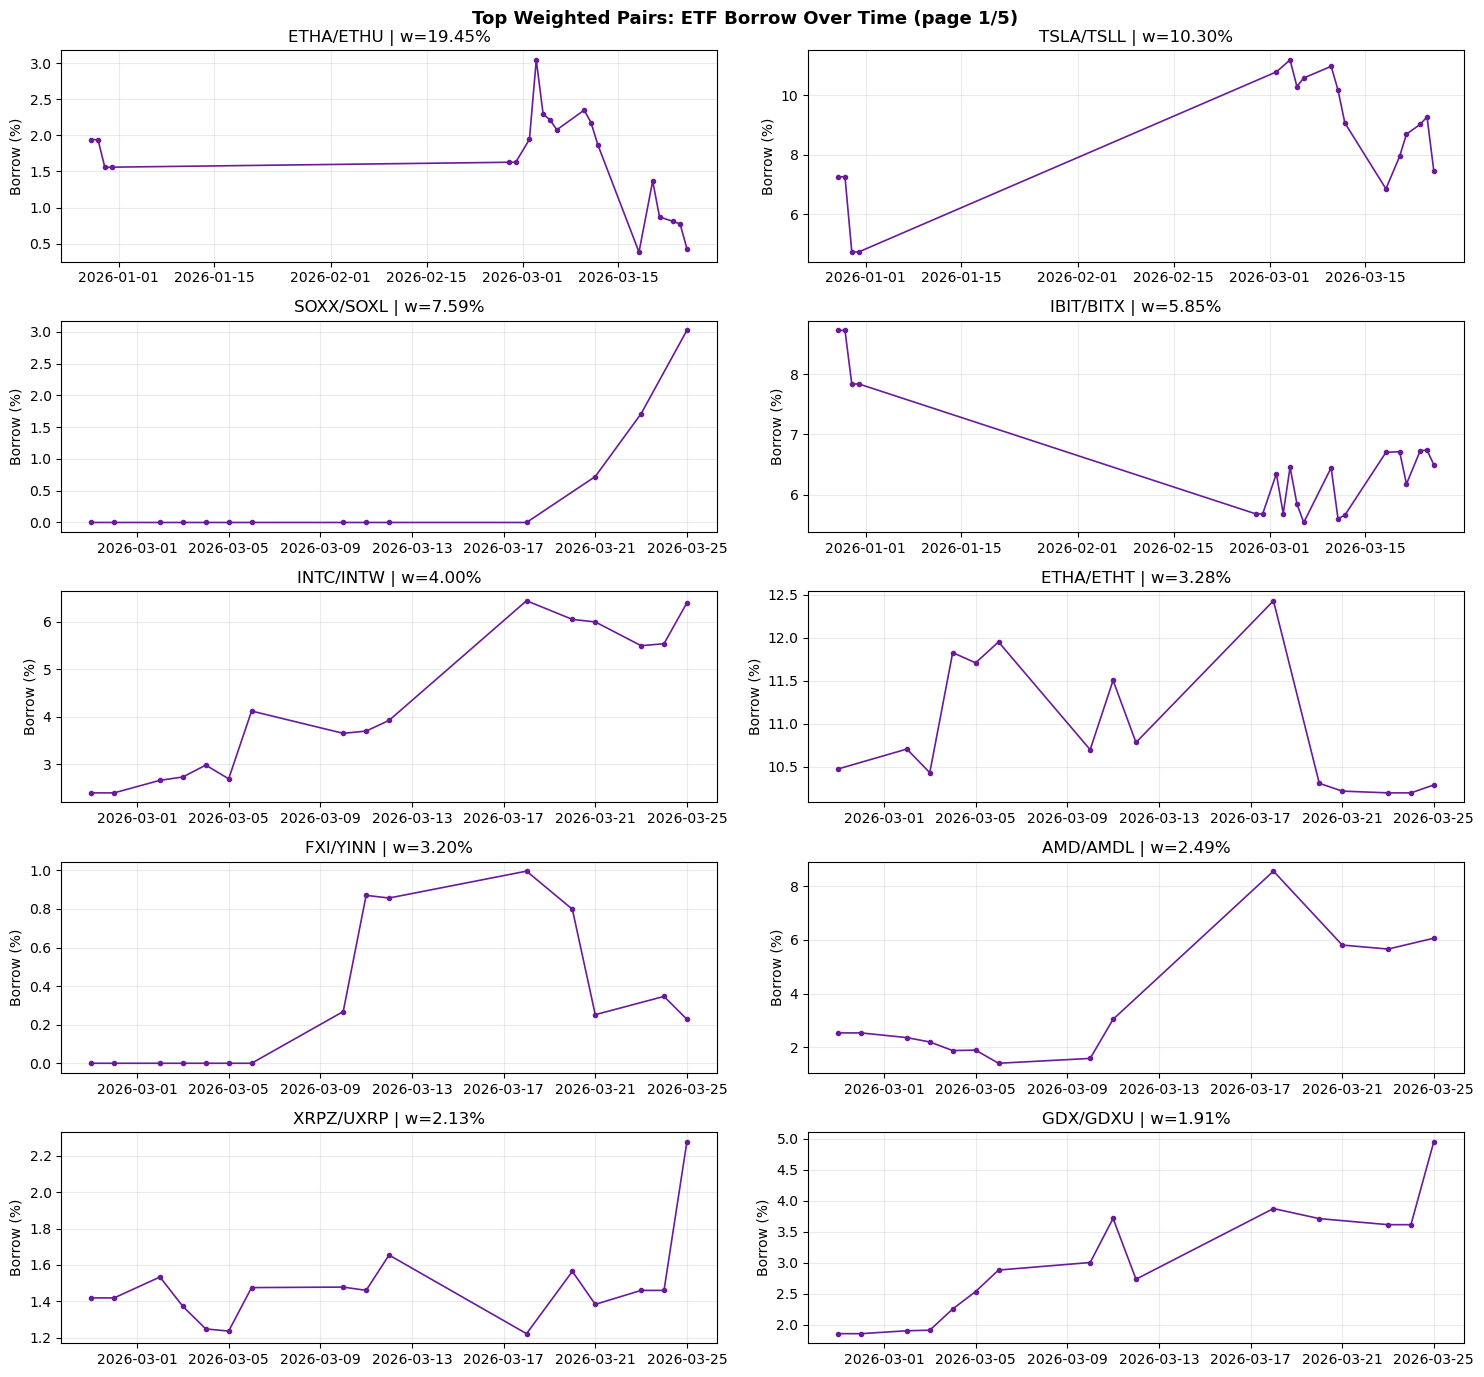

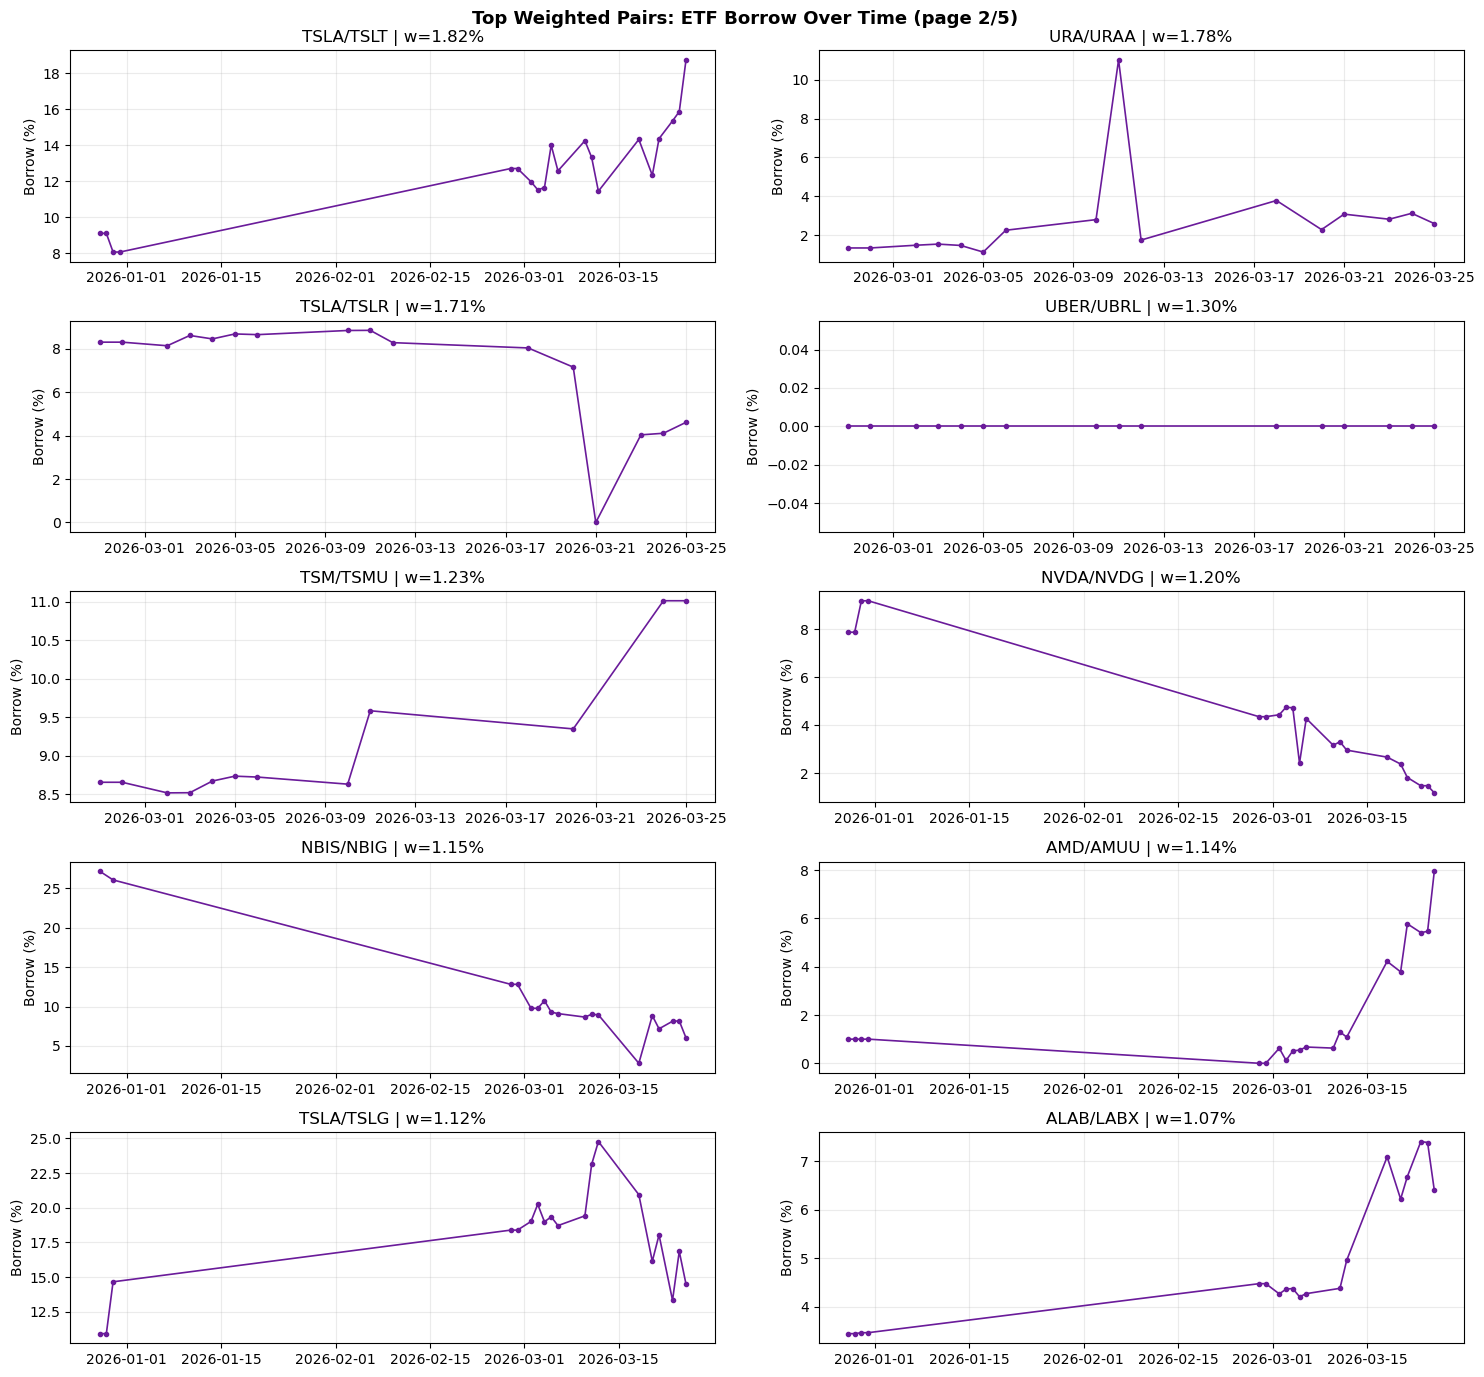

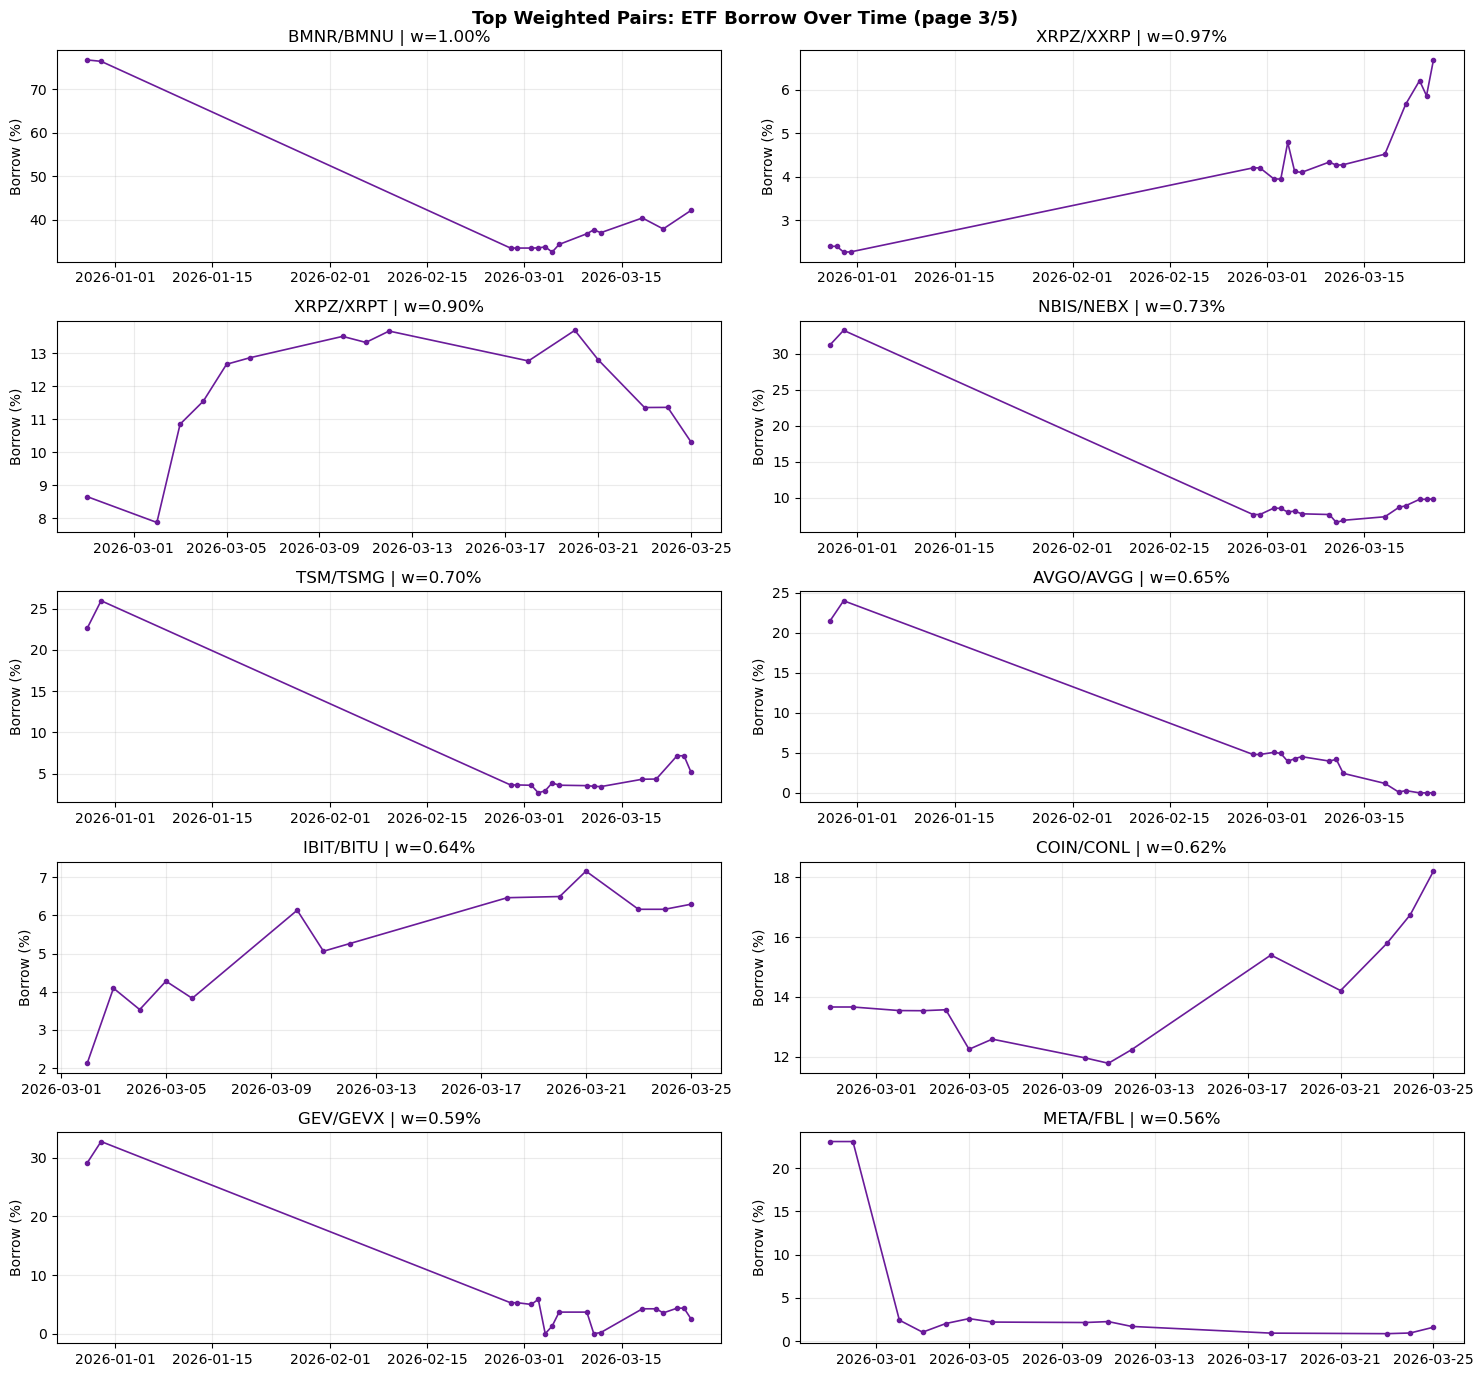

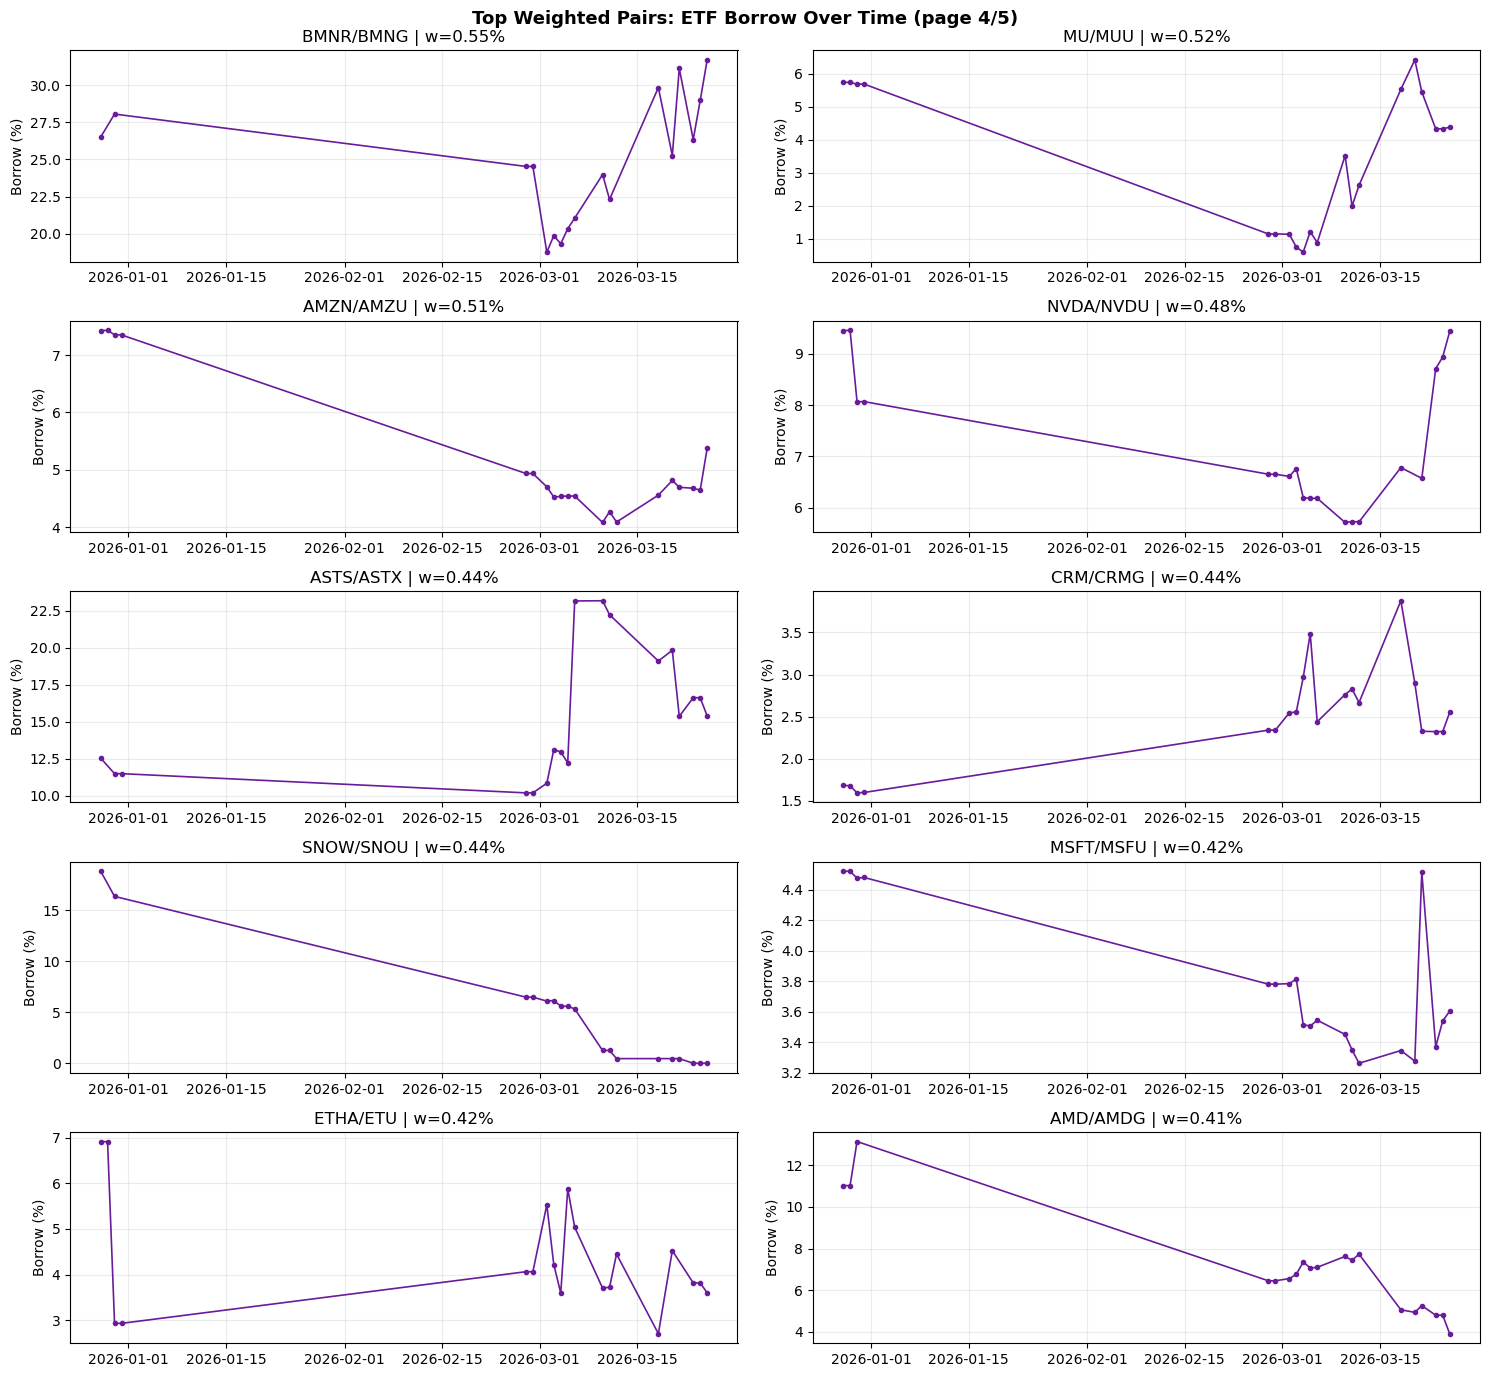

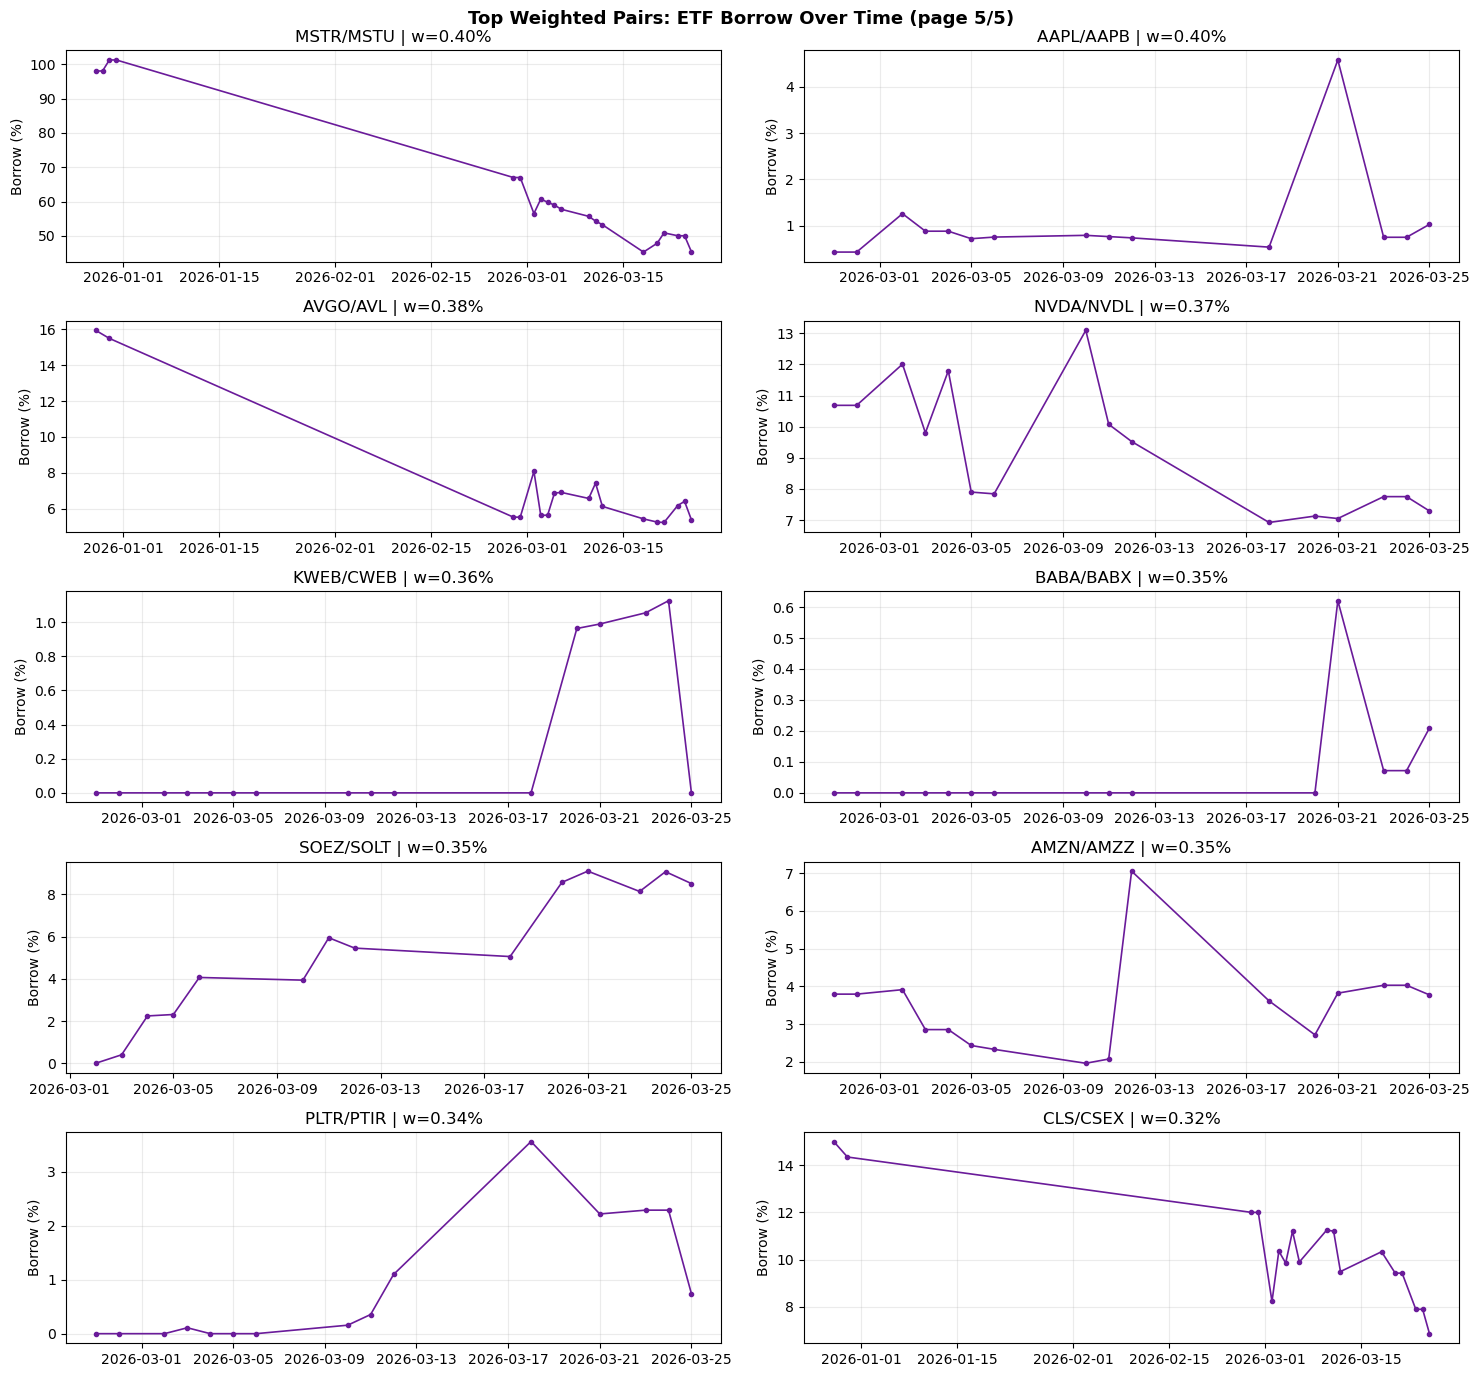

In [ ]:
# Legacy borrow-timeseries diagnostic removed.
raise RuntimeError("Legacy borrow-timeseries cell removed. Use consolidated diagnostics cells.")

import math
from pathlib import Path
import matplotlib.pyplot as plt

# 1) Load latest weighting file (optimized first).
weights_candidates = [
    Path("data/backtest/v9_optimized_grid_best_weights.csv"),
    Path("data/backtest/v9_optimal_pnl_decay_borrow_weights.csv"),
    Path("data/backtest/v8_pnl_decay_shares_weights.csv"),
    Path("notebooks/data/backtest/v9_optimized_grid_best_weights.csv"),
    Path("notebooks/data/backtest/v9_optimal_pnl_decay_borrow_weights.csv"),
    Path("notebooks/data/backtest/v8_pnl_decay_shares_weights.csv"),
]
weights_path = next((p for p in weights_candidates if p.exists()), None)
if weights_path is None:
    raise FileNotFoundError("No weighting file found. Run the weighting/optimization cell first.")

w = pd.read_csv(weights_path)
for c in ["etf", "und", "weight"]:
    if c not in w.columns:
        raise KeyError(f"Weights file missing required column: {c}")
w["etf"] = w["etf"].astype(str).str.upper().str.strip()
w["und"] = w["und"].astype(str).str.upper().str.strip()
w["weight"] = pd.to_numeric(w["weight"], errors="coerce").fillna(0.0)
w = w[w["etf"].ne("") & (w["weight"] > 0)].copy()
if w.empty:
    raise RuntimeError("No positive-weight pairs found in weights file.")

# Optional: restrict to active backtest universe if available.
if "UNIVERSE" in globals() and len(UNIVERSE) > 0:
    active_etfs = {e for e, _, _ in UNIVERSE}
    w = w[w["etf"].isin(active_etfs)].copy()

w = w.sort_values("weight", ascending=False).drop_duplicates(subset=["etf"], keep="first")
top_n = min(50, len(w))
top_w = w.head(top_n).copy()
top_w["pair"] = top_w["und"] + "/" + top_w["etf"]

# 2) Build borrow history from all run snapshots.
runs_candidates = [
    Path("data/runs"),
    Path("../data/runs"),
    Path.cwd() / "data/runs",
    Path.cwd() / "../data/runs",
    Path.cwd().parent / "data/runs",
]
runs_root = next((p.resolve() for p in runs_candidates if p.exists()), None)
if runs_root is None:
    raise FileNotFoundError("Could not locate data/runs for borrow history.")

snapshot_files = []
for d in sorted(runs_root.glob("*")):
    if not d.is_dir():
        continue
    f_screen = d / "etf_screened_today.csv"
    f_trades = d / "proposed_trades.csv"
    if f_screen.exists():
        snapshot_files.append((d.name, f_screen))
    elif f_trades.exists():
        snapshot_files.append((d.name, f_trades))

# Include current screener snapshot (date from file modified time) for most recent point.
for p in [Path("data/etf_screened_today.csv"), Path("../data/etf_screened_today.csv")]:
    if p.exists():
        dt = pd.to_datetime(p.stat().st_mtime, unit="s", errors="coerce").strftime("%Y-%m-%d")
        snapshot_files.append((dt, p))
        break

if not snapshot_files:
    raise FileNotFoundError(f"No screener snapshots found under {runs_root}")

borrow_col_priority = ["borrow_net_annual", "borrow_current", "borrow_fee_annual"]
rows = []
for date_str, fp in snapshot_files:
    try:
        d = pd.read_csv(fp)
    except Exception:
        continue
    if "ETF" not in d.columns:
        continue
    col = next((c for c in borrow_col_priority if c in d.columns), None)
    if col is None:
        continue

    tmp = d[["ETF", col]].copy()
    tmp["ETF"] = tmp["ETF"].astype(str).str.upper().str.strip()
    tmp["borrow_rate"] = pd.to_numeric(tmp[col], errors="coerce")
    tmp = tmp[tmp["ETF"].ne("") & tmp["borrow_rate"].notna()]
    tmp = tmp[np.isfinite(tmp["borrow_rate"])].copy()
    tmp["run_date"] = pd.to_datetime(date_str, errors="coerce")
    tmp = tmp[tmp["run_date"].notna()].copy()
    rows.append(tmp[["run_date", "ETF", "borrow_rate"]])

if not rows:
    raise RuntimeError("No usable borrow history rows found.")

borrow_hist = pd.concat(rows, ignore_index=True)
borrow_hist = (
    borrow_hist.groupby(["run_date", "ETF"], as_index=False)["borrow_rate"]
    .mean()
    .sort_values(["ETF", "run_date"])
)

print(
    f"Using weights: {weights_path.name} | top pairs plotted: {top_n} | "
    f"borrow snapshots: {borrow_hist['run_date'].nunique()} dates"
)

# 3) Plot top 50 pair borrow series in pages of 10 charts.
plots_per_page = 10
n_pages = math.ceil(top_n / plots_per_page)

for page in range(n_pages):
    start = page * plots_per_page
    end = min(top_n, start + plots_per_page)
    chunk = top_w.iloc[start:end].copy()

    n_sub = len(chunk)
    ncols = 2
    nrows = math.ceil(n_sub / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(15, max(6, 2.8 * nrows)), sharex=False)
    axes = np.array(axes).reshape(-1)

    for ax_i, (_, r) in enumerate(chunk.iterrows()):
        ax = axes[ax_i]
        etf = r["etf"]
        pair = r["pair"]
        w_pct = 100 * float(r["weight"])

        s = borrow_hist[borrow_hist["ETF"] == etf]
        if s.empty:
            ax.text(0.5, 0.5, f"No history for {pair}", ha="center", va="center", transform=ax.transAxes)
            ax.set_title(f"{pair} | w={w_pct:.2f}%")
            ax.grid(alpha=0.2)
            continue

        ax.plot(s["run_date"], 100 * s["borrow_rate"], color="#6A1B9A", marker="o", ms=3, lw=1.2)
        ax.set_title(f"{pair} | w={w_pct:.2f}%")
        ax.set_ylabel("Borrow (%)")
        ax.grid(alpha=0.25)

    for k in range(n_sub, len(axes)):
        axes[k].axis("off")

    fig.suptitle(
        f"Top Weighted Pairs: ETF Borrow Over Time (page {page+1}/{n_pages})",
        fontsize=13,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()


In [ ]:
# ---- Explainable predictive optimizer (forecast alpha + borrow, with hard exposure caps) ----
from pathlib import Path
import numpy as np
import pandas as pd

if "UNIVERSE" not in globals() or len(UNIVERSE) == 0:
    raise RuntimeError("Run universe setup first (UNIVERSE missing).")
if "PRICES" not in globals() or "SPY" not in PRICES:
    raise RuntimeError("Run price-loading cells first (PRICES/SPY missing).")

TRADING_DAYS = int(globals().get("TRADING_DAYS", 252))

# Runtime knobs (keep simple and explainable).
RIDGE_ALPHA = 12.0          # larger = more coefficient shrinkage
TRAIN_DAYS = 504            # ~2y pooled daily cross-sectional fit
LAMBDA_BORROW = 0.70        # explicit borrow penalty
TURNOVER_BLEND = 0.20       # blend toward prior weights for stability
PAIR_WEIGHT_LIMIT = 0.10    # hard cap: 10% per levered ETF pair
UNDERLYING_LIMIT = 0.20     # hard cap: 20% aggregate per underlying


def _norm_pos_local(s: pd.Series, p: float = 1.0) -> pd.Series:
    v = np.maximum(0.0, pd.to_numeric(s, errors="coerce").fillna(0.0).values) ** float(p)
    out = pd.Series(v, index=s.index, dtype=float)
    if out.sum() <= 0:
        out[:] = 1.0
    return out / out.sum()


def _project_local(desired: pd.Series, caps_: pd.Series, tol: float = 1e-12) -> pd.Series:
    desired = desired.astype(float).copy()
    caps_ = caps_.astype(float).copy().clip(lower=0.0)
    desired = desired / desired.sum() if desired.sum() > 0 else pd.Series(1.0 / len(desired), index=desired.index)
    if caps_.sum() < 1.0:
        caps_ = np.maximum(caps_, desired)

    w = pd.Series(0.0, index=desired.index)
    free = list(desired.index)
    rem = 1.0
    while free and rem > tol:
        base_ = desired.loc[free]
        trial = pd.Series(rem / len(free), index=free) if base_.sum() <= 0 else rem * base_ / base_.sum()
        hit = trial > (caps_.loc[free] + tol)
        if not hit.any():
            w.loc[free] = trial
            rem = 0.0
            break
        hit_idx = list(trial.index[hit])
        w.loc[hit_idx] = caps_.loc[hit_idx]
        rem = 1.0 - float(w.sum())
        free = [k for k in free if k not in hit_idx]

    if rem > tol and free:
        room = (caps_.loc[free] - w.loc[free]).clip(lower=0.0)
        if room.sum() > tol:
            w.loc[free] += rem * room / room.sum()

    w = w.clip(lower=0.0)
    return w / w.sum() if w.sum() > 0 else pd.Series(1.0 / len(w), index=w.index)


# Base feature table.
if "w_df" in globals() and isinstance(w_df, pd.DataFrame) and not w_df.empty:
    base = w_df.copy()
else:
    w_candidates = [
        Path("data/backtest/v9_walkforward_best_weights.csv"),
        Path("data/backtest/v9_optimal_pnl_decay_borrow_weights.csv"),
        Path("data/backtest/v8_pnl_decay_shares_weights.csv"),
        Path("notebooks/data/backtest/v9_walkforward_best_weights.csv"),
        Path("notebooks/data/backtest/v9_optimal_pnl_decay_borrow_weights.csv"),
        Path("notebooks/data/backtest/v8_pnl_decay_shares_weights.csv"),
    ]
    w_path = next((p for p in w_candidates if p.exists()), None)
    if w_path is None:
        raise FileNotFoundError("No base weights/features file found.")
    base = pd.read_csv(w_path)

need_cols = {"etf", "und", "decay_value", "borrow_for_weight"}
miss = need_cols - set(base.columns)
if miss:
    raise RuntimeError(f"Missing required columns in base table: {miss}")

base["etf"] = base["etf"].astype(str).str.upper().str.strip()
base["und"] = base["und"].astype(str).str.upper().str.strip()
base = base.drop_duplicates(subset=["etf"], keep="first")

for c in ["decay_value", "borrow_for_weight", "weight_cap", "weight", "aum_usd", "aum_m", "shares_available_for_cap", "shares_available"]:
    if c in base.columns:
        base[c] = pd.to_numeric(base[c], errors="coerce")

u_map = {e: (u, abs(float(b))) for e, u, b in UNIVERSE}
base = base[base["etf"].isin(u_map.keys())].copy().reset_index(drop=True)
if base.empty:
    raise RuntimeError("No overlap between base table and UNIVERSE.")

max_cap = min(float(globals().get("CFG", {}).get("max_pair_weight_cap", 0.20)), PAIR_WEIGHT_LIMIT)
short_avail_use_pct = float(globals().get("CFG", {}).get("short_avail_use_pct", 0.25))
missing_shares_cap = float(globals().get("CFG", {}).get("missing_shares_cap", 0.03))

# Start from any existing weight_cap (often already shares-based from earlier cells).
if "weight_cap" not in base.columns:
    base["weight_cap"] = max_cap
base["weight_cap"] = base["weight_cap"].fillna(max_cap).clip(lower=0.0)

# Explicitly recompute shares-based caps when shares availability is present.
# cap ~= (allowed short dollars from shares) / (short dollars consumed by a full pair weight).
if "shares_available_for_cap" in base.columns:
    cap_vals = {}

    ref_date = PRICES["SPY"].index[-1]
    if "EW_BT" in globals() and isinstance(EW_BT, dict) and len(EW_BT) > 0:
        try:
            ref_lev = max(EW_BT)
            ref_date = EW_BT[ref_lev].index[-1]
            ref_tgt_gross = float(EW_BT[ref_lev]["tgt_gross_nav"].iloc[-1])
        except Exception:
            capital_usd = float(globals().get("CFG", {}).get("capital_usd", 10_000_000))
            fallback_lev = float(globals().get("V7_TARGET_LEV_END", 4.5))
            ref_tgt_gross = capital_usd * fallback_lev
    else:
        capital_usd = float(globals().get("CFG", {}).get("capital_usd", 10_000_000))
        fallback_lev = float(globals().get("V7_TARGET_LEV_END", 4.5))
        ref_tgt_gross = capital_usd * fallback_lev

    for etf in base["etf"].tolist():
        babs = max(1e-9, float(u_map.get(etf, (None, 2.0))[1]))
        hr = 1.0 / babs
        short_frac = hr / (1.0 + hr)

        px_ser = PRICES.get(etf)
        px_e = float(px_ser.asof(ref_date)) if px_ser is not None else np.nan
        sh_av = pd.to_numeric(base.loc[base["etf"] == etf, "shares_available_for_cap"], errors="coerce").iloc[0]

        if pd.isna(sh_av) or sh_av <= 0 or pd.isna(px_e) or px_e <= 0:
            cap = missing_shares_cap
        else:
            cap_shares = float(sh_av) * short_avail_use_pct
            cap = (cap_shares * px_e) / max(1.0, ref_tgt_gross * short_frac)

        cap_vals[etf] = min(max_cap, max(0.0, float(cap)))

    cap_from_shares = pd.Series(cap_vals)
    cap_from_weight_col = pd.Series(base["weight_cap"].values, index=base["etf"].values)
    # Conservative: enforce the tighter of existing cap and recalculated shares cap.
    caps = pd.concat([cap_from_weight_col, cap_from_shares], axis=1).min(axis=1)
else:
    caps = pd.Series(base["weight_cap"].values, index=base["etf"].values)

caps = caps.clip(lower=0.0)

# Optional net-AUM realism cap (use only a small fraction of ETF net assets).
aum_use_pct = float(globals().get("CFG", {}).get("aum_use_pct", 0.03))
if "aum_usd" in base.columns or "aum_m" in base.columns:
    if "aum_usd" in base.columns:
        aum_usd_s = pd.to_numeric(base["aum_usd"], errors="coerce")
    else:
        aum_usd_s = pd.to_numeric(base.get("aum_m"), errors="coerce") * 1e6

    if "ref_tgt_gross" not in locals():
        capital_usd = float(globals().get("CFG", {}).get("capital_usd", 10_000_000))
        fallback_lev = float(globals().get("V7_TARGET_LEV_END", 4.5))
        ref_tgt_gross = capital_usd * fallback_lev

    aum_cap = (aum_use_pct * aum_usd_s.values) / max(1.0, float(ref_tgt_gross))
    aum_cap = pd.Series(aum_cap, index=base["etf"].values).replace([np.inf, -np.inf], np.nan)
    aum_cap = aum_cap.fillna(max_cap).clip(lower=0.0, upper=max_cap)
    caps = pd.concat([caps, aum_cap], axis=1).min(axis=1)

if caps.sum() < 1.0:
    caps += (1.0 - caps.sum()) / len(caps)

# Build pair return panel (net of borrow using average borrow proxy).
start = pd.to_datetime(globals().get("start_ts", "2024-12-01"))
spy_idx = PRICES["SPY"].index
if getattr(spy_idx, "tz", None) is not None and start.tzinfo is None:
    start = start.tz_localize(spy_idx.tz)
idx = spy_idx[spy_idx >= start]

pair_ret = pd.DataFrame(index=idx)
for etf in base["etf"].tolist():
    und, babs = u_map[etf]
    se = PRICES.get(etf)
    su = PRICES.get(und)
    if se is None or su is None:
        continue

    re = se.reindex(idx).ffill().pct_change().fillna(0.0)
    ru = su.reindex(idx).ffill().pct_change().fillna(0.0)

    hr = 1.0 / max(1e-9, babs)
    short_frac = hr / (1.0 + hr)
    long_frac = 1.0 - short_frac

    b_avg = pd.to_numeric(base.loc[base["etf"] == etf, "borrow_for_weight"], errors="coerce").iloc[0]
    if pd.isna(b_avg):
        b_avg = float(globals().get("CFG", {}).get("fallback_borrow_rate", 0.02))
    b_daily = float(b_avg) / TRADING_DAYS

    gross_ret = long_frac * ru - short_frac * re
    net_ret = gross_ret - short_frac * b_daily
    pair_ret[etf] = net_ret.values

usable = [e for e in base["etf"] if e in pair_ret.columns]
base = base[base["etf"].isin(usable)].copy().reset_index(drop=True)
pair_ret = pair_ret[usable].fillna(0.0)
if pair_ret.shape[1] < 20:
    raise RuntimeError("Too few usable pairs for explainable optimizer.")

etfs = list(pair_ret.columns)
rets = pair_ret[etfs].copy()

# Explainable feature set (all available at time t, predicting t+1 net return).
mom20 = rets.rolling(20).mean().shift(1) * TRADING_DAYS
vol20 = rets.rolling(20).std().shift(1) * np.sqrt(TRADING_DAYS)
rev5 = (-rets.rolling(5).mean().shift(1)) * TRADING_DAYS
cs_mean = rets.mean(axis=1)
resid20 = (rets.sub(cs_mean, axis=0)).rolling(20).mean().shift(1) * TRADING_DAYS

decay_s = pd.Series(base["decay_value"].values, index=base["etf"].values).reindex(etfs).fillna(0.0)
borrow_s = pd.Series(base["borrow_for_weight"].values, index=base["etf"].values).reindex(etfs).fillna(0.0)

target = rets.shift(-1) * TRADING_DAYS

feat_frames = {
    "mom20": mom20,
    "vol20": vol20,
    "rev5": rev5,
    "resid20": resid20,
}

# Build pooled train sample over last TRAIN_DAYS.
train_idx = rets.index[-(TRAIN_DAYS + 40):-1] if len(rets.index) > (TRAIN_DAYS + 60) else rets.index[40:-1]
if len(train_idx) < 120:
    raise RuntimeError("Insufficient train history for explainable optimizer.")

X_parts = []
for name, fr in feat_frames.items():
    X_parts.append(fr.reindex(train_idx)[etfs].values.reshape(-1))
X_parts.append(np.tile(decay_s.reindex(etfs).values, len(train_idx)))
X_parts.append(np.tile(borrow_s.reindex(etfs).values, len(train_idx)))

feature_names = ["mom20", "vol20", "rev5", "resid20", "decay", "borrow"]
X_raw = np.column_stack(X_parts)
y_raw = target.reindex(train_idx)[etfs].values.reshape(-1)

mask = np.isfinite(y_raw)
for j in range(X_raw.shape[1]):
    mask &= np.isfinite(X_raw[:, j])

X = X_raw[mask]
y = y_raw[mask]
if len(y) < 2000:
    raise RuntimeError("Too few valid observations to fit predictive model.")

# Ridge fit with z-scored features for interpretable coefficient table.
x_mu = X.mean(axis=0)
x_sd = X.std(axis=0)
x_sd = np.where(x_sd < 1e-9, 1.0, x_sd)
Xs = (X - x_mu) / x_sd
y_mu = float(y.mean())
yc = y - y_mu

I = np.eye(Xs.shape[1])
beta_z = np.linalg.solve(Xs.T @ Xs + RIDGE_ALPHA * I, Xs.T @ yc)
beta = beta_z / x_sd
intercept = y_mu - float(x_mu @ beta)

coef_tbl = pd.DataFrame({
    "feature": feature_names,
    "coef": beta,
    "coef_abs": np.abs(beta),
}).sort_values("coef_abs", ascending=False)

# Predict latest cross-section.
asof_date = rets.index[-2] if len(rets.index) >= 2 else rets.index[-1]
X_last = pd.DataFrame(index=etfs)
for name, fr in feat_frames.items():
    X_last[name] = fr.loc[asof_date, etfs].astype(float)
X_last["decay"] = decay_s.reindex(etfs).astype(float)
X_last["borrow"] = borrow_s.reindex(etfs).astype(float)
X_last = X_last.replace([np.inf, -np.inf], np.nan).fillna(0.0)

mu_hat = intercept + X_last[feature_names].values @ beta
mu_hat = pd.Series(mu_hat, index=etfs, dtype=float)

# Explicit borrow overlay term in optimizer score.
borrow_proxy = borrow_s.reindex(etfs).fillna(borrow_s.median())

alpha_term = mu_hat
borrow_term = -LAMBDA_BORROW * borrow_proxy
score = alpha_term + borrow_term
signal = _norm_pos_local(score.clip(lower=0.0), p=1.25)

# Turnover-aware stabilization toward previous weights if available.
if "weight" in base.columns and base["weight"].notna().sum() > 0:
    w_prev = pd.Series(base["weight"].values, index=base["etf"].values).reindex(etfs).fillna(0.0).clip(lower=0.0)
    w_prev = w_prev / w_prev.sum() if w_prev.sum() > 0 else pd.Series(1.0 / len(etfs), index=etfs)
else:
    w_prev = pd.Series(1.0 / len(etfs), index=etfs)

w_raw = (1.0 - TURNOVER_BLEND) * signal + TURNOVER_BLEND * w_prev
w_raw = w_raw / w_raw.sum() if w_raw.sum() > 0 else pd.Series(1.0 / len(etfs), index=etfs)
w_final = _project_local(w_raw, caps.reindex(etfs).fillna(max_cap))

# Enforce aggregate underlying cap (20%) after pair caps.
und_by_etf = pd.Series(base.set_index("etf").reindex(etfs)["und"].astype(str).values, index=etfs)
for _ in range(12):
    und_exp = w_final.groupby(und_by_etf).sum()
    viol = und_exp[und_exp > (UNDERLYING_LIMIT + 1e-12)]
    if viol.empty:
        break

    # Scale violating underlying buckets down to the limit.
    for und, exp in viol.items():
        names = und_by_etf.index[und_by_etf == und]
        if exp > 0:
            w_final.loc[names] *= float(UNDERLYING_LIMIT / exp)

    # Freeze violating buckets at scaled values and re-project remaining mass.
    caps_iter = caps.reindex(etfs).fillna(max_cap).copy()
    for und in viol.index:
        names = und_by_etf.index[und_by_etf == und]
        caps_iter.loc[names] = np.minimum(caps_iter.loc[names].values, w_final.loc[names].values)
    w_final = _project_local(w_final, caps_iter)

# Attribution output.
out_df = base.set_index("etf").reindex(etfs).copy()
out_df["weight"] = w_final.reindex(etfs).values
out_df["mu_hat"] = mu_hat.reindex(etfs).values
out_df["borrow_proxy"] = borrow_proxy.reindex(etfs).values
out_df["alpha_term"] = alpha_term.reindex(etfs).values
out_df["borrow_term"] = borrow_term.reindex(etfs).values
out_df["raw_score"] = score.reindex(etfs).values
out_df["weight_cap"] = caps.reindex(etfs).values
out_df["cap_binding"] = (out_df["weight"] >= out_df["weight_cap"] - 1e-9)
out_df["underlying_weight"] = out_df.groupby("und")["weight"].transform("sum")
out_df["underlying_cap_binding"] = out_df["underlying_weight"] >= (UNDERLYING_LIMIT - 1e-9)
out_df = out_df.reset_index().rename(columns={"index": "etf"})
out_df = out_df.sort_values("weight", ascending=False).reset_index(drop=True)

out = Path("data/backtest")
out.mkdir(parents=True, exist_ok=True)
out_file = out / "v9_explainable_predictive_weights.csv"
out_df.to_csv(out_file, index=False)

print(f"Saved explainable predictive weights: {out_file}")
print(f"As-of date: {asof_date.date() if hasattr(asof_date, 'date') else asof_date}")
print(f"Train observations: {len(y):,}; universe size: {len(etfs)}")
print(f"Hard caps applied: pair <= {PAIR_WEIGHT_LIMIT:.0%}, underlying <= {UNDERLYING_LIMIT:.0%}")
print(f"Max pair weight: {out_df['weight'].max():.2%}; max underlying weight: {out_df['underlying_weight'].max():.2%}")
print("Top feature coefficients (ridge):")
display(coef_tbl[["feature", "coef"]])

show_cols = [
    "etf", "und", "weight", "mu_hat", "borrow_proxy",
    "alpha_term", "borrow_term", "raw_score", "weight_cap", "cap_binding", "underlying_weight", "underlying_cap_binding"
]
display(out_df[show_cols].head(40))

# Optional: make this the in-memory weights table for downstream weighted run.
w_df = out_df.copy()


Saved explainable predictive weights: data\backtest\v9_explainable_predictive_weights.csv
As-of date: 2026-03-27
Train observations: 68,880; universe size: 246
Top feature coefficients (ridge):


,feature,coef
3,resid20,-0.585498
4,decay,0.571736
1,vol20,0.395831
0,mom20,0.394656
5,borrow,0.125586
2,rev5,-0.095607


,etf,und,weight,mu_hat,risk_proxy,borrow_proxy,alpha_term,risk_term,borrow_term,raw_score,weight_cap,cap_binding
0,ETHU,ETHA,0.073977,0.208117,0.009369,0.015932,0.208117,-0.004216,-0.011153,0.192749,0.196029,False
1,CRWG,CRWV,0.058230,0.368459,0.014855,0.115927,0.368459,-0.006685,-0.081149,0.280626,0.104597,False
2,CRCG,CRCL,0.053134,0.377697,0.015361,0.159496,0.377697,-0.006913,-0.111647,0.259137,0.072355,False
3,CWVX,CRWV,0.049808,0.346636,0.015134,0.061165,0.346636,-0.006810,-0.042816,0.297010,0.049808,True
4,TSLL,TSLA,0.038020,0.013340,0.009208,0.087235,0.013340,-0.004144,-0.061064,-0.051868,0.200000,False
5,LABX,ALAB,0.036138,0.256297,0.017921,0.049638,0.256297,-0.008065,-0.034746,0.213486,0.036138,True
6,NEBX,NBIS,0.034276,0.343192,0.015632,0.085275,0.343192,-0.007035,-0.059693,0.276464,0.034276,True
7,GDXU,GDX,0.028830,0.158932,0.017854,0.029801,0.158932,-0.008034,-0.020861,0.130037,0.137101,False
8,ETHT,ETHA,0.027977,0.157473,0.009647,0.107677,0.157473,-0.004341,-0.075374,0.077757,0.032750,False
9,SOXL,SOXX,0.026744,0.065897,0.006746,0.002211,0.065897,-0.003036,-0.001548,0.061313,0.200000,False


In [ ]:
weights_candidates = [
    Path("data/backtest/v9_explainable_predictive_weights.csv"),
    Path("notebooks/data/backtest/v9_explainable_predictive_weights.csv"),
]
weights_path = next((p for p in weights_candidates if p.exists()), None)
if weights_path is None:
    raise FileNotFoundError("No weights CSV found. Run the weight-construction cell first.")

_w_csv = pd.read_csv(weights_path)
_w_csv["etf"] = _w_csv["etf"].astype(str).str.upper().str.strip()
_active_etfs = {e for e, _, _ in UNIVERSE}
_w_csv = _w_csv[_w_csv["etf"].isin(_active_etfs)].copy()
PAIR_WEIGHTS = dict(zip(_w_csv["etf"], _w_csv["weight"]))
if not PAIR_WEIGHTS:
    raise RuntimeError("Loaded weights are empty after UNIVERSE beta filtering. Re-run weight-construction cell.")

# Optional cap-ramp support: increase allowed cap over the next N rebalances.
CAP_RAMP_REBALS = int(CFG.get("cap_ramp_rebals", 3))
max_pair_weight_cap = float(CFG.get("max_pair_weight_cap", 0.20))
if {"etf", "weight", "weight_raw"}.issubset(_w_csv.columns):
    _wtmp = _w_csv.copy()
    _wtmp["etf"] = _wtmp["etf"].astype(str).str.upper()
    PAIR_WEIGHT_BASE = dict(zip(_wtmp["etf"], _wtmp["weight"]))
    PAIR_WEIGHT_MAX = dict(zip(_wtmp["etf"], np.minimum(_wtmp["weight_raw"], max_pair_weight_cap)))
else:
    PAIR_WEIGHT_BASE = dict(PAIR_WEIGHTS)
    PAIR_WEIGHT_MAX = dict(PAIR_WEIGHTS)

print(f"Loaded Diamond Creek weights from {weights_path.name}: {len(PAIR_WEIGHTS)} pairs")
print(f"  Top weight: {max(PAIR_WEIGHTS.values()):.2%} | Bottom: {min(v for v in PAIR_WEIGHTS.values() if v > 0):.2%}")
print(f"  Top 5 concentration: {sum(sorted(PAIR_WEIGHTS.values(), reverse=True)[:5]):.1%}")
print(f"  Top 10 concentration: {sum(sorted(PAIR_WEIGHTS.values(), reverse=True)[:10]):.1%}")
print(f"  Cap ramp rebalances: {CAP_RAMP_REBALS}")
_top5 = sorted(PAIR_WEIGHTS.items(), key=lambda x: x[1], reverse=True)[:5]
for _etf, _w in _top5:
    print(f"    {_etf:>6s}: {_w:.2%}")
print()
print("=" * 60)
print("  v8 — Diamond Creek Fund weighted run (same engine; PAIR_WEIGHTS from CSV)")
print("=" * 60)

spy = PRICES.get("SPY")
tdays = spy.index[spy.index >= start_ts].sort_values()

s = pd.Series(range(len(tdays)), index=tdays)
rebal_idx = s.resample("W-FRI").last().dropna()
rebal_days = set(tdays[int(i)] for i in rebal_idx.values)

n_pairs = len(UNIVERSE)
INC_ETFS = frozenset(
    etf for etf, und, bv in UNIVERSE if INCEPTION[(etf, und)] <= start_ts
)
POST_ETFS = frozenset(
    etf for etf, und, bv in UNIVERSE if INCEPTION[(etf, und)] > start_ts
)

print(f"Trading days: {len(tdays)} | Rebalance days: {len(rebal_days)} (weekly)")
print(f"Pairs: {n_pairs} | Incumbents (≤ start): {len(INC_ETFS)} | Post-start: {len(POST_ETFS)}")
print(f"Start: {tdays[0].strftime('%Y-%m-%d')} | End: {tdays[-1].strftime('%Y-%m-%d')}")
print(
    f"v8 target gross multiple: {V7_TARGET_LEV_START}x → {V7_TARGET_LEV_END}x "
    f"as post-start pairs join (v5-style incumbent hedging + dead-band gross control)"
)

if "PAIR_WEIGHTS" not in dir():
    PAIR_WEIGHTS = {e: 1.0 / n_pairs for e, _, _ in UNIVERSE}
    print(f"Using equal weights: {1.0/n_pairs:.4%} per pair")
else:
    print(f"Using custom PAIR_WEIGHTS ({len(PAIR_WEIGHTS)} pairs, top weight: {max(PAIR_WEIGHTS.values()):.2%})")

ALL_BT = {}
ALL_PAIR_PNL = {}
ALL_PAIR_NET = {}
ALL_PAIR_GROSS = {}

for gross_lev in LEVERAGE_RUNS:
    print(f"\n{'='*60}")
    print(
        f"  v7 RUN (store key {gross_lev}x) | dynamic tgt gross {V7_TARGET_LEV_START}x–{V7_TARGET_LEV_END}x"
    )
    print(f"{'='*60}")

    cash = float(CFG["capital_usd"])
    holdings = {}
    pair_pos = {}
    pair_pnl = {}
    daily_rows = []
    tot_costs = tot_borrow = tot_margin_debit = tot_margin_credit = 0.0
    rebal_count = 0
    pair_entry_rebal: dict[tuple[str, str], int] = {}
    pair_cap_entry_rebal: dict[str, int] = {}
    prev_px = {}
    cum_long_pnl = cum_short_pnl = 0.0
    pair_net_rows = []
    pair_gross_rows = []

    def _execute_trade(sym, tgt_sh, px_map):
        global cash
        cur_sh = holdings.get(sym, 0)
        delta = tgt_sh - cur_sh
        p = px_map.get(sym, 0)
        trade_usd = abs(delta * p)
        if p <= 0 or trade_usd < 1:
            return 0.0, 0.0
        cash -= delta * p
        c = trade_cost(trade_usd, p, CFG)
        cash -= c
        if abs(tgt_sh) < 1:
            holdings.pop(sym, None)
        else:
            holdings[sym] = tgt_sh
        return trade_usd, c

    def _frac_rows_for_day(today, R: int):
        rows = []
        for etf, und, bv in UNIVERSE:
            key = (etf, und)
            if INCEPTION[key] > today:
                continue

            # Existing listing ramp-in from v7/v8 engine.
            if INCEPTION[key] <= start_ts:
                rp = 1.0
            else:
                if key not in pair_entry_rebal:
                    pair_entry_rebal[key] = R
                rp = min(1.0, (R - pair_entry_rebal[key] + 1) / float(RAMP_WEEKS))

            # New cap-ramp: for names that were cap-constrained, allow cap to increase
            # linearly over the next CAP_RAMP_REBALS rebalances toward max allowed weight.
            base_w = float(PAIR_WEIGHT_BASE.get(etf, PAIR_WEIGHTS.get(etf, 1.0 / n_pairs)))
            max_w = float(PAIR_WEIGHT_MAX.get(etf, base_w))
            if max_w > base_w + 1e-12:
                if etf not in pair_cap_entry_rebal:
                    pair_cap_entry_rebal[etf] = R
                cap_prog = min(1.0, (R - pair_cap_entry_rebal[etf] + 1) / float(max(1, CAP_RAMP_REBALS)))
                wb = base_w + (max_w - base_w) * cap_prog
            else:
                wb = base_w

            rows.append((etf, und, bv, wb * rp))
        return rows

    def _pair_gross_usd(ek, px_map):
        pos = pair_pos.get(ek)
        if not pos:
            return 0.0
        uk = pos["und"]
        return max(pos["long_sh"], 0) * px_map.get(
            uk, 0
        ) + max(-pos["short_sh"], 0) * px_map.get(ek, 0)

    def _target_lev_for_book(px_map):
        if not POST_ETFS:
            return float(V7_TARGET_LEV_START)
        on = sum(1 for ek in POST_ETFS if _pair_gross_usd(ek, px_map) > 1.0)
        prog = on / float(len(POST_ETFS))
        return V7_TARGET_LEV_START + (V7_TARGET_LEV_END - V7_TARGET_LEV_START) * prog

    def _apply_allocs(tgt_gross: float, frac_rows, px_map: dict) -> dict:
        tw = sum(r[3] for r in frac_rows)
        tgt_shares: dict = {}
        if tw <= 0:
            return tgt_shares
        for etf, und, bv, wcomb in frac_rows:
            frac = wcomb / tw
            alloc = tgt_gross * frac
            p_u, p_e = px_map.get(und, 0), px_map.get(etf, 0)
            if p_u <= 0 or p_e <= 0:
                continue
            babs = abs(bv)
            hr = 1.0 / babs
            long_usd = alloc / (1.0 + hr)
            short_usd = alloc - long_usd
            lsh = int(round(long_usd / p_u))
            ssh = -int(round(short_usd / p_e))
            pair_pos[etf] = {"und": und, "long_sh": lsh, "short_sh": ssh}
            if etf not in pair_pnl:
                pair_pnl[etf] = {"und": und, "long": 0.0, "short": 0.0}
            tgt_shares[und] = tgt_shares.get(und, 0) + lsh
            tgt_shares[etf] = tgt_shares.get(etf, 0) + ssh
        return tgt_shares

    def _apply_one_pair(
        tgt_shares: dict, etf, und, bv, alloc_usd: float, px_map: dict
    ) -> None:
        p_u, p_e = px_map.get(und, 0), px_map.get(etf, 0)
        if p_u <= 0 or p_e <= 0 or alloc_usd <= 0:
            return
        babs = abs(bv)
        hr = 1.0 / babs
        long_usd = alloc_usd / (1.0 + hr)
        short_usd = alloc_usd - long_usd
        lsh = int(round(long_usd / p_u))
        ssh = -int(round(short_usd / p_e))
        pair_pos[etf] = {"und": und, "long_sh": lsh, "short_sh": ssh}
        if etf not in pair_pnl:
            pair_pnl[etf] = {"und": und, "long": 0.0, "short": 0.0}
        tgt_shares[und] = tgt_shares.get(und, 0) + lsh
        tgt_shares[etf] = tgt_shares.get(etf, 0) + ssh

    for di, today in enumerate(tdays):
        px = {}
        for sym, ser in PRICES.items():
            if today in ser.index:
                px[sym] = float(ser.loc[today])
            else:
                prior = ser[ser.index <= today]
                if not prior.empty:
                    px[sym] = float(prior.iloc[-1])

        daily_long_pnl = daily_short_pnl = 0.0
        if di > 0 and prev_px:
            for ek, pos in pair_pos.items():
                uk = pos["und"]
                dp_u = px.get(uk, 0) - prev_px.get(uk, 0)
                dp_e = px.get(ek, 0) - prev_px.get(ek, 0)
                l_pnl = pos["long_sh"] * dp_u if pos["long_sh"] > 0 else 0.0
                s_pnl = pos["short_sh"] * dp_e if pos["short_sh"] < 0 else 0.0
                daily_long_pnl += l_pnl
                daily_short_pnl += s_pnl
                pair_pnl[ek]["long"] += l_pnl
                pair_pnl[ek]["short"] += s_pnl
        cum_long_pnl += daily_long_pnl
        cum_short_pnl += daily_short_pnl

        mtm = sum(sh * px.get(sym, 0) for sym, sh in holdings.items())
        nav = cash + mtm

        borrow_d = 0.0
        for sym, sh in holdings.items():
            if sh < 0:
                borrow_d += (
                    abs(sh)
                    * px.get(sym, 0)
                    * BORROW_MAP.get(sym, CFG["fallback_borrow_rate"])
                    / TRADING_DAYS
                )
        cash -= borrow_d
        tot_borrow += borrow_d

        ff = _get_fed_funds(today)
        l_notional = sum(
            sh * px.get(sym, 0) for sym, sh in holdings.items() if sh > 0
        )
        s_notional = sum(
            abs(sh) * px.get(sym, 0) for sym, sh in holdings.items() if sh < 0
        )

        long_financing = max(0.0, l_notional - CFG["capital_usd"])
        margin_debit_d = margin_debit_interest(
            long_financing, ff, CFG["margin_debit_spreads"]
        )
        cash -= margin_debit_d
        tot_margin_debit += margin_debit_d

        margin_credit_d = short_credit_interest(
            s_notional, ff, CFG["credit_spread"]
        )
        cash += margin_credit_d
        tot_margin_credit += margin_credit_d

        mtm = sum(sh * px.get(sym, 0) for sym, sh in holdings.items())
        nav = cash + mtm

        trade_turnover = 0.0
        dc = 0.0
        is_rebal = (today in rebal_days) or (di == 0)

        if is_rebal:
            rebal_count += 1
            frac_rows = _frac_rows_for_day(today, rebal_count)
            db = CFG["dead_band_pct"]
            tw = sum(r[3] for r in frac_rows)
            gdb = CFG.get("gross_dead_band_pct", 0.05)

            target_lev_t = _target_lev_for_book(px)
            tgt_gross_nav = nav * target_lev_t

            actual_gross = sum(
                max(p.get("long_sh", 0), 0) * px.get(p["und"], 0)
                + max(-p.get("short_sh", 0), 0) * px.get(ek, 0)
                for ek, p in pair_pos.items()
            )
            gross_drift = (
                abs(actual_gross - tgt_gross_nav) / tgt_gross_nav
                if tgt_gross_nav > 0
                else 0
            )

            tgt_shares: dict = {}

            if di == 0:
                rows0 = [r for r in frac_rows if r[0] in INC_ETFS]
                tw0 = sum(r[3] for r in rows0)
                if tw0 <= 0:
                    raise RuntimeError("v7 day 0: no incumbent frac_rows")
                tgt0 = nav * float(V7_TARGET_LEV_START)
                tgt_shares = _apply_allocs(tgt0, rows0, px)
            else:
                if gross_drift > gdb:
                    tgt_shares = _apply_allocs(tgt_gross_nav, frac_rows, px)
                else:
                    for etf, und, bv in UNIVERSE:
                        if etf not in INC_ETFS:
                            continue
                        pos = pair_pos.get(etf)
                        if pos is None:
                            continue
                        p_u, p_e = px.get(und, 0), px.get(etf, 0)
                        if p_u <= 0 or p_e <= 0:
                            continue
                        babs = abs(bv)
                        l_val = max(pos["long_sh"], 0) * p_u
                        s_val = max(-pos["short_sh"], 0) * p_e
                        pair_gross = l_val + s_val
                        beta_net = l_val - babs * s_val

                        if pair_gross > 0 and abs(beta_net) / pair_gross > db:
                            target_short_usd = l_val / babs
                            new_ssh = -int(round(target_short_usd / p_e))
                            pair_pos[etf]["short_sh"] = new_ssh

                        tgt_shares[und] = tgt_shares.get(und, 0) + pos["long_sh"]
                        tgt_shares[etf] = tgt_shares.get(etf, 0) + pair_pos[etf][
                            "short_sh"
                        ]

                    if tw > 0 and tgt_gross_nav > 0:
                        for etf, und, bv, wcomb in frac_rows:
                            if etf in INC_ETFS:
                                continue
                            alloc = tgt_gross_nav * (wcomb / tw)
                            _apply_one_pair(tgt_shares, etf, und, bv, alloc, px)

            for sym in set(tgt_shares) | set(holdings):
                tusd, tc = _execute_trade(sym, tgt_shares.get(sym, 0), px)
                trade_turnover += tusd
                dc += tc

        tot_costs += dc

        net_row = {"date": today}
        gross_row = {"date": today}
        for ek, pos in pair_pos.items():
            uk = pos["und"]
            l_val = max(pos["long_sh"], 0) * px.get(uk, 0)
            s_val = max(-pos["short_sh"], 0) * px.get(ek, 0)
            net_row[f"{uk}/{ek}"] = l_val - s_val
            gross_row[f"{uk}/{ek}"] = l_val + s_val
        pair_net_rows.append(net_row)
        pair_gross_rows.append(gross_row)

        mtm = sum(sh * px.get(sym, 0) for sym, sh in holdings.items())
        nv = cash + mtm
        l = sum(sh * px.get(sym, 0) for sym, sh in holdings.items() if sh > 0)
        s = sum(abs(sh) * px.get(sym, 0) for sym, sh in holdings.items() if sh < 0)
        actual_gross = l + s

        target_lev_t = _target_lev_for_book(px)
        tgt_gross_nav = nv * target_lev_t

        daily_rows.append(
            {
                "date": today,
                "nav": nv,
                "cash": cash,
                "long_notional": l,
                "short_notional": s,
                "gross_notional": actual_gross,
                "net_notional": l - s,
                "actual_leverage": actual_gross / nv if nv > 0 else np.nan,
                "target_lev": target_lev_t,
                "tgt_gross_nav": tgt_gross_nav,
                "trade_turnover": trade_turnover,
                "is_rebal": int(is_rebal),
                "fed_funds_rate": ff,
                "cum_costs": tot_costs,
                "cum_borrow": tot_borrow,
                "cum_margin_debit": tot_margin_debit,
                "cum_margin_credit": tot_margin_credit,
                "daily_borrow": borrow_d,
                "daily_long_pnl": daily_long_pnl,
                "daily_short_pnl": daily_short_pnl,
                "cum_long_pnl": cum_long_pnl,
                "cum_short_pnl": cum_short_pnl,
            }
        )

        prev_px = dict(px)

        if di % 63 == 0:
            ds = today.strftime("%Y-%m-%d")
            tag = " REBAL" if is_rebal else ""
            print(
                f"  {ds}  NAV=${nv:>12,.0f}  Gross=${actual_gross:>12,.0f}  "
                f"L=${l:>10,.0f}  S=${s:>10,.0f}  Cash=${cash:>10,.0f}  "
                f"FF={ff:.2%}{tag}  tgtL={target_lev_t:.2f}x"
            )

    bt = pd.DataFrame(daily_rows).set_index("date")
    bt.index = pd.to_datetime(bt.index)
    ALL_BT[gross_lev] = bt
    ALL_PAIR_PNL[gross_lev] = dict(pair_pnl)
    pnet_df = pd.DataFrame(pair_net_rows)
    if not pnet_df.empty:
        pnet_df = pnet_df.set_index("date")
    ALL_PAIR_NET[gross_lev] = pnet_df
    pgross_df = pd.DataFrame(pair_gross_rows)
    if not pgross_df.empty:
        pgross_df = pgross_df.set_index("date")
    ALL_PAIR_GROSS[gross_lev] = pgross_df

    n_days = len(bt)
    years = n_days / TRADING_DAYS
    nav_ser = bt["nav"]
    cagr = (nav_ser.iloc[-1] / nav_ser.iloc[0]) ** (1 / years) - 1
    vol = nav_ser.pct_change().dropna().std() * (TRADING_DAYS**0.5)
    dd = (nav_ser - nav_ser.cummax()) / nav_ser.cummax()

    print(f"\n  {gross_lev}x | Rebals: {rebal_count} | NAV: ${nav_ser.iloc[0]:,.0f} -> ${nav_ser.iloc[-1]:,.0f}")
    print(f"  CAGR: {cagr:.2%} | Vol: {vol:.2%} | Sharpe: {cagr/vol:.2f} | MaxDD: {dd.min():.1%}")
    print(f"  Costs: ${tot_costs:,.0f} | Borrow: ${tot_borrow:,.0f}")
    print(f"  Margin debit (long financing): ${tot_margin_debit:,.0f}")
    print(f"  Short credit (on proceeds):    ${tot_margin_credit:,.0f}")
    print(f"  Net financing: ${tot_margin_debit - tot_margin_credit + tot_borrow:,.0f}")
    print(f"  Long P&L: ${cum_long_pnl:,.0f} | Short P&L: ${cum_short_pnl:,.0f}")
    print(f"  Avg lev: {bt['actual_leverage'].mean():.2f}x | Avg cash: ${bt['cash'].mean():,.0f}")
    print(
        f"  Target lev (rebal days): min={bt['target_lev'].min():.2f}x max={bt['target_lev'].max():.2f}x"
    )

print(f"\n{'='*60}")
print("  v8 DIAMOND CREEK FUND WEIGHTED RUNS COMPLETE")
print(f"{'='*60}")


Loaded Diamond Creek weights from v9_explainable_predictive_weights.csv: 246 pairs
  Top weight: 7.40% | Bottom: 0.00%
  Top 5 concentration: 27.3%
  Top 10 concentration: 42.7%
  Cap ramp rebalances: 3
      ETHU: 7.40%
      CRWG: 5.82%
      CRCG: 5.31%
      CWVX: 4.98%
      TSLL: 3.80%

  v8 — Diamond Creek Fund weighted run (same engine; PAIR_WEIGHTS from CSV)
Trading days: 321 | Rebalance days: 68 (weekly)
Pairs: 246 | Incumbents (≤ start): 58 | Post-start: 188
Start: 2024-12-16 | End: 2026-03-30
v8 target gross multiple: 4.5x → 5.0x as post-start pairs join (v5-style incumbent hedging + dead-band gross control)
Using custom PAIR_WEIGHTS (246 pairs, top weight: 7.40%)

  v7 RUN (store key 4.5x) | dynamic tgt gross 4.5x–5.0x
  2024-12-16  NAV=$   9,972,917  Gross=$  45,000,142  L=$30,546,534  S=$14,453,608  Cash=$-6,120,009  FF=4.58% REBAL  tgtL=4.50x
  2025-03-20  NAV=$  10,685,744  Gross=$  48,167,258  L=$32,590,783  S=$15,576,475  Cash=$-6,328,564  FF=4.33%  tgtL=4.53x
  2025

## Performance — Diamond Creek Fund weighted


In [ ]:
ref = max(LEVERAGE_RUNS)

for lev in LEVERAGE_RUNS:
    bt = ALL_BT[lev]
    nav = bt["nav"]
    p = perf(nav)
    print(f"\n{'='*60}")
    print(f"  v8 Diamond Creek Fund — {lev}x (store key)")
    print(f"{'='*60}")
    for k, v in p.items():
        if "NAV" in k or "P&L" in k:
            print(f"  {k:<20s}: ${v:>14,.0f}")
        elif "%" in k:
            print(f"  {k:<20s}: {v:>14.1%}")
        else:
            print(f"  {k:<20s}: {v:>14.2%}")
    print(f"  {'Txn Costs':<20s}: ${bt['cum_costs'].iloc[-1]:>14,.0f}")
    print(f"  {'Borrow Costs':<20s}: ${bt['cum_borrow'].iloc[-1]:>14,.0f}")
    print(f"  {'Margin Debit':<20s}: ${bt['cum_margin_debit'].iloc[-1]:>14,.0f}")
    print(f"  {'Long P&L':<20s}: ${bt['cum_long_pnl'].iloc[-1]:>14,.0f}")
    print(f"  {'Short P&L':<20s}: ${bt['cum_short_pnl'].iloc[-1]:>14,.0f}")



  v8 Diamond Creek Fund — 4.5x (store key)
  CAGR                :         19.59%
  Vol                 :          9.55%
  Sharpe              :        205.26%
  Sortino             :        343.53%
  Max DD              :         -4.49%
  Calmar              :        436.85%
  Monthly Win%        :          66.7%
  Final NAV           : $    12,526,012
  P&L                 : $     2,553,095
  Txn Costs           : $       263,757
  Borrow Costs        : $     2,231,764
  Margin Debit        : $     1,562,818
  Long P&L            : $     1,512,392
  Short P&L           : $     4,287,381


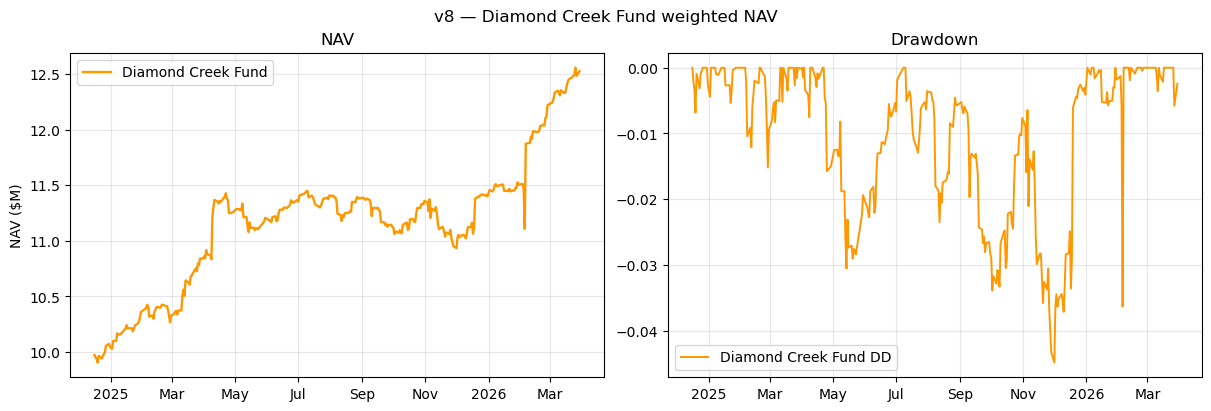

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ref = max(LEVERAGE_RUNS)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
fig.suptitle("v8 — Diamond Creek Fund weighted NAV")

dc_nav = ALL_BT[ref]["nav"]
ax = axes[0]
ax.plot(dc_nav.index, dc_nav / 1e6, label="Diamond Creek Fund", color="#FF9800", lw=1.7)
ax.set_ylabel("NAV ($M)")
ax.set_title("NAV")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
dd_dc = (dc_nav - dc_nav.cummax()) / dc_nav.cummax()
ax.plot(dd_dc.index, dd_dc, label="Diamond Creek Fund DD", color="#FF9800", lw=1.4)
ax.set_title("Drawdown")
ax.legend()
ax.grid(True, alpha=0.3)

for ax in axes.flat:
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
plt.show()


## Shares Available Audit (Historical Runs)

Uses `data/runs/*/etf_screened_today.csv` to track short availability over time. The first chart shows cross-sectional availability stats by run date; the second heatmap shows per-ticker availability for tickers in the current screener universe.


Runs root used: C:\Users\werdn\Documents\Investing\ls-algo\data\runs
Historical runs loaded: 18 files
Date range: 2025-12-28 -> 2026-03-25
Tickers in audit universe: 383


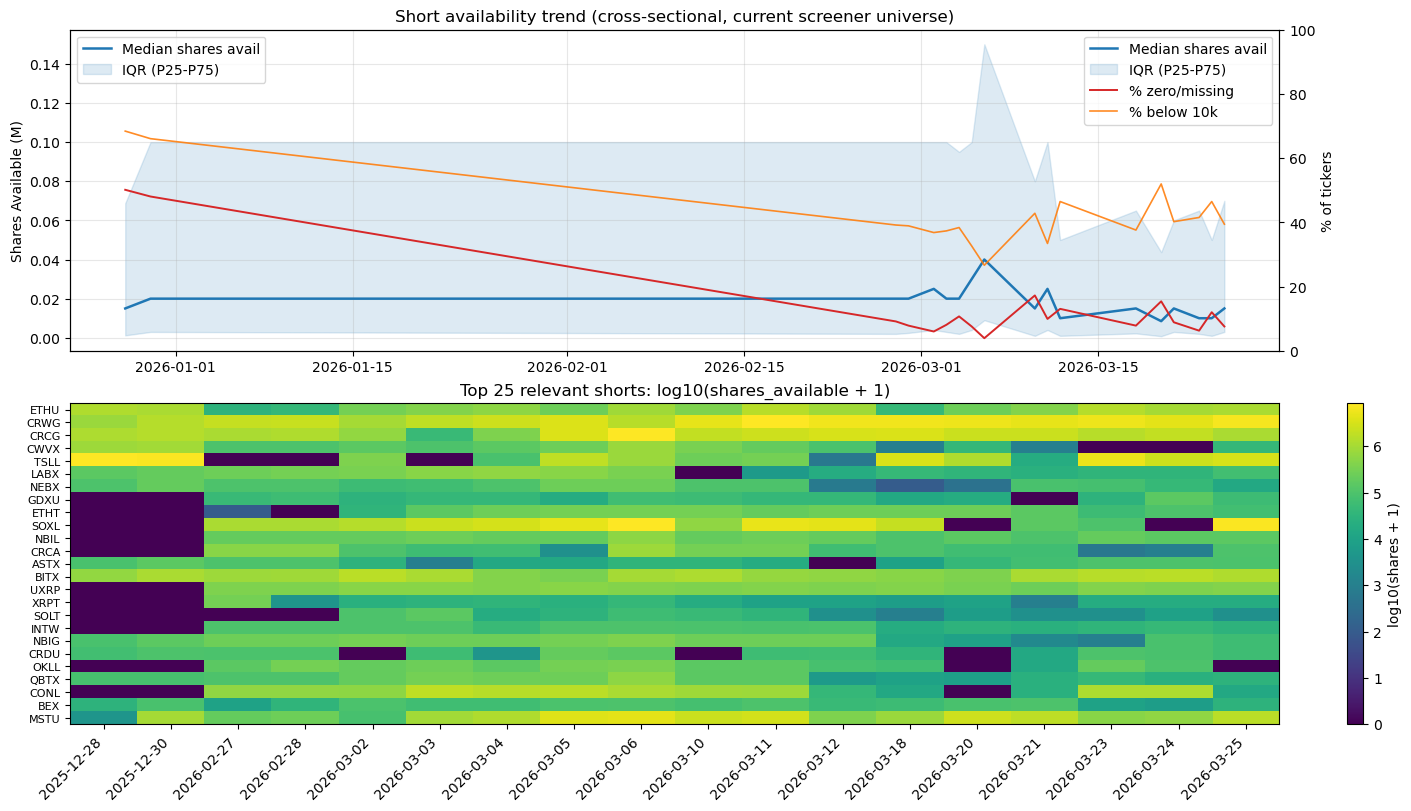

In [ ]:
# Use consolidated historical snapshot panel from borrow/history setup cell.
if "HIST_SNAPSHOT_PANEL" not in globals() or not isinstance(HIST_SNAPSHOT_PANEL, pd.DataFrame) or HIST_SNAPSHOT_PANEL.empty:
    print("No consolidated historical snapshots available. Run borrow/history setup cell first.")
    hist = pd.DataFrame(columns=["date", "etf", "shares_available"])
else:
    hist = HIST_SNAPSHOT_PANEL[["date", "etf", "shares_available"]].copy()

if hist.empty:
    print("No historical shares_available data found in consolidated snapshots.")
else:
    hist["date"] = pd.to_datetime(hist["date"])
    hist = hist.sort_values(["date", "etf"]).drop_duplicates(["date", "etf"], keep="last")

    # Resolve current screener path robustly.
    screen_candidates = [
        Path("../data/etf_screened_today.csv"),
        Path("data/etf_screened_today.csv"),
        Path.cwd() / "../data/etf_screened_today.csv",
        Path.cwd() / "data/etf_screened_today.csv",
        Path.cwd().parent / "data/etf_screened_today.csv",
    ]
    current_screen_path = None
    for cand in screen_candidates:
        c = cand.resolve()
        if c.exists():
            current_screen_path = c
            break

    if current_screen_path is not None:
        current_screen = pd.read_csv(current_screen_path)
        if "ETF" in current_screen.columns:
            ref_tickers = sorted(current_screen["ETF"].astype(str).str.upper().unique())
        else:
            ref_tickers = sorted(hist["etf"].unique())
    else:
        ref_tickers = sorted(hist["etf"].unique())

    h = hist[hist["etf"].isin(ref_tickers)].copy()
    piv = h.pivot(index="date", columns="etf", values="shares_available").sort_index()

    if piv.empty:
        print("Shares-availability history is empty after ETF universe filtering.")
    else:
        print(f"Runs root used: {runs_root}")
        print(f"Historical runs loaded: {len(run_files)} files")
        print(f"Date range: {piv.index.min().date()} -> {piv.index.max().date()}")
        print(f"Tickers in audit universe: {len(ref_tickers)}")

        # Interpretable cross-sectional diagnostics.
        p25 = piv.quantile(0.25, axis=1)
        p50 = piv.quantile(0.50, axis=1)
        p75 = piv.quantile(0.75, axis=1)
        pct_zero_missing = ((piv.fillna(0) <= 0).sum(axis=1) / piv.shape[1])
        pct_low_10k = ((piv.fillna(0) < 10_000).sum(axis=1) / piv.shape[1])

        fig, axes = plt.subplots(2, 1, figsize=(14, 8), layout="constrained")

        ax = axes[0]
        ax.plot(p50.index, p50 / 1e6, label="Median shares avail", lw=1.8, color="tab:blue")
        ax.fill_between(p50.index, p25 / 1e6, p75 / 1e6, color="tab:blue", alpha=0.15, label="IQR (P25-P75)")
        ax.set_ylabel("Shares Available (M)")
        ax.set_title("Short availability trend (cross-sectional, current screener universe)")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper left")

        axr = ax.twinx()
        axr.plot(pct_zero_missing.index, 100 * pct_zero_missing, color="tab:red", lw=1.4, label="% zero/missing")
        axr.plot(pct_low_10k.index, 100 * pct_low_10k, color="tab:orange", lw=1.2, alpha=0.9, label="% below 10k")
        axr.set_ylabel("% of tickers")
        axr.set_ylim(0, 100)
        l1, n1 = ax.get_legend_handles_labels()
        l2, n2 = axr.get_legend_handles_labels()
        axr.legend(l1 + l2, n1 + n2, loc="upper right")

        # Heatmap for only relevant names (top weighted if available).
        if "_w_csv" in globals() and {"etf", "weight"}.issubset(_w_csv.columns):
            heat_names = _w_csv.sort_values("weight", ascending=False)["etf"].astype(str).str.upper().head(25).tolist()
        else:
            heat_names = piv.median(axis=0).sort_values(ascending=False).head(25).index.tolist()

        heat_piv = piv.reindex(columns=[x for x in heat_names if x in piv.columns])
        heat = np.log10(heat_piv.fillna(0).T + 1.0)

        ax = axes[1]
        im = ax.imshow(heat.values, aspect="auto", interpolation="nearest", cmap="viridis")
        ax.set_title("Top 25 relevant shorts: log10(shares_available + 1)")
        ax.set_yticks(np.arange(len(heat.index)))
        ax.set_yticklabels(heat.index, fontsize=8)

        n_dates = len(heat_piv.index)
        step = max(1, n_dates // 12)
        xloc = np.arange(0, n_dates, step)
        ax.set_xticks(xloc)
        ax.set_xticklabels([heat_piv.index[i].strftime("%Y-%m-%d") for i in xloc], rotation=45, ha="right")

        cbar = fig.colorbar(im, ax=ax, pad=0.01)
        cbar.set_label("log10(shares + 1)")
        plt.show()


## NAV Jump Attribution (Diamond Creek Fund)

Ranks the largest absolute daily NAV moves and estimates top pair-level contributors on those days using lagged pair gross and pair spread returns.


In [ ]:
ref = max(LEVERAGE_RUNS)

beta_map = {e: abs(float(b)) for e, u, b in UNIVERSE}

def _build_pair_contrib_usd(pair_gross_df: pd.DataFrame) -> pd.DataFrame:
    if pair_gross_df is None or pair_gross_df.empty:
        return pd.DataFrame()

    idx = pair_gross_df.index
    contrib = pd.DataFrame(index=idx)

    for col in pair_gross_df.columns:
        if "/" not in col:
            continue
        und, etf = col.split("/", 1)
        if und not in PRICES or etf not in PRICES:
            continue

        pu = PRICES[und].reindex(idx).ffill()
        pe = PRICES[etf].reindex(idx).ffill()
        if pu.isna().all() or pe.isna().all():
            continue

        ru = pu.pct_change().fillna(0.0)
        re = pe.pct_change().fillna(0.0)

        babs = max(1e-9, beta_map.get(etf, 2.0))
        hr = 1.0 / babs
        long_frac = 1.0 / (1.0 + hr)
        short_frac = hr / (1.0 + hr)

        pair_ret = long_frac * ru - short_frac * re
        lag_gross = pair_gross_df[col].shift(1).fillna(0.0)
        contrib[col] = lag_gross * pair_ret

    return contrib


def _print_jump_attribution(label: str, bt: pd.DataFrame, pair_contrib: pd.DataFrame, top_n_days: int = 8, top_n_pairs: int = 5):
    nav = bt["nav"].astype(float)
    nav_ret = nav.pct_change().dropna()
    nav_pnl = nav.diff().fillna(0.0)

    top_days = nav_ret.abs().sort_values(ascending=False).head(top_n_days)

    print(f"\n{'='*78}")
    print(f"{label} — Top {top_n_days} absolute daily NAV moves")
    print(f"{'='*78}")
    for d in top_days.index:
        print(f"{d.date()}  NAV ret={nav_ret.loc[d]:+6.2%}  NAV pnl=${nav_pnl.loc[d]:+,.0f}")

    print(f"\n{label} — Pair attribution on jump days (approx, lag gross × spread return)")
    print(f"{'-'*78}")
    for d in top_days.index:
        if d not in pair_contrib.index:
            continue
        c = pair_contrib.loc[d].dropna()
        if c.empty:
            continue
        top_pairs = c.reindex(c.abs().sort_values(ascending=False).head(top_n_pairs).index)

        print(f"\n{d.date()}  NAV ret={nav_ret.loc[d]:+6.2%}  NAV pnl=${nav_pnl.loc[d]:+,.0f}")
        for pair, v in top_pairs.items():
            print(f"  {pair:>16s}  contrib=${v:+,.0f}")


dc_bt = ALL_BT[ref]
dc_contrib = _build_pair_contrib_usd(ALL_PAIR_GROSS[ref])

_print_jump_attribution("Diamond Creek Fund", dc_bt, dc_contrib)



Diamond Creek Fund — Top 8 absolute daily NAV moves
2026-02-06  NAV ret=+6.89%  NAV pnl=$+765,682
2025-04-09  NAV ret=+3.56%  NAV pnl=$+385,882
2026-02-05  NAV ret=-3.08%  NAV pnl=$-352,851
2025-12-19  NAV ret=+2.36%  NAV pnl=$+262,509
2025-11-06  NAV ret=-1.47%  NAV pnl=$-167,179
2025-03-14  NAV ret=+1.31%  NAV pnl=$+138,110
2025-03-11  NAV ret=+1.28%  NAV pnl=$+133,162
2025-05-09  NAV ret=-1.07%  NAV pnl=$-121,435

Diamond Creek Fund — Pair attribution on jump days (approx, lag gross × spread return)
------------------------------------------------------------------------------

2026-02-06  NAV ret=+6.89%  NAV pnl=$+765,682
         CRCL/CRCG  contrib=$+2,402
         ETHA/ETHT  contrib=$+2,246
         ETHA/ETHU  contrib=$-2,104
         BBAI/BAIG  contrib=$-2,036
         NVDA/NVDG  contrib=$+1,997

2025-04-09  NAV ret=+3.56%  NAV pnl=$+385,882
          URA/URAA  contrib=$-9,909
          GDX/GDXU  contrib=$-5,431
         INTC/INTW  contrib=$+4,265
         SMCI/SMCL  contrib=$+

In [ ]:
# ---- Joel White Bay: Monthly P&L attribution (trading vs carry vs borrow) ----
ref = max(LEVERAGE_RUNS)


def _build_attribution(bt: pd.DataFrame, label: str, freq: str = "ME") -> pd.DataFrame:
    d = bt.copy().sort_index()

    # Flow components from cumulative series.
    d["long_trading_pnl"] = d["cum_long_pnl"].diff().fillna(d["cum_long_pnl"])
    d["short_trading_pnl"] = d["cum_short_pnl"].diff().fillna(d["cum_short_pnl"])
    d["net_trading_pnl"] = d["long_trading_pnl"] + d["short_trading_pnl"]

    d["interest_income"] = d["cum_margin_credit"].diff().fillna(d["cum_margin_credit"])
    d["margin_interest_paid"] = d["cum_margin_debit"].diff().fillna(d["cum_margin_debit"])
    d["net_interest_carry"] = d["interest_income"] - d["margin_interest_paid"]

    d["borrow_fees_paid"] = d["cum_borrow"].diff().fillna(d["cum_borrow"])
    d["txn_costs_paid"] = d["cum_costs"].diff().fillna(d["cum_costs"])

    d["net_pnl"] = d["nav"].diff().fillna(d["nav"] - d["nav"].iloc[0])

    # Robust gross leverage derivation across engine schema versions.
    if "actual_leverage" in d.columns:
        d["gross_lev"] = pd.to_numeric(d["actual_leverage"], errors="coerce")
    elif "gross_notional" in d.columns:
        d["gross_lev"] = (pd.to_numeric(d["gross_notional"], errors="coerce").abs() / d["nav"].replace(0, np.nan))
    elif {"long_notional", "short_notional"}.issubset(d.columns):
        d["gross_lev"] = (
            (pd.to_numeric(d["long_notional"], errors="coerce").abs() + pd.to_numeric(d["short_notional"], errors="coerce").abs())
            / d["nav"].replace(0, np.nan)
        )
    else:
        d["gross_lev"] = np.nan
    d["gross_lev"] = d["gross_lev"].replace([np.inf, -np.inf], np.nan)

    # Expected bridge from components; residual helps QA.
    d["explained_pnl"] = d["net_trading_pnl"] + d["net_interest_carry"] - d["borrow_fees_paid"] - d["txn_costs_paid"]
    d["residual_pnl"] = d["net_pnl"] - d["explained_pnl"]

    sum_cols = [
        "long_trading_pnl",
        "short_trading_pnl",
        "net_trading_pnl",
        "interest_income",
        "margin_interest_paid",
        "net_interest_carry",
        "borrow_fees_paid",
        "txn_costs_paid",
        "net_pnl",
        "explained_pnl",
        "residual_pnl",
    ]
    out = d[sum_cols].resample(freq).sum()
    out["avg_gross_lev"] = d["gross_lev"].resample(freq).mean()

    if "fed_funds_rate" in d.columns:
        rate = pd.to_numeric(d["fed_funds_rate"], errors="coerce")
        out["benchmark_rate_avg"] = rate.resample(freq).mean()
        out["benchmark_rate_eom"] = rate.resample(freq).last()
    else:
        out["benchmark_rate_avg"] = np.nan
        out["benchmark_rate_eom"] = np.nan

    # Contribution views.
    out["trading_pct_of_net"] = np.where(out["net_pnl"] != 0, out["net_trading_pnl"] / out["net_pnl"], np.nan)
    out["carry_pct_of_net"] = np.where(out["net_pnl"] != 0, out["net_interest_carry"] / out["net_pnl"], np.nan)
    out["borrow_pct_of_net"] = np.where(out["net_pnl"] != 0, -out["borrow_fees_paid"] / out["net_pnl"], np.nan)

    abs_driver = out["net_trading_pnl"].abs() + out["net_interest_carry"].abs() + out["borrow_fees_paid"].abs() + out["txn_costs_paid"].abs()
    out["trading_abs_share"] = np.where(abs_driver > 0, out["net_trading_pnl"].abs() / abs_driver, np.nan)
    out["carry_abs_share"] = np.where(abs_driver > 0, out["net_interest_carry"].abs() / abs_driver, np.nan)
    out["borrow_abs_share"] = np.where(abs_driver > 0, out["borrow_fees_paid"].abs() / abs_driver, np.nan)
    out["txn_abs_share"] = np.where(abs_driver > 0, out["txn_costs_paid"].abs() / abs_driver, np.nan)

    out.insert(0, "portfolio", label)
    out.insert(1, "month", out.index.strftime("%Y-%m"))
    return out.reset_index(drop=True)


monthly_dc = _build_attribution(ALL_BT[ref], "Diamond Creek Fund")
monthly_attr = pd.concat([monthly_dc], ignore_index=True)

print("=" * 108)
print("Monthly P&L Attribution — Trading vs Interest Carry vs Borrow")
print("=" * 108)
print(
    "Columns: net_trading_pnl, net_interest_carry (interest_income - margin_interest_paid), "
    "borrow_fees_paid, txn_costs_paid, net_pnl, avg_gross_lev, benchmark_rate_avg/eom"
)

for name in ["Diamond Creek Fund"]:
    x = monthly_attr[monthly_attr["portfolio"] == name].copy()
    print(f"\n{name} — monthly attribution")
    display(
        x[[
            "month",
            "benchmark_rate_avg",
            "benchmark_rate_eom",
            "avg_gross_lev",
            "long_trading_pnl",
            "short_trading_pnl",
            "net_trading_pnl",
            "interest_income",
            "margin_interest_paid",
            "net_interest_carry",
            "borrow_fees_paid",
            "txn_costs_paid",
            "net_pnl",
            "trading_pct_of_net",
            "carry_pct_of_net",
            "borrow_pct_of_net",
            "residual_pnl",
        ]]
    )

# Compact cumulative summary for fast readout.
summary = (
    monthly_attr.groupby("portfolio", dropna=False)[[
        "net_trading_pnl",
        "net_interest_carry",
        "borrow_fees_paid",
        "txn_costs_paid",
        "net_pnl",
    ]]
    .sum()
    .reset_index()
)
summary["trading_pct_of_net"] = np.where(summary["net_pnl"] != 0, summary["net_trading_pnl"] / summary["net_pnl"], np.nan)
summary["carry_pct_of_net"] = np.where(summary["net_pnl"] != 0, summary["net_interest_carry"] / summary["net_pnl"], np.nan)
summary["borrow_pct_of_net"] = np.where(summary["net_pnl"] != 0, -summary["borrow_fees_paid"] / summary["net_pnl"], np.nan)

print("\nCumulative attribution summary")
display(summary)

daily_attr_dc = ALL_BT[ref].copy()


Monthly P&L Attribution — Trading vs Interest Carry vs Borrow
Columns: net_trading_pnl, net_interest_carry (interest_income - margin_interest_paid), borrow_fees_paid, txn_costs_paid, net_pnl, avg_gross_lev, benchmark_rate_avg/eom

Diamond Creek Fund — monthly attribution


,month,benchmark_rate_avg,benchmark_rate_eom,avg_gross_lev,long_trading_pnl,short_trading_pnl,net_trading_pnl,interest_income,margin_interest_paid,net_interest_carry,borrow_fees_paid,txn_costs_paid,net_pnl,trading_pct_of_net,carry_pct_of_net,borrow_pct_of_net,residual_pnl
0,2024-12,0.043982,0.0433,4.419652,-3.508956e+06,3.644780e+06,135823.576615,21189.530418,40320.721342,-19131.190924,39600.895818,31431.110834,72743.115282,1.867167,-0.262997,-0.544394,2.708274e+04
1,2025-01,0.043300,0.0433,4.423287,1.126623e+06,-6.713849e+05,455237.749895,43873.890693,83380.778025,-39506.887331,84723.980188,9108.566997,321898.315378,1.414228,-0.122731,-0.263201,2.859451e-09
2,2025-02,0.043300,0.0433,4.388753,-5.858516e+06,5.946798e+06,88281.362016,40839.661758,79778.370373,-38938.708615,79638.499185,10798.052681,-41093.898465,-2.148284,0.947555,1.937964,3.456080e-09
3,2025-03,0.043300,0.0433,4.414219,-2.639677e+06,3.296992e+06,657314.094024,47409.303054,91694.876540,-44285.573486,93400.212892,6729.489372,512898.818274,1.281567,-0.086344,-0.182103,-5.478796e-09
4,2025-04,0.043300,0.0433,4.543606,2.329669e+06,-1.729970e+06,599699.663474,52876.827081,103323.274319,-50446.447238,107446.748473,14572.567426,427233.900337,1.403680,-0.118077,-0.251494,-6.199116e-09
5,2025-05,0.043300,0.0433,4.724696,7.624725e+06,-7.504374e+06,120350.673444,56625.437017,109461.015475,-52835.578458,113234.001650,14514.884538,-60233.791202,-1.998059,0.877175,1.879908,-4.743924e-09
6,2025-06,0.043300,0.0433,4.689572,1.942960e+06,-1.625243e+06,317717.961577,52841.716606,102969.680610,-50127.964004,103327.884816,4159.735835,160102.376922,1.984467,-0.313099,-0.645386,-8.076313e-09
7,2025-07,0.043300,0.0433,4.731811,3.882138e+06,-3.638036e+06,244102.727046,59556.581428,117436.775197,-57880.193769,131007.985443,15022.118101,40192.429733,6.073351,-1.440077,-3.259519,-1.089938e-08
8,2025-08,0.043300,0.0433,4.877281,1.153105e+06,-9.628399e+05,190264.906403,57906.330565,115089.468540,-57183.137975,138262.144666,19525.810149,-24706.186387,-7.701104,2.314527,5.596256,-7.712515e-09
9,2025-09,0.042262,0.0409,4.842286,6.055559e+06,-6.079643e+06,-24084.043053,56862.276815,110917.513146,-54055.236331,161356.535782,19395.857888,-258891.673054,0.093027,0.208795,0.623259,1.050648e-08



Cumulative attribution summary


,portfolio,net_trading_pnl,net_interest_carry,borrow_fees_paid,txn_costs_paid,net_pnl,trading_pct_of_net,carry_pct_of_net,borrow_pct_of_net
0,Diamond Creek Fund,5.799773e+06,-778240.730052,2.231764e+06,263756.538829,2.553095e+06,2.271664,-0.304822,-0.87414


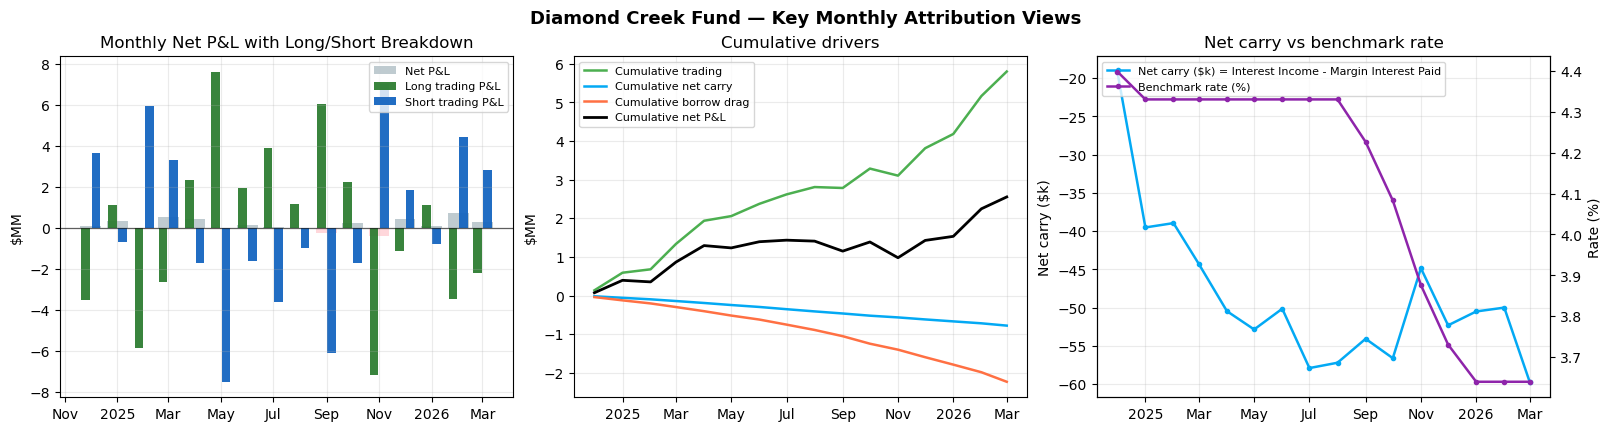

In [ ]:
# ---- Joel White Bay: simplified visual attribution trends (monthly) ----
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

if "monthly_attr" not in globals() or monthly_attr.empty:
    raise RuntimeError("Run the monthly attribution cell first.")

m_dc = monthly_attr[monthly_attr["portfolio"] == "Diamond Creek Fund"].copy()
if m_dc.empty:
    raise RuntimeError("Missing Diamond Creek Fund attribution rows.")

m_dc["month_dt"] = pd.to_datetime(m_dc["month"] + "-01")
m_dc.sort_values("month_dt", inplace=True)

x = m_dc["month_dt"]
m_dc["borrow_drag"] = -m_dc["borrow_fees_paid"]

# Benchmark rate is flat when FRED download fails and fallback schedule is sparse.
rate = pd.to_numeric(m_dc.get("benchmark_rate_avg"), errors="coerce")
rate_pct = np.where(rate.abs().max() <= 1.0, rate * 100.0, rate)
if pd.Series(rate_pct).nunique(dropna=True) <= 2:
    print("Benchmark rate is nearly flat in this run (likely fallback rate series after FRED fetch failure).")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), layout="constrained")
fig.suptitle("Diamond Creek Fund — Key Monthly Attribution Views", fontsize=13, fontweight="bold")

# 1) Monthly net P&L with explicit long vs short trading breakdown.
ax = axes[0]
bar_wide = pd.Timedelta(days=24)
bar_narrow = pd.Timedelta(days=10)

# Wide background bar: total monthly net P&L.
net_colors = np.where(m_dc["net_pnl"] >= 0, "#B0BEC5", "#FFCDD2")
ax.bar(x, m_dc["net_pnl"] / 1e6, width=bar_wide, color=net_colors, alpha=0.8, label="Net P&L")

# Narrow bars: long/short trading legs (clear and side-by-side).
x_long = x - pd.to_timedelta(6, unit="D")
x_short = x + pd.to_timedelta(6, unit="D")
ax.bar(x_long, m_dc["long_trading_pnl"] / 1e6, width=bar_narrow, color="#2E7D32", alpha=0.95, label="Long trading P&L")
ax.bar(x_short, m_dc["short_trading_pnl"] / 1e6, width=bar_narrow, color="#1565C0", alpha=0.95, label="Short trading P&L")

ax.axhline(0, color="black", lw=0.9, alpha=0.6)
ax.set_title("Monthly Net P&L with Long/Short Breakdown")
ax.set_ylabel("$MM")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)

# 2) Keep this one as-is (most useful): cumulative drivers.
ax = axes[1]
ax.plot(x, m_dc["net_trading_pnl"].cumsum() / 1e6, label="Cumulative trading", color="#4CAF50", lw=1.8)
ax.plot(x, m_dc["net_interest_carry"].cumsum() / 1e6, label="Cumulative net carry", color="#03A9F4", lw=1.8)
ax.plot(x, m_dc["borrow_drag"].cumsum() / 1e6, label="Cumulative borrow drag", color="#FF7043", lw=1.8)
ax.plot(x, m_dc["net_pnl"].cumsum() / 1e6, label="Cumulative net P&L", color="black", lw=2.0)
ax.set_title("Cumulative drivers")
ax.set_ylabel("$MM")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)

# 3) Very simple carry-rate relationship.
ax = axes[2]
ax.plot(x, m_dc["net_interest_carry"] / 1e3, color="#03A9F4", lw=1.8, marker="o", ms=3, label="Net carry ($k) = Interest Income - Margin Interest Paid")
ax2 = ax.twinx()
ax2.plot(x, rate_pct, color="#8E24AA", lw=1.8, marker="o", ms=3, label="Benchmark rate (%)")
ax.set_title("Net carry vs benchmark rate")
ax.set_ylabel("Net carry ($k)")
ax2.set_ylabel("Rate (%)")
ax.grid(True, alpha=0.25)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="upper left")

for _ax in axes:
    _ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(_ax.xaxis.get_major_locator()))

plt.show()


,ETF,n_obs,avg_borrow_pct,med_borrow_pct,min_borrow_pct,max_borrow_pct,std_borrow_pct,first_seen,last_seen
303,RVNL,17,138.342092,137.5406,130.0504,144.0742,4.977497,2026-02-27,2026-03-25
38,AXPG,16,130.636833,82.7262,54.9580,219.1182,78.586112,2026-02-27,2026-03-25
160,HIBL,14,123.140160,114.2145,99.8718,150.3766,21.839793,2026-02-27,2026-03-25
215,MSTP,17,90.530262,93.6286,58.8856,99.2344,13.680121,2026-02-27,2026-03-25
195,LULG,19,85.726920,86.4634,70.5170,92.7394,5.612636,2025-12-28,2026-03-25
...,...,...,...,...,...,...,...,...,...
293,RDTL,17,20.048677,18.9360,16.4156,24.4082,2.848310,2026-02-27,2026-03-25
307,SBU,15,19.589618,19.1186,17.1340,22.3652,2.367197,2026-02-27,2026-03-25
301,RTXG,18,19.372700,19.6194,14.0214,36.9906,7.078637,2025-12-28,2026-03-25
371,UPSG,8,19.264250,19.6648,0.1956,20.4824,7.790498,2025-12-30,2026-03-12


Borrow history rows: 6,563 | tickers total: 398 | tickers in view: 246 | run files used: 20 | min_obs filter: 2
Avg-borrow distribution (in-view): mean=21.94%, median=15.92%, p75=28.56%, p90=48.73%, p95=62.33%, p99=108.47%


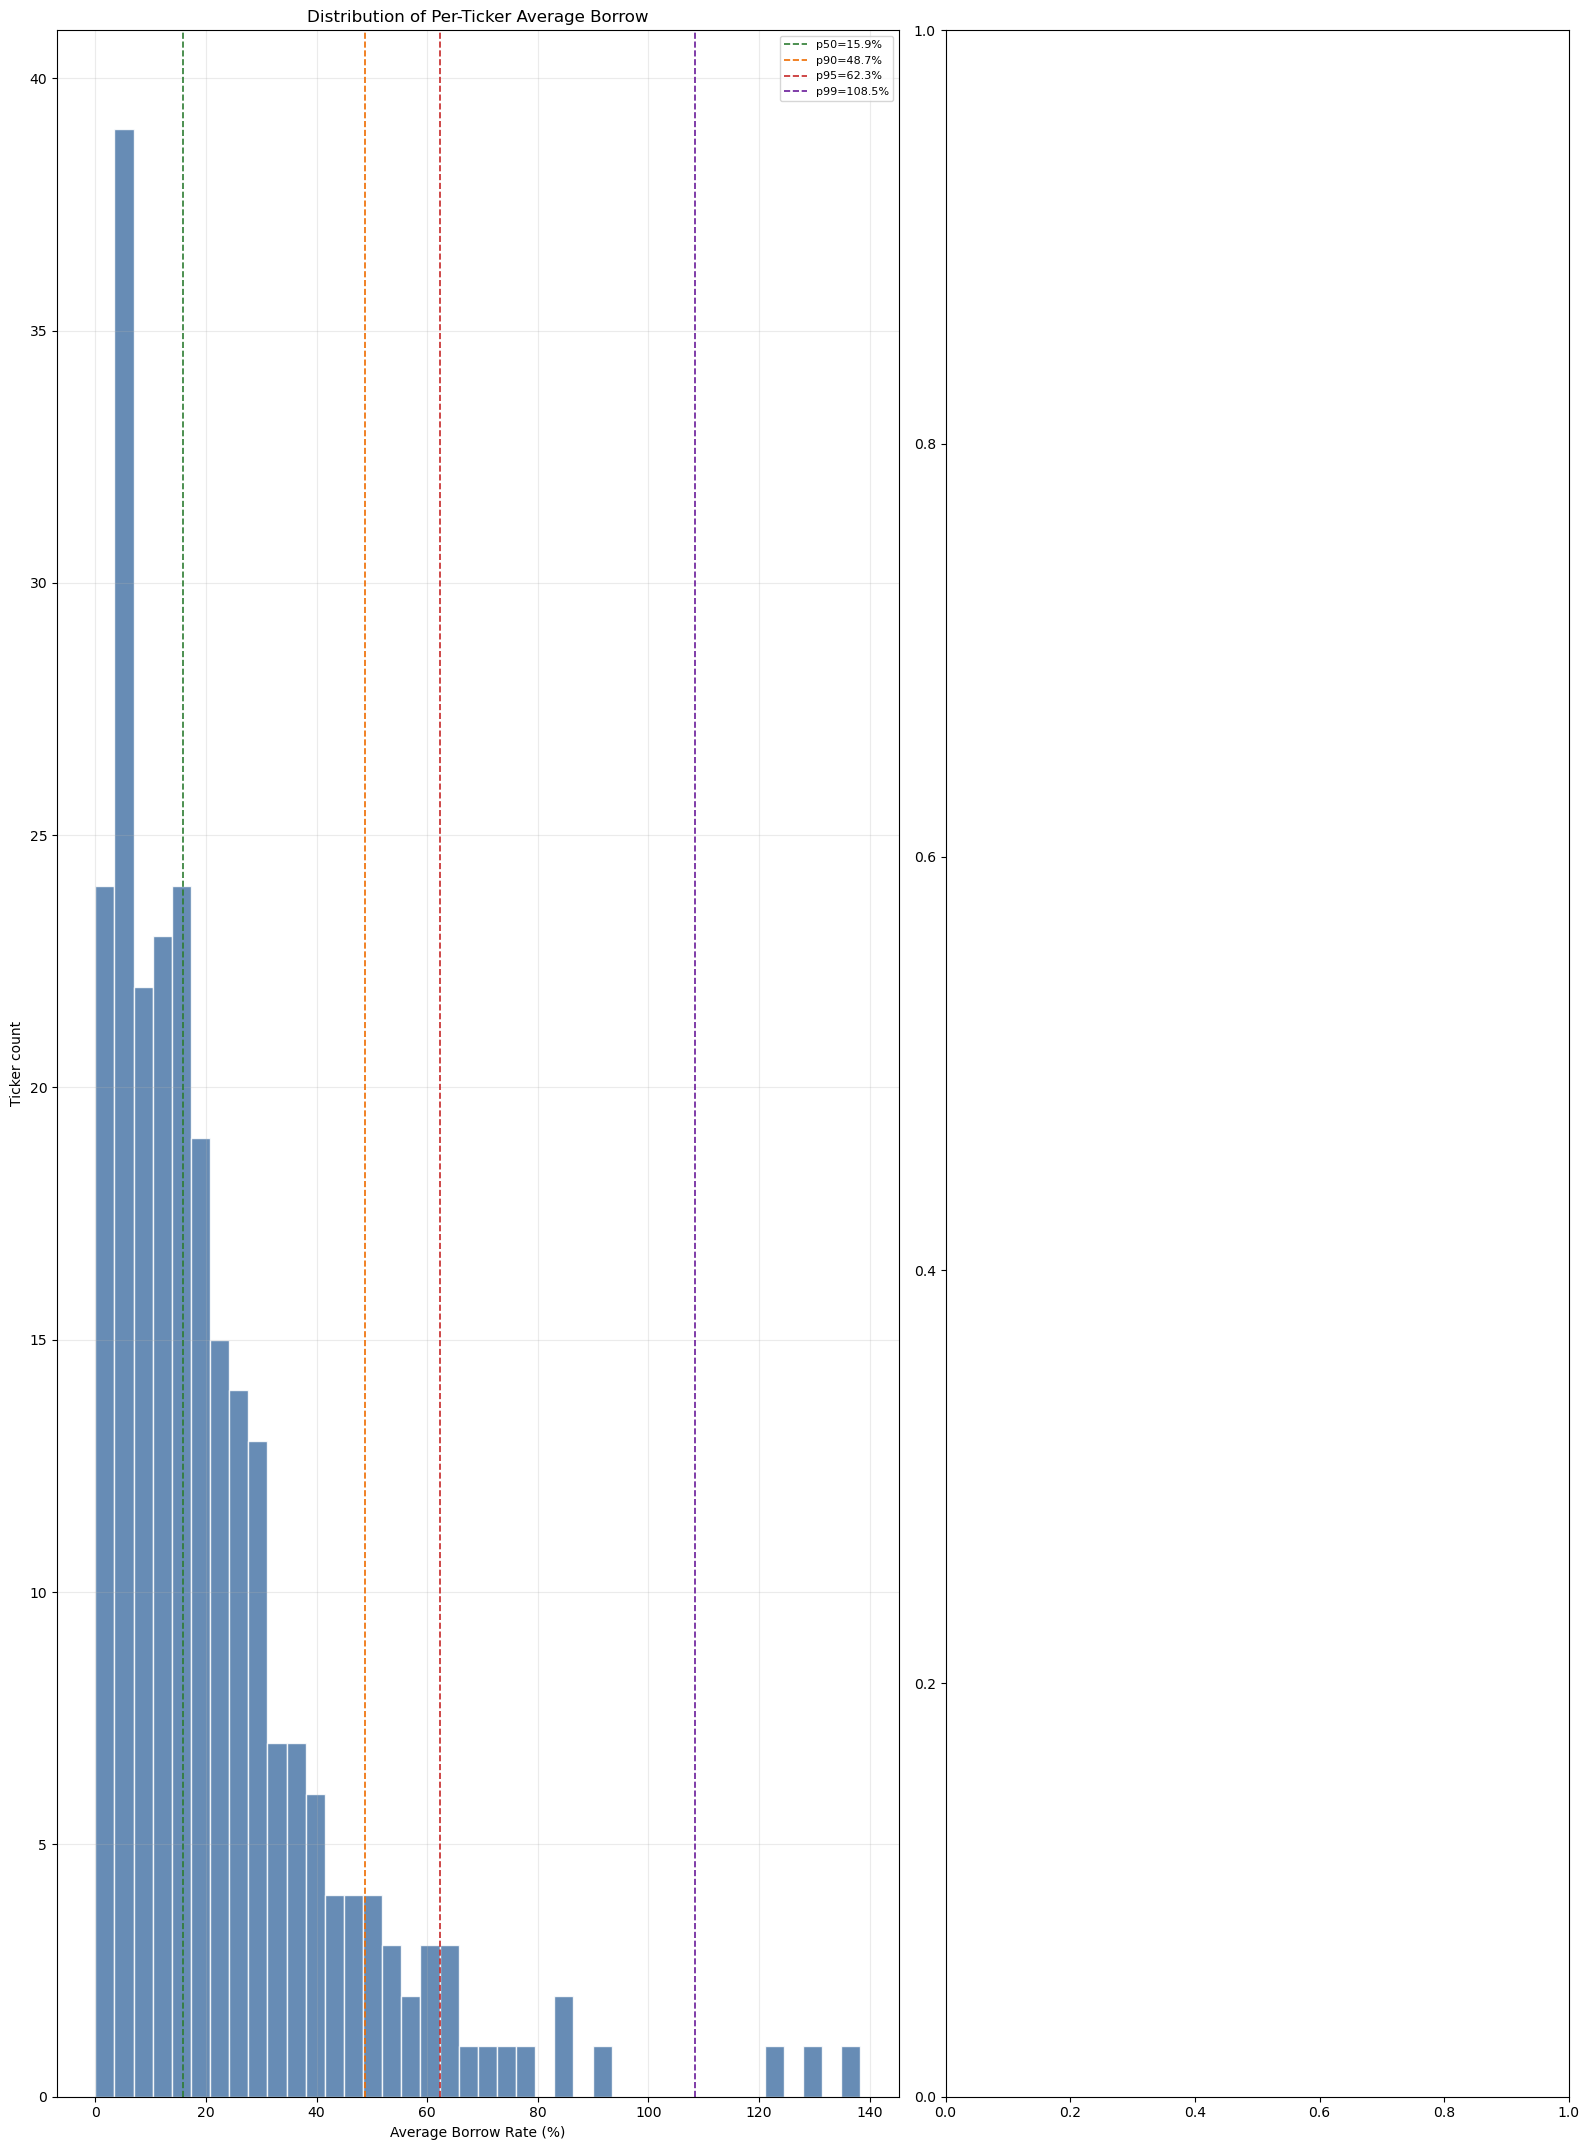

In [ ]:
# ---- Historical per-ticker average borrow rate (consolidated parser) ----
if "HIST_SNAPSHOT_PANEL" not in globals() or not isinstance(HIST_SNAPSHOT_PANEL, pd.DataFrame) or HIST_SNAPSHOT_PANEL.empty:
    raise RuntimeError("Historical snapshot panel is missing. Run the borrow/history setup cell first.")

hist = HIST_SNAPSHOT_PANEL.copy()
hist["date"] = pd.to_datetime(hist["date"], errors="coerce")
hist["etf"] = hist["etf"].astype(str).str.upper().str.strip()
hist["borrow_rate"] = pd.to_numeric(hist["borrow_rate"], errors="coerce")

borrow_hist = (
    hist[["date", "etf", "borrow_rate"]]
    .rename(columns={"date": "run_date", "etf": "ETF"})
    .dropna(subset=["run_date", "ETF", "borrow_rate"])
    .copy()
)

if borrow_hist.empty:
    raise RuntimeError("No usable borrow-rate rows found in consolidated historical snapshots.")

# "Match over time": keep tickers seen in at least 2 run snapshots.
min_obs = 2


def _trimmed_mean_drop2(s: pd.Series) -> float:
    x = pd.to_numeric(s, errors="coerce").dropna().sort_values()
    if len(x) <= 4:
        return float(x.mean()) if len(x) else np.nan
    return float(x.iloc[2:-2].mean())


base_stats = (
    borrow_hist.groupby("ETF", as_index=False)
    .agg(
        med_borrow_rate=("borrow_rate", "median"),
        std_borrow_rate=("borrow_rate", "std"),
        min_borrow_rate=("borrow_rate", "min"),
        max_borrow_rate=("borrow_rate", "max"),
        n_obs=("borrow_rate", "size"),
        first_seen=("run_date", "min"),
        last_seen=("run_date", "max"),
    )
)
trimmed = borrow_hist.groupby("ETF")["borrow_rate"].apply(_trimmed_mean_drop2).rename("avg_borrow_rate").reset_index()
borrow_avg = base_stats.merge(trimmed, on="ETF", how="left")

borrow_avg = borrow_avg[borrow_avg["n_obs"] >= min_obs].copy()
borrow_avg.sort_values(["avg_borrow_rate", "n_obs"], ascending=[False, False], inplace=True)

# Focus diagnostics on the active v9 backtest universe when available.
if "UNIVERSE" in globals() and len(UNIVERSE) > 0:
    active_etfs = {e for e, _, _ in UNIVERSE}
    borrow_view = borrow_avg[borrow_avg["ETF"].isin(active_etfs)].copy()
else:
    active_etfs = None
    borrow_view = borrow_avg.copy()

if borrow_view.empty:
    raise RuntimeError("No borrow averages available for current backtest universe.")

borrow_view.sort_values(["avg_borrow_rate", "n_obs"], ascending=[False, False], inplace=True)

# Display a larger table of top names by average borrow.
table_n = min(100, len(borrow_view))
display(
    borrow_view.head(table_n).assign(
        avg_borrow_pct=lambda x: 100 * x["avg_borrow_rate"],
        med_borrow_pct=lambda x: 100 * x["med_borrow_rate"],
        min_borrow_pct=lambda x: 100 * x["min_borrow_rate"],
        max_borrow_pct=lambda x: 100 * x["max_borrow_rate"],
        std_borrow_pct=lambda x: 100 * x["std_borrow_rate"],
    )[
        [
            "ETF",
            "n_obs",
            "avg_borrow_pct",
            "med_borrow_pct",
            "min_borrow_pct",
            "max_borrow_pct",
            "std_borrow_pct",
            "first_seen",
            "last_seen",
        ]
    ]
)

q = borrow_view["avg_borrow_rate"].quantile([0.50, 0.75, 0.90, 0.95, 0.99]).to_dict()
print(
    f"Borrow history rows: {len(borrow_hist):,} | tickers total: {borrow_hist['ETF'].nunique():,} | "
    f"tickers in view: {len(borrow_view):,} | run files used: {borrow_hist['run_date'].nunique():,} | min_obs filter: {min_obs}"
)
print(
    f"Avg-borrow distribution (in-view): mean={borrow_view['avg_borrow_rate'].mean():.2%}, "
    f"median={q[0.50]:.2%}, p75={q[0.75]:.2%}, p90={q[0.90]:.2%}, p95={q[0.95]:.2%}, p99={q[0.99]:.2%}"
)

# Plot many more names + distribution.
plot_n = min(120, len(borrow_view))
plot_df = borrow_view.head(plot_n).sort_values("avg_borrow_rate", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, max(7, 0.18 * plot_n)), gridspec_kw={"width_ratios": [1.35, 1.0]})

ax = axes[0]

x = 100 * borrow_view["avg_borrow_rate"].dropna()
ax.hist(x, bins=40, color="#4C78A8", alpha=0.85, edgecolor="white")
ax.set_title("Distribution of Per-Ticker Average Borrow")
ax.set_xlabel("Average Borrow Rate (%)")
ax.set_ylabel("Ticker count")
for p, c in [(0.50, "#2E7D32"), (0.90, "#EF6C00"), (0.95, "#C62828"), (0.99, "#6A1B9A")]:
    v = 100 * q[p]
    ax.axvline(v, color=c, linestyle="--", lw=1.2, label=f"p{int(100*p)}={v:.1f}%")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()